In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import table
import io
import dataframe_image as dfi
import seaborn as sns

from pathlib import Path

# Define paths
DATA_PATH = Path("../../../../data/raw")


e:\parity-patterns-sri-lanka-main\parity-patterns-sri-lanka\venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


In [2]:
# Load data
df = pd.read_excel(DATA_PATH / "2020_Birth_Final.xlsx")

In [20]:
del list  
list(df.columns)

['Registered_Year',
 'Registered_Month2.0',
 'Registered_Month',
 'Registered_District',
 'Birh_Year',
 'Birth_Month.0',
 'Birth_Month',
 'Gender',
 'Hospital or Not',
 'Multiple_Birth_Status',
 'Birth_Weight(grams)',
 'Birth_Order',
 'Birth_Order - Copy',
 'Age of Mother',
 'Marital_Status',
 'District_of_Mother',
 'Race_of_Mother',
 'Race_of_Father']


📊 COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING Birth_Order - Copy RECORDS

📌 DATASET OVERVIEW:
   • Total records with missing Birth_Order - Copy: 26,007
   • Total records with complete Birth_Order - Copy: 275,705

📌 PART 1: UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE

📌 PART 2: MULTIVARIATE ANALYSIS - CORRELATIONS AND PATTERNS

🔍 CORRELATION MATRIX (Numeric Variables):

   No strong correlations found between numeric variables

🔍 CATEGORICAL ASSOCIATIONS:
   • Registered_Month & Registered_District: p=0.0000, Cramer's V=0.162
   • Registered_Month & Birth_Month: p=0.0000, Cramer's V=0.455
   • Registered_Month & Hospital or Not: p=0.0000, Cramer's V=0.042
   • Registered_District & Birth_Month: p=0.0000, Cramer's V=0.114
   • Registered_District & Hospital or Not: p=0.0000, Cramer's V=0.190

📌 PART 3: MISSINGNESS PATTERN ANALYSIS

🔍 VARIABLES THAT TEND TO BE MISSING TOGETHER:
   • Race_of_Mother & Race_of_Father: 0.422

📌 PART 4: CREATING COMPREHENSIVE STATISTICAL R

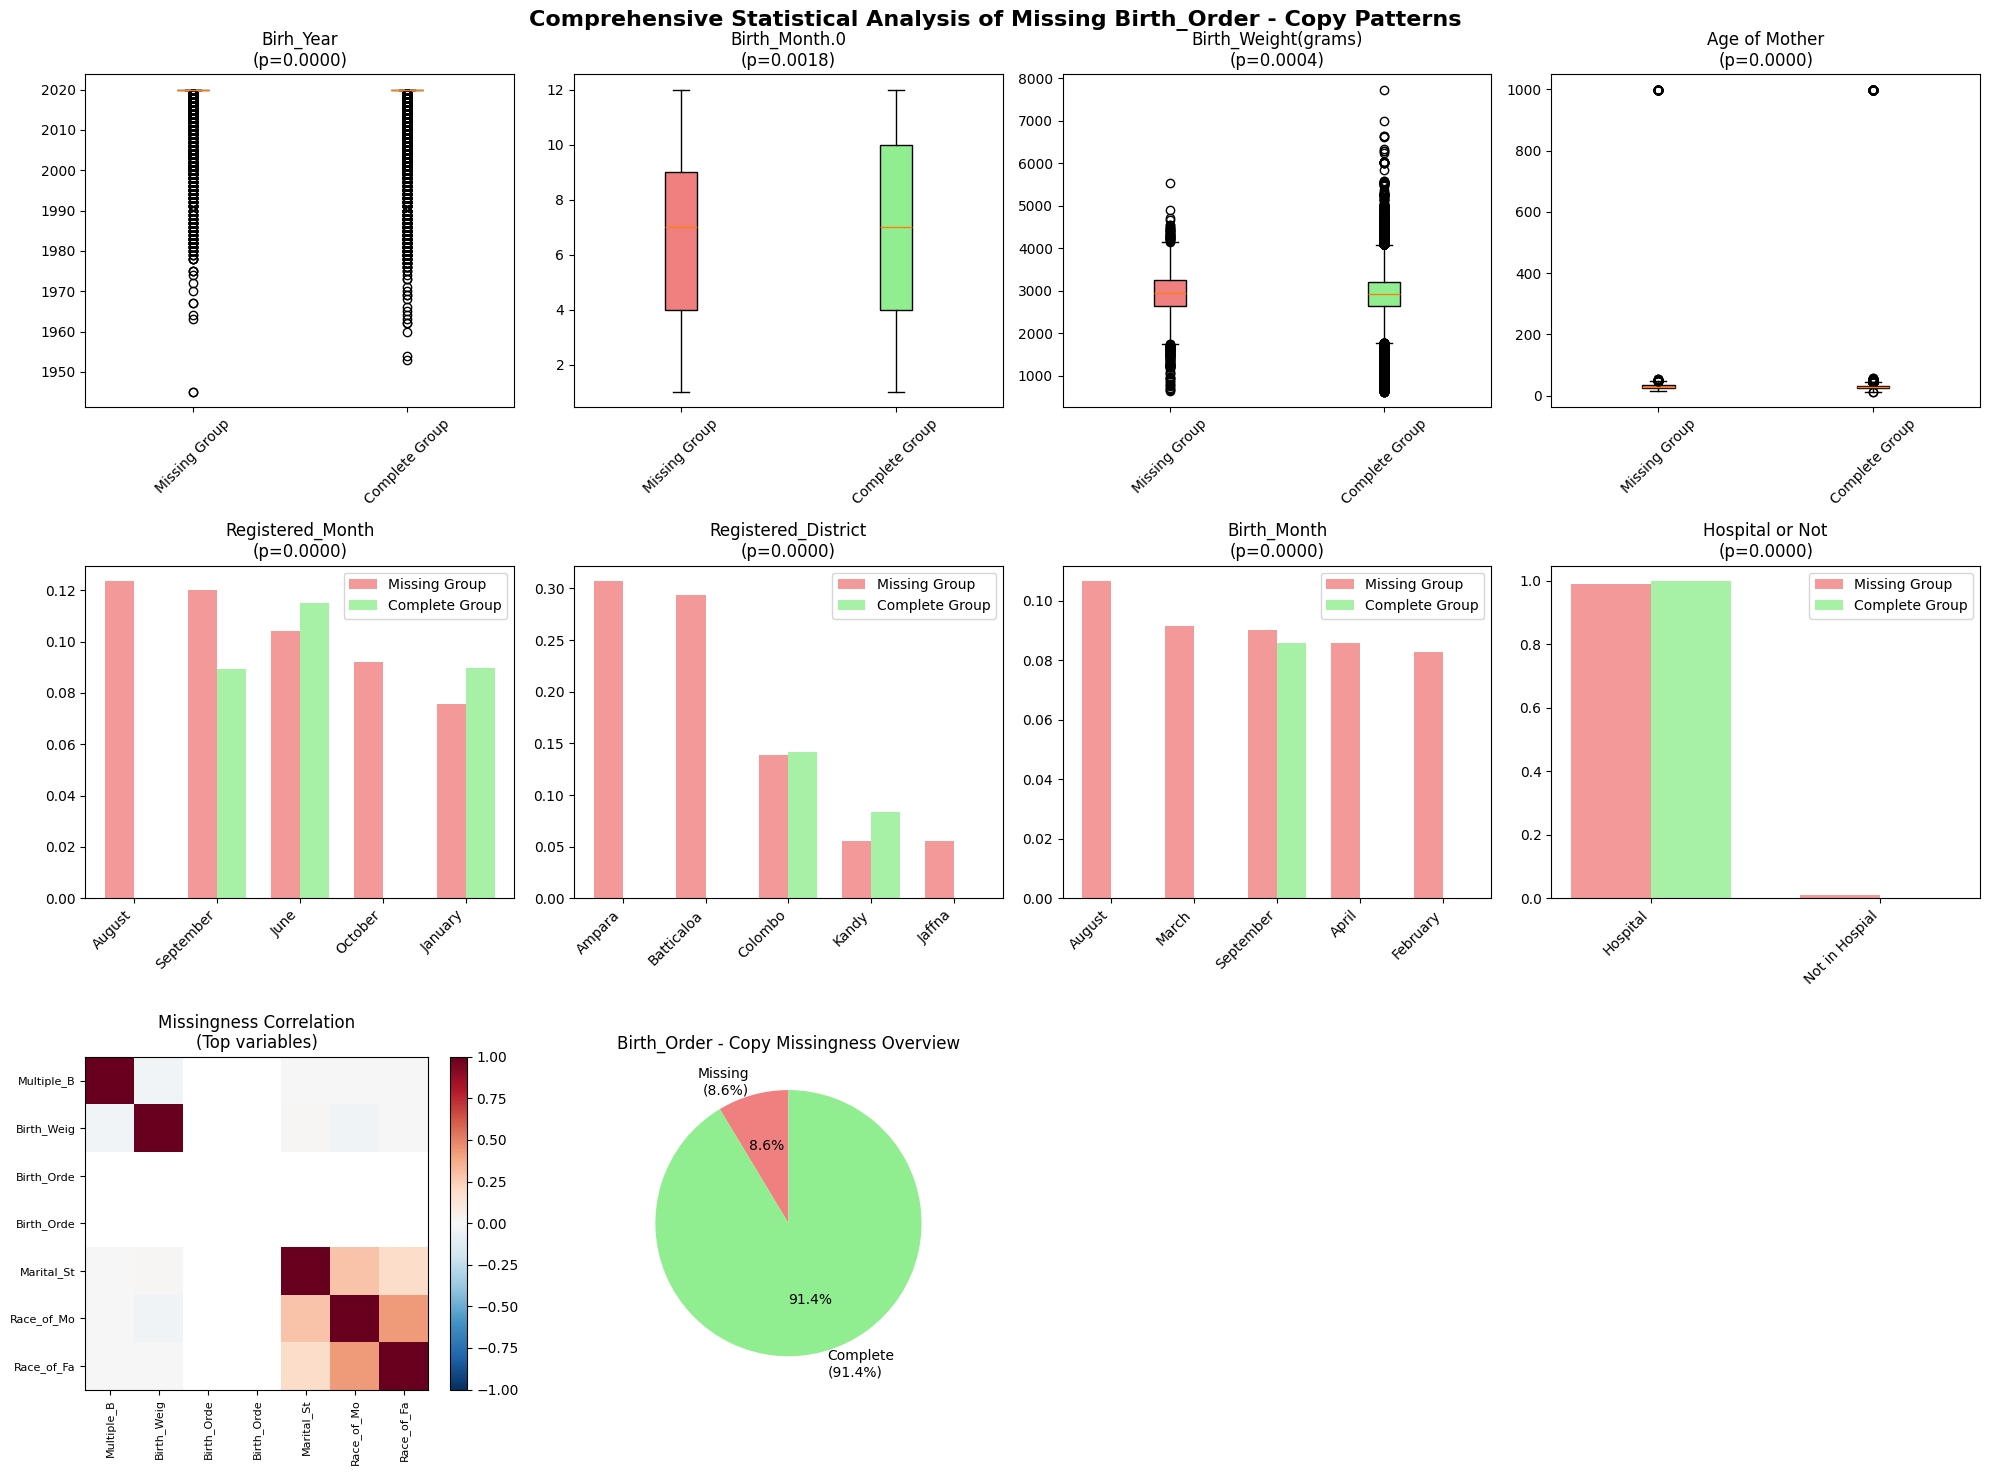


📋 COMPREHENSIVE STATISTICAL SUMMARY

📊 OVERALL STATISTICS:
   • Total missing Birth_Order - Copy records: 26,007 (8.6% of total)
   • Number of variables analyzed: 18
   • Numeric variables: 8
   • Categorical variables: 10

🔍 VARIABLES WITH SIGNIFICANT DIFFERENCES (p < 0.05):
   • Registered_Month: Most common='August' (12.3%), p=0.0000
   • Registered_District: Most common='Ampara' (30.7%), p=0.0000
   • Birh_Year: Mean=2019.05 vs Complete Mean (diff: -0.66, p=0.0000)
   • Birth_Month.0: Mean=6.51 vs Complete Mean (diff: -0.07, p=0.0018)
   • Birth_Month: Most common='August' (10.7%), p=0.0000
   • Hospital or Not: Most common='Hospital' (99.0%), p=0.0000
   • Multiple_Birth_Status: Most common='missing' (99.6%), p=0.0000
   • Birth_Weight(grams): Mean=2941.07 vs Complete Mean (diff: 23.86, p=0.0004)
   • Age of Mother: Mean=31.23 vs Complete Mean (diff: 1.75, p=0.0000)
   • Marital_Status: Most common='Married' (95.6%), p=0.0000
   • District_of_Mother: Most common='Ampara' (30.3%)

In [22]:
# ============================================
# FOCUS ON BIRTH ORDER - CHANGE THIS VARIABLE NAME TO ANALYZE OTHER VARIABLES
# ============================================
TARGET_VARIABLE = 'Birth_Order - Copy'  # <-- CHANGE THIS to analyze other variables
# ============================================

# ============================================
# COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING BIRTH ORDER PATTERNS
# (Modified to handle qualitative target variables)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output

print(f"\n{'='*80}")
print(f"📊 COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING {TARGET_VARIABLE} RECORDS")
print(f"{'='*80}")

# Load the missing data
missing_data = df[df[TARGET_VARIABLE].isnull()].copy()
complete_data = df[df[TARGET_VARIABLE].notnull()].copy()

print(f"\n📌 DATASET OVERVIEW:")
print(f"   • Total records with missing {TARGET_VARIABLE}: {len(missing_data):,}")
print(f"   • Total records with complete {TARGET_VARIABLE}: {len(complete_data):,}")

# ============================================
# 1. UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 1: UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE")
print(f"{'='*80}")

# Create a comprehensive statistics dataframe
all_stats = []

# Analyze each column in the missing data
for col in missing_data.columns:
    if col == TARGET_VARIABLE:
        continue
        
    col_stats = {
        'Variable': col,
        'Data_Type': str(missing_data[col].dtype),
        'Missing_in_Group': missing_data[col].isnull().sum(),
        'Missing_in_Group_%': (missing_data[col].isnull().sum() / len(missing_data)) * 100,
        'Complete_in_Group': missing_data[col].notnull().sum(),
        'Complete_in_Group_%': (missing_data[col].notnull().sum() / len(missing_data)) * 100,
        'Unique_Values': missing_data[col].nunique(),
    }
    
    # Statistics based on data type
    if missing_data[col].dtype in ['int64', 'float64']:
        # NUMERIC VARIABLE STATISTICS
        valid_data = missing_data[col].dropna()
        complete_valid_data = complete_data[col].dropna() if col in complete_data.columns else pd.Series()
        
        if len(valid_data) > 0:
            # Check if data has variance before calculating stats
            if valid_data.nunique() > 1:  # More than one unique value
                try:
                    # Central tendency
                    col_stats.update({
                        'Mean': valid_data.mean(),
                        'Median': valid_data.median(),
                        'Mode': valid_data.mode().iloc[0] if len(valid_data.mode()) > 0 else np.nan,
                        'Std_Dev': valid_data.std(),
                        'Variance': valid_data.var(),
                        'Min': valid_data.min(),
                        'Max': valid_data.max(),
                        'Range': valid_data.max() - valid_data.min(),
                        'Q1': valid_data.quantile(0.25),
                        'Q3': valid_data.quantile(0.75),
                        'IQR': valid_data.quantile(0.75) - valid_data.quantile(0.25),
                    })
                    
                    # Skewness and kurtosis (with warning suppression)
                    with warnings.catch_warnings():
                        warnings.simplefilter("ignore")
                        col_stats['Skewness'] = valid_data.skew()
                        col_stats['Kurtosis'] = valid_data.kurtosis()
                except:
                    col_stats.update({
                        'Mean': np.nan, 'Median': np.nan, 'Mode': np.nan, 'Std_Dev': np.nan,
                        'Variance': np.nan, 'Min': np.nan, 'Max': np.nan, 'Range': np.nan,
                        'Q1': np.nan, 'Q3': np.nan, 'IQR': np.nan, 'Skewness': np.nan, 'Kurtosis': np.nan
                    })
            else:
                # All values are the same
                constant_value = valid_data.iloc[0] if len(valid_data) > 0 else np.nan
                col_stats.update({
                    'Mean': constant_value, 'Median': constant_value, 'Mode': constant_value,
                    'Std_Dev': 0, 'Variance': 0, 'Min': constant_value, 'Max': constant_value,
                    'Range': 0, 'Q1': constant_value, 'Q3': constant_value, 'IQR': 0,
                    'Skewness': 0, 'Kurtosis': 0
                })
            
            # Compare with complete data
            if len(complete_valid_data) > 0:
                if len(valid_data) > 1 and len(complete_valid_data) > 1:
                    try:
                        t_stat, p_value = stats.ttest_ind(valid_data, complete_valid_data, equal_var=False)
                        col_stats['T_Test_P_Value'] = p_value
                        col_stats['Significant_Difference'] = 'YES' if p_value < 0.05 else 'NO'
                        
                        # Effect size (Cohen's d)
                        pooled_std = np.sqrt((valid_data.std()**2 + complete_valid_data.std()**2) / 2)
                        if pooled_std > 0:
                            col_stats['Effect_Size'] = (valid_data.mean() - complete_valid_data.mean()) / pooled_std
                        else:
                            col_stats['Effect_Size'] = 0
                            
                        col_stats['Mean_Difference'] = valid_data.mean() - complete_valid_data.mean()
                        if complete_valid_data.mean() != 0:
                            col_stats['Mean_Difference_%'] = ((valid_data.mean() - complete_valid_data.mean()) / abs(complete_valid_data.mean())) * 100
                        else:
                            col_stats['Mean_Difference_%'] = np.nan
                    except:
                        col_stats['T_Test_P_Value'] = np.nan
                        col_stats['Significant_Difference'] = 'NO'
                        col_stats['Effect_Size'] = np.nan
                        col_stats['Mean_Difference'] = np.nan
                        col_stats['Mean_Difference_%'] = np.nan
                else:
                    col_stats['T_Test_P_Value'] = np.nan
                    col_stats['Significant_Difference'] = 'INSUFFICIENT_DATA'
                    col_stats['Effect_Size'] = np.nan
                    col_stats['Mean_Difference'] = np.nan
                    col_stats['Mean_Difference_%'] = np.nan
            else:
                col_stats['T_Test_P_Value'] = np.nan
                col_stats['Significant_Difference'] = 'N/A'
                col_stats['Effect_Size'] = np.nan
                col_stats['Mean_Difference'] = np.nan
                col_stats['Mean_Difference_%'] = np.nan
        else:
            # No valid data in missing group
            col_stats.update({
                'Mean': np.nan, 'Median': np.nan, 'Mode': np.nan, 'Std_Dev': np.nan,
                'Variance': np.nan, 'Min': np.nan, 'Max': np.nan, 'Range': np.nan,
                'Q1': np.nan, 'Q3': np.nan, 'IQR': np.nan, 'Skewness': np.nan, 'Kurtosis': np.nan,
                'T_Test_P_Value': np.nan, 'Significant_Difference': 'N/A', 'Effect_Size': np.nan,
                'Mean_Difference': np.nan, 'Mean_Difference_%': np.nan
            })
            
    else:
        # CATEGORICAL VARIABLE STATISTICS
        valid_data = missing_data[col].dropna()
        
        if len(valid_data) > 0:
            value_counts = valid_data.value_counts()
            top_categories = value_counts.head(5)
            
            col_stats.update({
                'Most_Common': str(top_categories.index[0]) if len(top_categories) > 0 else np.nan,
                'Most_Common_Count': int(top_categories.iloc[0]) if len(top_categories) > 0 else 0,
                'Most_Common_%': (top_categories.iloc[0] / len(valid_data)) * 100 if len(top_categories) > 0 else 0,
                '2nd_Common': str(top_categories.index[1]) if len(top_categories) > 1 else np.nan,
                '2nd_Common_%': (top_categories.iloc[1] / len(valid_data)) * 100 if len(top_categories) > 1 else 0,
                '3rd_Common': str(top_categories.index[2]) if len(top_categories) > 2 else np.nan,
                '3rd_Common_%': (top_categories.iloc[2] / len(valid_data)) * 100 if len(top_categories) > 2 else 0,
            })
            
            # Calculate entropy if there are multiple categories
            if len(value_counts) > 1:
                try:
                    col_stats['Entropy'] = stats.entropy(value_counts.values)
                except:
                    col_stats['Entropy'] = 0
            else:
                col_stats['Entropy'] = 0
            
            # Chi-square test comparing with complete data
            if col in complete_data.columns:
                complete_valid = complete_data[col].dropna()
                if len(complete_valid) > 0:
                    try:
                        # Create contingency table
                        missing_cats = valid_data.value_counts()
                        complete_cats = complete_valid.value_counts()
                        
                        # Align categories
                        all_cats = sorted(set(missing_cats.index) | set(complete_cats.index))
                        missing_counts = [missing_cats.get(cat, 0) for cat in all_cats]
                        complete_counts = [complete_cats.get(cat, 0) for cat in all_cats]
                        
                        # Chi-square test (only if enough data)
                        if len(all_cats) > 1 and sum(missing_counts) > 0 and sum(complete_counts) > 0:
                            contingency = np.array([missing_counts, complete_counts])
                            chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
                            
                            col_stats['Chi_Square_P_Value'] = p_value
                            col_stats['Significant_Difference'] = 'YES' if p_value < 0.05 else 'NO'
                            
                            # Cramer's V
                            n = sum(missing_counts) + sum(complete_counts)
                            min_dim = min(contingency.shape) - 1
                            if min_dim > 0:
                                col_stats['Cramers_V'] = np.sqrt(chi2 / (n * min_dim))
                            else:
                                col_stats['Cramers_V'] = 0
                        else:
                            col_stats['Chi_Square_P_Value'] = np.nan
                            col_stats['Significant_Difference'] = 'INSUFFICIENT_DATA'
                            col_stats['Cramers_V'] = np.nan
                    except:
                        col_stats['Chi_Square_P_Value'] = np.nan
                        col_stats['Significant_Difference'] = 'ERROR'
                        col_stats['Cramers_V'] = np.nan
                else:
                    col_stats['Chi_Square_P_Value'] = np.nan
                    col_stats['Significant_Difference'] = 'N/A'
                    col_stats['Cramers_V'] = np.nan
        else:
            col_stats.update({
                'Most_Common': np.nan, 'Most_Common_Count': 0, 'Most_Common_%': 0,
                '2nd_Common': np.nan, '2nd_Common_%': 0,
                '3rd_Common': np.nan, '3rd_Common_%': 0,
                'Entropy': 0, 'Chi_Square_P_Value': np.nan,
                'Significant_Difference': 'N/A', 'Cramers_V': np.nan
            })
    
    all_stats.append(col_stats)

# Convert to DataFrame
stats_df = pd.DataFrame(all_stats)

# ============================================
# 2. MULTIVARIATE ANALYSIS - CORRELATIONS AND PATTERNS
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 2: MULTIVARIATE ANALYSIS - CORRELATIONS AND PATTERNS")
print(f"{'='*80}")

# Correlation matrix for numeric variables
numeric_vars = missing_data.select_dtypes(include=['int64', 'float64']).columns.tolist()
if len(numeric_vars) > 1:
    print(f"\n🔍 CORRELATION MATRIX (Numeric Variables):")
    
    # Calculate correlations (handle non-numeric safely)
    try:
        corr_matrix = missing_data[numeric_vars].corr()
        
        # Find strong correlations
        strong_corrs = []
        for i in range(len(corr_matrix.columns)):
            for j in range(i+1, len(corr_matrix.columns)):
                corr_value = corr_matrix.iloc[i, j]
                if not pd.isna(corr_value) and abs(corr_value) > 0.5:  # Strong correlation threshold
                    strong_corrs.append({
                        'Variable_1': corr_matrix.columns[i],
                        'Variable_2': corr_matrix.columns[j],
                        'Correlation': corr_value,
                        'Strength': 'Very Strong' if abs(corr_value) > 0.8 else 'Strong'
                    })
        
        if strong_corrs:
            print("\n   Strong Correlations Found:")
            for corr in strong_corrs:
                print(f"   • {corr['Variable_1']} & {corr['Variable_2']}: {corr['Correlation']:.3f} ({corr['Strength']})")
        else:
            print("\n   No strong correlations found between numeric variables")
    except:
        print("\n   Could not calculate correlations for numeric variables")
else:
    print(f"\n🔍 CORRELATION MATRIX (Numeric Variables):")
    print("\n   Not enough numeric variables for correlation analysis")

# Association for categorical variables - FIXED the warning
print(f"\n🔍 CATEGORICAL ASSOCIATIONS:")

# FIXED: Use both 'object' and 'string' for pandas 2.0+ compatibility
categorical_vars = missing_data.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

if len(categorical_vars) > 1:
    from scipy.stats import chi2_contingency
    
    associations_found = False
    for i in range(min(5, len(categorical_vars))):
        for j in range(i+1, min(5, len(categorical_vars))):
            var1, var2 = categorical_vars[i], categorical_vars[j]
            
            try:
                # Create contingency table
                contingency = pd.crosstab(
                    missing_data[var1].fillna('MISSING').astype(str), 
                    missing_data[var2].fillna('MISSING').astype(str)
                )
                
                if contingency.size > 0 and contingency.shape[0] > 1 and contingency.shape[1] > 1:
                    chi2, p_value, dof, expected = chi2_contingency(contingency)
                    if p_value < 0.05:
                        associations_found = True
                        # Calculate Cramer's V
                        n = contingency.sum().sum()
                        min_dim = min(contingency.shape) - 1
                        if min_dim > 0:
                            cramer_v = np.sqrt(chi2 / (n * min_dim))
                        else:
                            cramer_v = 0
                        print(f"   • {var1} & {var2}: p={p_value:.4f}, Cramer's V={cramer_v:.3f}")
            except:
                continue
    
    if not associations_found:
        print("   No significant associations found between categorical variables")
else:
    print("   Not enough categorical variables for association analysis")

# ============================================
# 3. MISSINGNESS PATTERN ANALYSIS
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 3: MISSINGNESS PATTERN ANALYSIS")
print(f"{'='*80}")

# Create missingness matrix
missing_matrix = missing_data.isnull()

# Calculate missingness correlation (only for columns with some missingness)
cols_with_missing = missing_matrix.columns[missing_matrix.sum() > 0].tolist()
if len(cols_with_missing) > 1:
    missing_corr = missing_matrix[cols_with_missing].corr()

    print(f"\n🔍 VARIABLES THAT TEND TO BE MISSING TOGETHER:")
    high_missing_corr = []
    for i in range(len(missing_corr.columns)):
        for j in range(i+1, len(missing_corr.columns)):
            corr_val = missing_corr.iloc[i, j]
            if not pd.isna(corr_val) and abs(corr_val) > 0.3:
                high_missing_corr.append({
                    'Var1': missing_corr.columns[i],
                    'Var2': missing_corr.columns[j],
                    'Correlation': corr_val
                })

    if high_missing_corr:
        for item in sorted(high_missing_corr, key=lambda x: abs(x['Correlation']), reverse=True)[:10]:
            print(f"   • {item['Var1']} & {item['Var2']}: {item['Correlation']:.3f}")
    else:
        print("   No strong missingness correlations found")
else:
    print("   Not enough variables with missingness for correlation analysis")
    missing_corr = pd.DataFrame()  # Empty DataFrame for later use

# ============================================
# 4. CREATE COMPREHENSIVE EXCEL REPORT
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 4: CREATING COMPREHENSIVE STATISTICAL REPORT")
print(f"{'='*80}")

output_file = f'missing_{TARGET_VARIABLE.replace(" ", "_")}_comprehensive_stats.xlsx'

try:
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        
        # Sheet 1: Variable-level Statistics
        stats_df.to_excel(writer, sheet_name='Variable_Statistics', index=False)
        
        # Sheet 2: Summary Statistics
        summary_stats = pd.DataFrame({
            'Metric': [f'Total Missing {TARGET_VARIABLE} Records', 'Total Variables', 'Numeric Variables', 'Categorical Variables'],
            'Value': [
                len(missing_data),
                len(missing_data.columns),
                len(numeric_vars),
                len(categorical_vars)
            ]
        })
        summary_stats.to_excel(writer, sheet_name='Summary', index=False)
        
        # Sheet 3: Variables with Significant Differences
        if 'Significant_Difference' in stats_df.columns:
            sig_diff = stats_df[stats_df['Significant_Difference'] == 'YES']
            if not sig_diff.empty:
                sig_diff.to_excel(writer, sheet_name='Significant_Differences', index=False)
        
        # Sheet 4: Missingness Correlation
        if not missing_corr.empty:
            missing_corr.to_excel(writer, sheet_name='Missing_Correlations')
        
        # Sheet 5: Numeric Correlations
        if len(numeric_vars) > 1 and 'corr_matrix' in locals():
            corr_matrix.to_excel(writer, sheet_name='Numeric_Correlations')
        
        # Sheet 6: Frequency Tables for Key Categorical Variables
        cats_added = 0
        for cat_var in categorical_vars[:5]:  # Limit to first 5
            if missing_data[cat_var].notna().sum() > 0:
                try:
                    freq_table = pd.DataFrame({
                        'Category': missing_data[cat_var].value_counts().index,
                        'Count': missing_data[cat_var].value_counts().values,
                        'Percentage': (missing_data[cat_var].value_counts().values / len(missing_data)) * 100
                    })
                    # Clean sheet name
                    sheet_name = f'Freq_{cat_var}'[:25]  # Limit sheet name length
                    sheet_name = ''.join(c for c in sheet_name if c.isalnum() or c in ' _-')[:31]
                    freq_table.to_excel(writer, sheet_name=sheet_name, index=False)
                    cats_added += 1
                except:
                    continue
        
        if cats_added == 0:
            print("   No frequency tables could be created")

    print(f"✅ Created comprehensive statistical report: {output_file}")
except Exception as e:
    print(f"❌ Error creating Excel file: {e}")
    output_file = None

# ============================================
# 5. VISUALIZATIONS
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 5: CREATING STATISTICAL VISUALIZATIONS")
print(f"{'='*80}")

# Create a multi-panel figure
fig = plt.figure(figsize=(20, 15))
plot_count = 0

# 1. Box plots for numeric variables with significant differences
if 'Significant_Difference' in stats_df.columns:
    sig_numeric = stats_df[(stats_df['Data_Type'].str.contains('int|float', na=False)) & 
                          (stats_df['Significant_Difference'] == 'YES')]
    
    if len(sig_numeric) > 0:
        for i, (idx, row) in enumerate(sig_numeric.head(6).iterrows()):
            if i < 6 and plot_count < 12:
                plot_count += 1
                ax = plt.subplot(3, 4, plot_count)
                var_name = row['Variable']
                
                if var_name in missing_data.columns and var_name in complete_data.columns:
                    missing_vals = missing_data[var_name].dropna()
                    complete_vals = complete_data[var_name].dropna()
                    
                    if len(missing_vals) > 0 and len(complete_vals) > 0:
                        # FIXED: Use tick_labels instead of labels for matplotlib 3.9+
                        bp = ax.boxplot([missing_vals, complete_vals], 
                                       tick_labels=['Missing Group', 'Complete Group'],
                                       patch_artist=True)
                        bp['boxes'][0].set_facecolor('lightcoral')
                        bp['boxes'][1].set_facecolor('lightgreen')
                        
                        p_val = row.get('T_Test_P_Value', np.nan)
                        if pd.notna(p_val):
                            ax.set_title(f'{var_name}\n(p={p_val:.4f})')
                        else:
                            ax.set_title(f'{var_name}')
                        ax.tick_params(axis='x', rotation=45)

# 2. Bar plots for categorical variables with significant differences
if 'Significant_Difference' in stats_df.columns:
    sig_cat = stats_df[(~stats_df['Data_Type'].str.contains('int|float', na=False)) & 
                      (stats_df['Significant_Difference'] == 'YES')]
    
    for i, (idx, row) in enumerate(sig_cat.head(4).iterrows()):
        if i < 4 and plot_count < 12:
            plot_count += 1
            ax = plt.subplot(3, 4, plot_count)
            var_name = row['Variable']
            
            if var_name in missing_data.columns and var_name in complete_data.columns:
                missing_dist = missing_data[var_name].value_counts(normalize=True).head(5)
                complete_dist = complete_data[var_name].value_counts(normalize=True).head(5)
                
                if len(missing_dist) > 0:
                    x = range(len(missing_dist))
                    width = 0.35
                    
                    ax.bar([i - width/2 for i in x], missing_dist.values, width, 
                          label='Missing Group', color='lightcoral', alpha=0.8)
                    
                    # Align complete data with missing categories
                    complete_aligned = [complete_dist.get(cat, 0) for cat in missing_dist.index]
                    ax.bar([i + width/2 for i in x], complete_aligned, width, 
                          label='Complete Group', color='lightgreen', alpha=0.8)
                    
                    p_val = row.get('Chi_Square_P_Value', np.nan)
                    if pd.notna(p_val):
                        ax.set_title(f'{var_name}\n(p={p_val:.4f})')
                    else:
                        ax.set_title(f'{var_name}')
                    
                    ax.set_xticks(x)
                    ax.set_xticklabels([str(cat)[:15] for cat in missing_dist.index], rotation=45, ha='right')
                    ax.legend()

# 3. Missingness correlation heatmap
if not missing_corr.empty and len(missing_corr.columns) > 1 and plot_count < 12:
    plot_count += 1
    ax = plt.subplot(3, 4, plot_count)
    
    # Limit to top 10 variables for readability
    top_cols = missing_corr.columns[:min(10, len(missing_corr.columns))]
    plot_corr = missing_corr.loc[top_cols, top_cols]
    
    im = ax.imshow(plot_corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(top_cols)))
    ax.set_yticks(range(len(top_cols)))
    ax.set_xticklabels([str(c)[:10] for c in top_cols], rotation=90, fontsize=8)
    ax.set_yticklabels([str(c)[:10] for c in top_cols], fontsize=8)
    ax.set_title('Missingness Correlation\n(Top variables)')
    plt.colorbar(im, ax=ax)

# 4. Missing data overview pie chart
if plot_count < 12:
    plot_count += 1
    ax = plt.subplot(3, 4, plot_count)
    missing_pct = (len(missing_data) / len(df)) * 100
    complete_pct = 100 - missing_pct
    ax.pie([missing_pct, complete_pct], 
           labels=[f'Missing\n({missing_pct:.1f}%)', f'Complete\n({complete_pct:.1f}%)'],
           colors=['lightcoral', 'lightgreen'],
           autopct='%1.1f%%',
           startangle=90)
    ax.set_title(f'{TARGET_VARIABLE} Missingness Overview')

# Hide any unused subplots
for i in range(plot_count, 12):
    ax = plt.subplot(3, 4, i+1)
    ax.axis('off')

plt.suptitle(f'Comprehensive Statistical Analysis of Missing {TARGET_VARIABLE} Patterns', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'missing_{TARGET_VARIABLE.replace(" ", "_")}_comprehensive_stats.png', 
            dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 6. FINAL SUMMARY REPORT
# ============================================

print(f"\n{'='*80}")
print(f"📋 COMPREHENSIVE STATISTICAL SUMMARY")
print(f"{'='*80}")

print(f"\n📊 OVERALL STATISTICS:")
print(f"   • Total missing {TARGET_VARIABLE} records: {len(missing_data):,} ({len(missing_data)/len(df)*100:.1f}% of total)")
print(f"   • Number of variables analyzed: {len(missing_data.columns)}")
print(f"   • Numeric variables: {len(numeric_vars)}")
print(f"   • Categorical variables: {len(categorical_vars)}")

print(f"\n🔍 VARIABLES WITH SIGNIFICANT DIFFERENCES (p < 0.05):")
if 'Significant_Difference' in stats_df.columns:
    sig_vars = stats_df[stats_df['Significant_Difference'] == 'YES']
    if len(sig_vars) > 0:
        for idx, row in sig_vars.iterrows():
            if 'Mean' in row and pd.notna(row.get('Mean')):
                diff = row.get('Mean_Difference', np.nan)
                p_val = row.get('T_Test_P_Value', np.nan)
                if pd.notna(p_val):
                    print(f"   • {row['Variable']}: Mean={row['Mean']:.2f} vs Complete Mean (diff: {diff:.2f}, p={p_val:.4f})")
            elif 'Most_Common' in row and pd.notna(row.get('Most_Common')):
                p_val = row.get('Chi_Square_P_Value', np.nan)
                if pd.notna(p_val):
                    print(f"   • {row['Variable']}: Most common='{row['Most_Common']}' ({row['Most_Common_%']:.1f}%), p={p_val:.4f}")
    else:
        print("   • No statistically significant differences found")
else:
    print("   • Could not determine significant differences")

print(f"\n📈 KEY INSIGHTS:")
if 'Significant_Difference' in stats_df.columns:
    sig_count = len(stats_df[stats_df['Significant_Difference'] == 'YES'])
    if sig_count > 5:
        pattern_type = 'SYSTEMATIC'
    elif sig_count > 2:
        pattern_type = 'POSSIBLY SYSTEMATIC'
    else:
        pattern_type = 'LIKELY RANDOM'
    
    print(f"   • Missingness pattern: {pattern_type}")
    print(f"   • Number of variables with strong patterns: {sig_count}")
    
    if sig_count > 0:
        data_type_counts = stats_df[stats_df['Significant_Difference'] == 'YES']['Data_Type'].value_counts()
        if len(data_type_counts) > 0:
            print(f"   • Most affected variable types: {data_type_counts.index[0]}")
else:
    print("   • Missingness pattern: UNKNOWN")
    print(f"   • Number of variables with strong patterns: UNKNOWN")

print(f"\n📁 FILES GENERATED:")
print(f"   • {output_file if output_file else 'Failed to create Excel file'} - Comprehensive statistics for all variables")
print(f"   • missing_{TARGET_VARIABLE.replace(' ', '_')}_comprehensive_stats.png - Statistical visualizations")

print(f"\n{'='*80}")
print(f"✅ COMPREHENSIVE ANALYSIS COMPLETE")
print(f"{'='*80}")

# ============================================
# 7. RECOMMENDATIONS BASED ON STATISTICS
# ============================================

print(f"\n📋 STATISTICAL RECOMMENDATIONS:")
print("-" * 50)

print(f"\nBased on the comprehensive statistical analysis of missing {TARGET_VARIABLE}:")

if 'Significant_Difference' in stats_df.columns:
    sig_count = len(stats_df[stats_df['Significant_Difference'] == 'YES'])
    
    if sig_count > 5:
        print(f"\n🔴 HIGH BIAS DETECTED:")
        print(f"   • Missing {TARGET_VARIABLE} records show significant differences in {sig_count} variables")
        print(f"   • This strongly suggests intentional/patterned missingness")
        print(f"   • Recommendation: Treat missing as a separate category in analysis")
        print(f"   • Investigate the {sig_count} variables listed above for common themes")
        
    elif sig_count > 2:
        print(f"\n🟡 MODERATE BIAS DETECTED:")
        print(f"   • Missing {TARGET_VARIABLE} records show some systematic patterns")
        print(f"   • {sig_count} variables show significant differences")
        print(f"   • Recommendation: Consider multiple imputation or sensitivity analysis")
        print(f"   • Document these patterns in your methodology")
        
    else:
        print(f"\n🟢 LOW BIAS DETECTED:")
        print(f"   • Missing {TARGET_VARIABLE} appears relatively random")
        print(f"   • Few or no variables show significant differences")
        print(f"   • Recommendation: Simple imputation methods may be acceptable")
        print(f"   • Still verify with domain knowledge")
else:
    print(f"\n⚪ BIAS ASSESSMENT INCONCLUSIVE:")
    print(f"   • Could not determine missingness patterns definitively")
    print(f"   • Recommendation: Manual review of the data may be needed")

print(f"\n📊 NEXT STEPS FOR ANALYSIS:")
print(f"   1. Review the 'Variable_Statistics' sheet in the Excel file")
print(f"   2. Examine 'Significant_Differences' sheet for key variables (if available)")
print(f"   3. Check missingness correlations to identify related variables")
print(f"   4. Share findings with domain experts for validation")

print(f"\n{'='*80}")


📊 MISSING DATA BIAS ANALYSIS FOR: 'Multiple_Birth_Status'

📌 BASIC INFORMATION:
   • Total Records: 301,712
   • Missing in Multiple_Birth_Status: 4,163 (1.38%)
   • Complete cases: 297,549 (98.62%)

📌 STEP 1: CREATING SEPARATE DATASETS
--------------------------------------------------
   • Missing records: 4,163
   • Complete records: 297,549
✅ Created: missing_analysis_Multiple_Birth_Status.xlsx

📌 STEP 2: BIAS ANALYSIS - COMPARING GROUPS
----------------------------------------------------------------------

🔍 Comparing NUMERIC variables between groups:
   ⚠️  Birh_Year:
      Missing group: 2019.24 vs Complete: 2019.65
      Difference: -0.41 (p=0.0000)
   ⚠️  Birth_Month.0:
      Missing group: 7.18 vs Complete: 6.57
      Difference: 0.62 (p=0.0000)
   ⚠️  Age of Mother:
      Missing group: 28.34 vs Complete: 29.64
      Difference: -1.30 (p=0.0000)

🔍 Comparing CATEGORICAL variables between groups:
   ⚠️  Registered_Month: p=0.0000 - Significant bias detected
   ⚠️  Registere

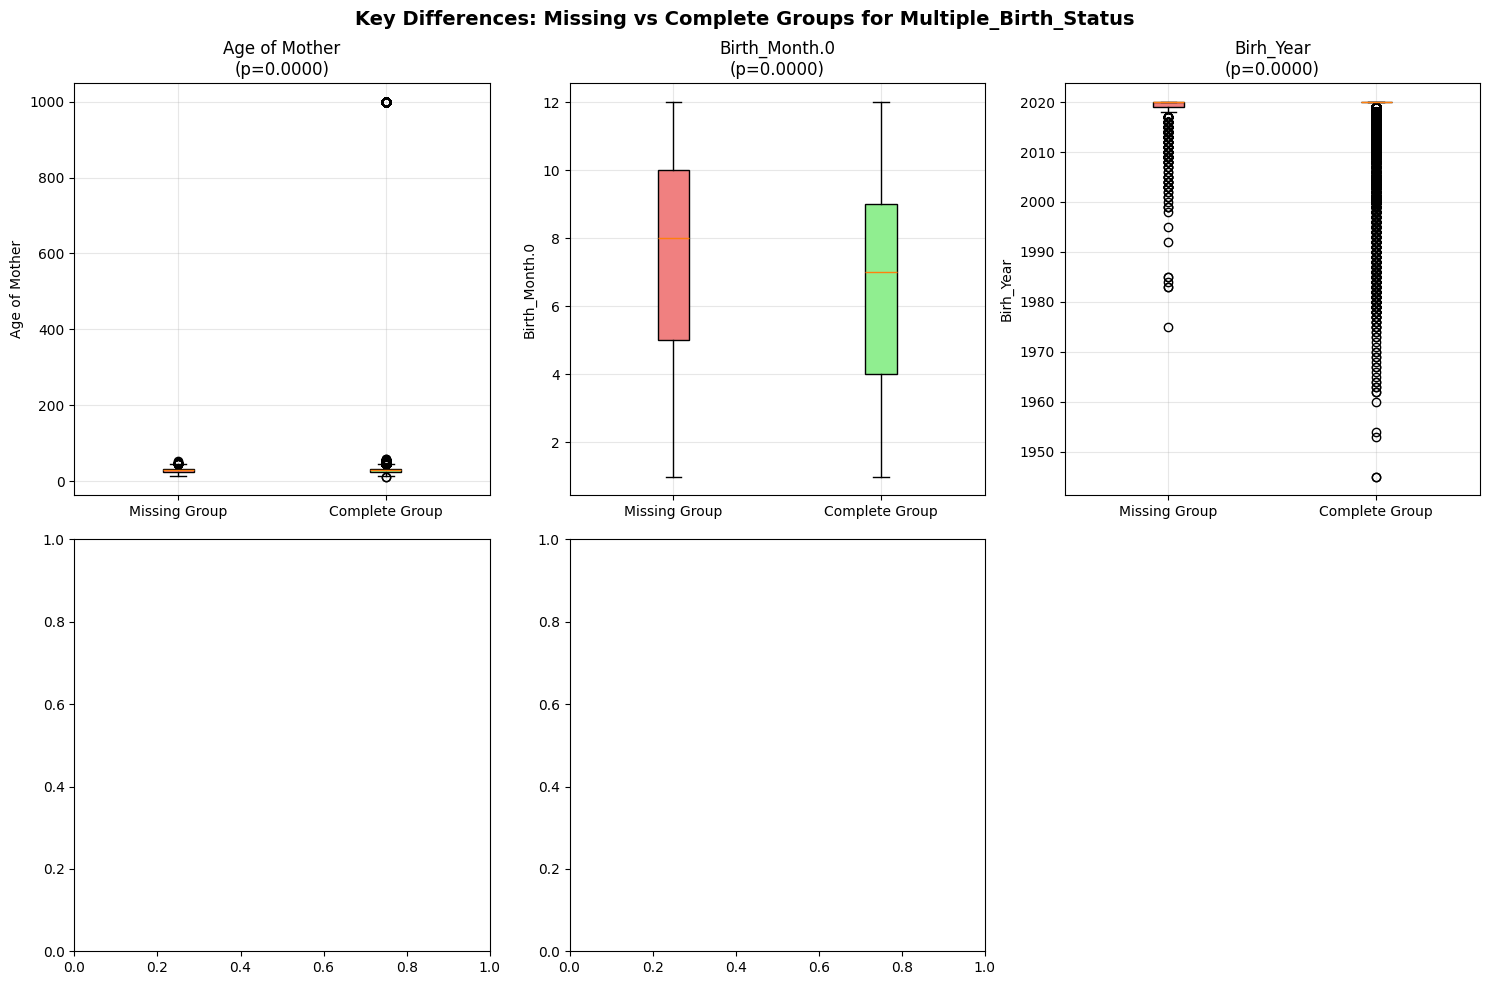

✅ Saved: Multiple_Birth_Status_bias_comparison.png

📋 BIAS ANALYSIS SUMMARY FOR 'Multiple_Birth_Status'

📊 MISSING DATA OVERVIEW:
   • Total records: 301,712
   • Missing Multiple_Birth_Status: 4,163 (1.38%)
   • Complete Multiple_Birth_Status: 297,549 (98.62%)

🔍 BIAS DETECTION RESULTS:
   • Total comparisons: 17
   • Significant bias detected: 11

📌 VARIABLES WITH SIGNIFICANT BIAS:
   • Birh_Year (Numeric): p=0.0000
   • Birth_Month.0 (Numeric): p=0.0000
   • Age of Mother (Numeric): p=0.0000
   • Registered_Month (Categorical): p=0.0000
   • Registered_District (Categorical): p=0.0000
   • Birth_Month (Categorical): p=0.0000
   • Hospital or Not (Categorical): p=0.0000
   • Marital_Status (Categorical): p=0.0000
   • District_of_Mother (Categorical): p=0.0000
   • Race_of_Mother (Categorical): p=0.0000

📁 FILES CREATED:
   • missing_analysis_Multiple_Birth_Status.xlsx - Complete dataset with missing and complete records
   • Multiple_Birth_Status_bias_comparison.png - Visualization 

In [24]:



# ============================================
# FOCUS ON BIRTH WEIGHT - CHANGE THIS VARIABLE NAME TO ANALYZE OTHER VARIABLES
# ============================================
TARGET_VARIABLE = 'Multiple_Birth_Status'  # <-- CHANGE THIS to analyze other variables
# ============================================

print(f"\n{'='*70}")
print(f"📊 MISSING DATA BIAS ANALYSIS FOR: '{TARGET_VARIABLE}'")
print(f"{'='*70}")

# Check if variable exists
if TARGET_VARIABLE not in df.columns:
    print(f"❌ ERROR: Variable '{TARGET_VARIABLE}' not found!")
    print(f"Available columns: {list(df.columns)[:20]}...")
    exit()

# Get missing info
missing_count = df[TARGET_VARIABLE].isnull().sum()
missing_pct = (missing_count / len(df)) * 100
complete_count = len(df) - missing_count
complete_pct = 100 - missing_pct

print(f"\n📌 BASIC INFORMATION:")
print(f"   • Total Records: {len(df):,}")
print(f"   • Missing in {TARGET_VARIABLE}: {missing_count:,} ({missing_pct:.2f}%)")
print(f"   • Complete cases: {complete_count:,} ({complete_pct:.2f}%)")

# ============================================
# STEP 1: CREATE SEPARATE DATASETS
# ============================================

print(f"\n📌 STEP 1: CREATING SEPARATE DATASETS")
print("-" * 50)

# Dataset 1: Records with missing birth weight
missing_data = df[df[TARGET_VARIABLE].isnull()]

# Dataset 2: Records with complete birth weight
complete_data = df[df[TARGET_VARIABLE].notnull()]

print(f"   • Missing records: {len(missing_data):,}")
print(f"   • Complete records: {len(complete_data):,}")

# Save to Excel file
filename = f'missing_analysis_{TARGET_VARIABLE}.xlsx'

with pd.ExcelWriter(filename, engine='openpyxl') as writer:
    # Sheet 1: All records with missing birth weight
    missing_data.to_excel(writer, sheet_name=f'Missing_{TARGET_VARIABLE}', index=False)
    
    # Sheet 2: All records with complete birth weight
    complete_data.to_excel(writer, sheet_name=f'Complete_{TARGET_VARIABLE}', index=False)
    
    # Sheet 3: Summary statistics
    summary = pd.DataFrame({
        'Metric': [
            'Variable Name',
            'Total Records',
            f'Missing in {TARGET_VARIABLE}',
            'Missing %',
            f'Complete {TARGET_VARIABLE}',
            'Complete %'
        ],
        'Value': [
            TARGET_VARIABLE,
            f"{len(df):,}",
            f"{missing_count:,}",
            f"{missing_pct:.2f}%",
            f"{complete_count:,}",
            f"{complete_pct:.2f}%"
        ]
    })
    summary.to_excel(writer, sheet_name='Summary', index=False)

print(f"✅ Created: {filename}")

# ============================================
# STEP 2: COMPARE MISSING VS COMPLETE GROUPS
# ============================================

print(f"\n📌 STEP 2: BIAS ANALYSIS - COMPARING GROUPS")
print("-" * 70)

bias_results = []

# Compare NUMERIC variables
print(f"\n🔍 Comparing NUMERIC variables between groups:")

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for num_col in numeric_cols:
    if num_col != TARGET_VARIABLE:
        # Get means for both groups (ignoring missing in the comparison variable)
        missing_mean = missing_data[num_col].mean()
        complete_mean = complete_data[num_col].mean()
        
        # Only compare if both groups have data
        if not np.isnan(missing_mean) and not np.isnan(complete_mean):
            # Statistical test
            try:
                t_stat, p_value = stats.ttest_ind(
                    missing_data[num_col].dropna(),
                    complete_data[num_col].dropna(),
                    equal_var=False
                )
                
                bias_detected = p_value < 0.05
                
                bias_results.append({
                    'Variable_Type': 'Numeric',
                    'Variable_Name': num_col,
                    'Missing_Group_Mean': f"{missing_mean:.2f}",
                    'Complete_Group_Mean': f"{complete_mean:.2f}",
                    'Difference': f"{missing_mean - complete_mean:.2f}",
                    'Difference_%': f"{((missing_mean - complete_mean) / complete_mean * 100):.1f}%" if complete_mean != 0 else "N/A",
                    'P_Value': f"{p_value:.4f}",
                    'Significant_Bias': 'YES' if bias_detected else 'NO'
                })
                
                if bias_detected:
                    print(f"   ⚠️  {num_col}:")
                    print(f"      Missing group: {missing_mean:.2f} vs Complete: {complete_mean:.2f}")
                    print(f"      Difference: {missing_mean - complete_mean:.2f} (p={p_value:.4f})")
            except:
                pass

# Compare CATEGORICAL variables
print(f"\n🔍 Comparing CATEGORICAL variables between groups:")

cat_cols = df.select_dtypes(include=['object', 'category']).columns

for cat_col in cat_cols:
    if cat_col != TARGET_VARIABLE:
        try:
            # Create contingency table
            missing_indicator = ['Missing' if x else 'Complete' for x in df[TARGET_VARIABLE].isnull()]
            contingency = pd.crosstab(
                pd.Series(missing_indicator, name='Group'),
                df[cat_col]
            )
            
            # Chi-square test
            chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
            
            bias_detected = p_value < 0.05
            
            # Get distributions
            missing_dist = missing_data[cat_col].value_counts(normalize=True).head(3)
            complete_dist = complete_data[cat_col].value_counts(normalize=True).head(3)
            
            bias_results.append({
                'Variable_Type': 'Categorical',
                'Variable_Name': cat_col,
                'Missing_Group_Mean': str(dict(missing_dist))[:50],
                'Complete_Group_Mean': str(dict(complete_dist))[:50],
                'Difference': 'N/A',
                'Difference_%': 'N/A',
                'P_Value': f"{p_value:.4f}",
                'Significant_Bias': 'YES' if bias_detected else 'NO'
            })
            
            if bias_detected:
                print(f"   ⚠️  {cat_col}: p={p_value:.4f} - Significant bias detected")
        except:
            pass

# ============================================
# STEP 3: ADD BIAS RESULTS TO EXCEL
# ============================================

print(f"\n📌 STEP 3: ADDING BIAS ANALYSIS TO EXCEL")
print("-" * 50)

# Add bias results to the Excel file
with pd.ExcelWriter(filename, engine='openpyxl', mode='a') as writer:
    if bias_results:
        bias_df = pd.DataFrame(bias_results)
        bias_df = bias_df.sort_values('P_Value')
        bias_df.to_excel(writer, sheet_name='Bias_Analysis', index=False)
        print(f"   ✅ Added Bias Analysis sheet with {len(bias_df)} comparisons")

print(f"\n✅ Updated Excel file: {filename}")

# ============================================
# STEP 4: VISUALIZE KEY DIFFERENCES
# ============================================

print(f"\n📌 STEP 4: CREATING VISUALIZATIONS")
print("-" * 50)

# Select top 5 numeric variables with largest differences
numeric_bias = [r for r in bias_results if r['Variable_Type'] == 'Numeric' and r['Significant_Bias'] == 'YES']
numeric_bias = sorted(numeric_bias, key=lambda x: abs(float(x['Difference'])), reverse=True)[:5]

if numeric_bias:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, bias in enumerate(numeric_bias):
        if i < 5:
            var_name = bias['Variable_Name']
            
            # Create boxplot comparison
            data_to_plot = [
                missing_data[var_name].dropna(),
                complete_data[var_name].dropna()
            ]
            
            bp = axes[i].boxplot(data_to_plot, patch_artist=True, labels=['Missing Group', 'Complete Group'])
            bp['boxes'][0].set_facecolor('lightcoral')
            bp['boxes'][1].set_facecolor('lightgreen')
            axes[i].set_title(f'{var_name}\n(p={bias["P_Value"]})')
            axes[i].set_ylabel(var_name)
            axes[i].grid(True, alpha=0.3)
    
    # Hide empty subplot
    if len(numeric_bias) < 5:
        axes[5].axis('off')
    
    plt.suptitle(f'Key Differences: Missing vs Complete Groups for {TARGET_VARIABLE}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{TARGET_VARIABLE}_bias_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {TARGET_VARIABLE}_bias_comparison.png")

# ============================================
# STEP 5: SUMMARY REPORT
# ============================================

print(f"\n{'='*70}")
print(f"📋 BIAS ANALYSIS SUMMARY FOR '{TARGET_VARIABLE}'")
print(f"{'='*70}")

print(f"\n📊 MISSING DATA OVERVIEW:")
print(f"   • Total records: {len(df):,}")
print(f"   • Missing {TARGET_VARIABLE}: {missing_count:,} ({missing_pct:.2f}%)")
print(f"   • Complete {TARGET_VARIABLE}: {complete_count:,} ({complete_pct:.2f}%)")

print(f"\n🔍 BIAS DETECTION RESULTS:")
if bias_results:
    significant_bias = [r for r in bias_results if r['Significant_Bias'] == 'YES']
    print(f"   • Total comparisons: {len(bias_results)}")
    print(f"   • Significant bias detected: {len(significant_bias)}")
    
    if significant_bias:
        print(f"\n📌 VARIABLES WITH SIGNIFICANT BIAS:")
        for bias in significant_bias[:10]:  # Show top 10
            print(f"   • {bias['Variable_Name']} ({bias['Variable_Type']}): p={bias['P_Value']}")
else:
    print(f"   • No bias comparisons could be performed")

print(f"\n📁 FILES CREATED:")
print(f"   • {filename} - Complete dataset with missing and complete records")
if numeric_bias:
    print(f"   • {TARGET_VARIABLE}_bias_comparison.png - Visualization of key differences")

print(f"\n{'='*70}")
print(f"✅ ANALYSIS COMPLETE")
print(f"{'='*70}")  # <-- FIXED: removed the '=' inside the f-string

# ============================================
# STEP 6: QUICK RECOMMENDATIONS
# ============================================

print(f"\n📋 RECOMMENDATIONS FOR '{TARGET_VARIABLE}':")
print("-" * 50)

if missing_pct < 1:
    print(f"✅ Very few missing ({missing_pct:.1f}%) - Can drop rows or use simple imputation")
elif missing_pct < 5:
    print(f"🟡 Some missing ({missing_pct:.1f}%) - Imputation recommended")
    if significant_bias:
        print(f"   ⚠️  But bias detected - consider keeping missing indicator")
elif missing_pct < 20:
    print(f"🟠 Moderate missing ({missing_pct:.1f}%) - Careful handling needed")
    if significant_bias:
        print(f"   ⚠️  Bias detected - missingness may be informative")
    else:
        print(f"   ✅ No significant bias - imputation may be safe")
elif missing_pct < 50:
    print(f"🔴 High missing ({missing_pct:.1f}%) - Consider dropping or creating missing category")
else:
    print(f"⚫ Very high missing ({missing_pct:.1f}%) - Likely drop this variable")


📊 COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING Birth_Order - Copy RECORDS

📌 DATASET OVERVIEW:
   • Total records with missing Birth_Order - Copy: 26,007
   • Total records with complete Birth_Order - Copy: 275,705

📌 PART 1: UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE

📌 PART 2: MULTIVARIATE ANALYSIS - CORRELATIONS AND PATTERNS

🔍 CORRELATION MATRIX (Numeric Variables):

   No strong correlations found between numeric variables

🔍 CATEGORICAL ASSOCIATIONS:
   • Registered_Month & Registered_District: p=0.0000, Cramer's V=0.162
   • Registered_Month & Birth_Month: p=0.0000, Cramer's V=0.455
   • Registered_Month & Hospital or Not: p=0.0000, Cramer's V=0.042
   • Registered_District & Birth_Month: p=0.0000, Cramer's V=0.114
   • Registered_District & Hospital or Not: p=0.0000, Cramer's V=0.190

📌 PART 3: MISSINGNESS PATTERN ANALYSIS

🔍 VARIABLES THAT TEND TO BE MISSING TOGETHER:
   • Race_of_Mother & Race_of_Father: 0.422

📌 PART 4: CREATING COMPREHENSIVE STATISTICAL R

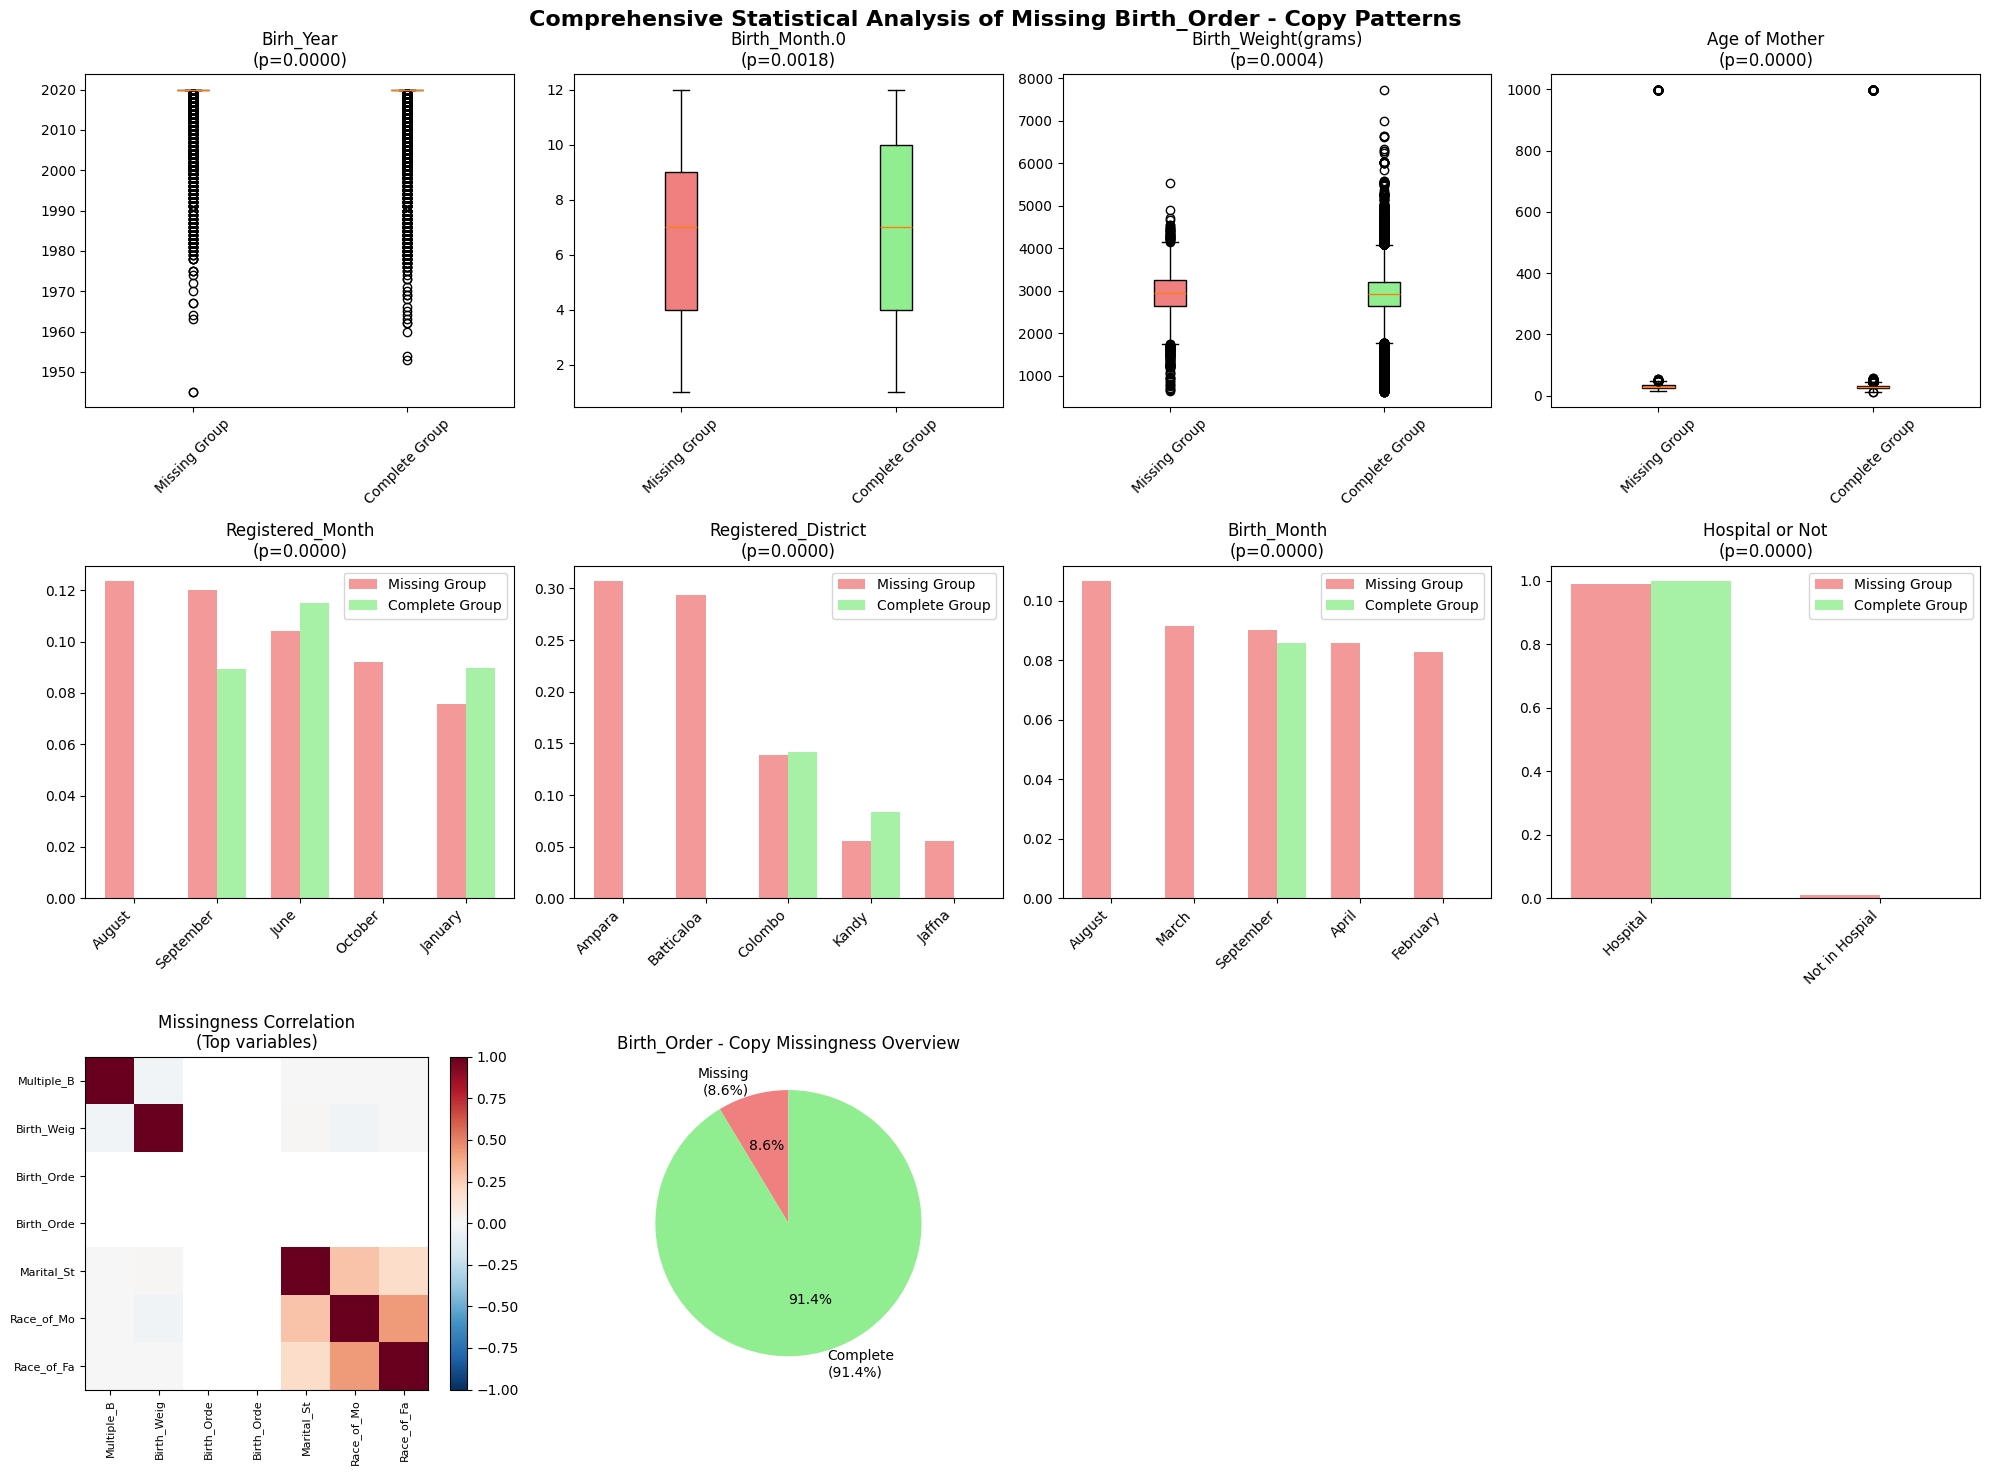


📋 COMPREHENSIVE STATISTICAL SUMMARY

📊 OVERALL STATISTICS:
   • Total missing Birth_Order - Copy records: 26,007 (8.6% of total)
   • Number of variables analyzed: 18
   • Numeric variables: 8
   • Categorical variables: 10

🔍 VARIABLES WITH SIGNIFICANT DIFFERENCES (p < 0.05):
   • Registered_Month: Most common='August' (12.3%), p=0.0000
   • Registered_District: Most common='Ampara' (30.7%), p=0.0000
   • Birh_Year: Mean=2019.05 vs Complete Mean (diff: -0.66, p=0.0000)
   • Birth_Month.0: Mean=6.51 vs Complete Mean (diff: -0.07, p=0.0018)
   • Birth_Month: Most common='August' (10.7%), p=0.0000
   • Hospital or Not: Most common='Hospital' (99.0%), p=0.0000
   • Multiple_Birth_Status: Most common='missing' (99.6%), p=0.0000
   • Birth_Weight(grams): Mean=2941.07 vs Complete Mean (diff: 23.86, p=0.0004)
   • Age of Mother: Mean=31.23 vs Complete Mean (diff: 1.75, p=0.0000)
   • Marital_Status: Most common='Married' (95.6%), p=0.0000
   • District_of_Mother: Most common='Ampara' (30.3%)

In [25]:
# ============================================
# FOCUS ON BIRTH ORDER - CHANGE THIS VARIABLE NAME TO ANALYZE OTHER VARIABLES
# ============================================
TARGET_VARIABLE = 'Birth_Order - Copy'  # <-- CHANGE THIS to analyze other variables
# ============================================

# ============================================
# COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING BIRTH ORDER PATTERNS
# (Modified to handle qualitative target variables)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output

print(f"\n{'='*80}")
print(f"📊 COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING {TARGET_VARIABLE} RECORDS")
print(f"{'='*80}")

# Load the missing data
missing_data = df[df[TARGET_VARIABLE].isnull()].copy()
complete_data = df[df[TARGET_VARIABLE].notnull()].copy()

print(f"\n📌 DATASET OVERVIEW:")
print(f"   • Total records with missing {TARGET_VARIABLE}: {len(missing_data):,}")
print(f"   • Total records with complete {TARGET_VARIABLE}: {len(complete_data):,}")

# ============================================
# 1. UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 1: UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE")
print(f"{'='*80}")

# Create a comprehensive statistics dataframe
all_stats = []

# Analyze each column in the missing data
for col in missing_data.columns:
    if col == TARGET_VARIABLE:
        continue
        
    col_stats = {
        'Variable': col,
        'Data_Type': str(missing_data[col].dtype),
        'Missing_in_Group': missing_data[col].isnull().sum(),
        'Missing_in_Group_%': (missing_data[col].isnull().sum() / len(missing_data)) * 100,
        'Complete_in_Group': missing_data[col].notnull().sum(),
        'Complete_in_Group_%': (missing_data[col].notnull().sum() / len(missing_data)) * 100,
        'Unique_Values': missing_data[col].nunique(),
    }
    
    # Statistics based on data type
    if missing_data[col].dtype in ['int64', 'float64']:
        # NUMERIC VARIABLE STATISTICS
        valid_data = missing_data[col].dropna()
        complete_valid_data = complete_data[col].dropna() if col in complete_data.columns else pd.Series()
        
        if len(valid_data) > 0:
            # Check if data has variance before calculating stats
            if valid_data.nunique() > 1:  # More than one unique value
                try:
                    # Central tendency
                    col_stats.update({
                        'Mean': valid_data.mean(),
                        'Median': valid_data.median(),
                        'Mode': valid_data.mode().iloc[0] if len(valid_data.mode()) > 0 else np.nan,
                        'Std_Dev': valid_data.std(),
                        'Variance': valid_data.var(),
                        'Min': valid_data.min(),
                        'Max': valid_data.max(),
                        'Range': valid_data.max() - valid_data.min(),
                        'Q1': valid_data.quantile(0.25),
                        'Q3': valid_data.quantile(0.75),
                        'IQR': valid_data.quantile(0.75) - valid_data.quantile(0.25),
                    })
                    
                    # Skewness and kurtosis (with warning suppression)
                    with warnings.catch_warnings():
                        warnings.simplefilter("ignore")
                        col_stats['Skewness'] = valid_data.skew()
                        col_stats['Kurtosis'] = valid_data.kurtosis()
                except:
                    col_stats.update({
                        'Mean': np.nan, 'Median': np.nan, 'Mode': np.nan, 'Std_Dev': np.nan,
                        'Variance': np.nan, 'Min': np.nan, 'Max': np.nan, 'Range': np.nan,
                        'Q1': np.nan, 'Q3': np.nan, 'IQR': np.nan, 'Skewness': np.nan, 'Kurtosis': np.nan
                    })
            else:
                # All values are the same
                constant_value = valid_data.iloc[0] if len(valid_data) > 0 else np.nan
                col_stats.update({
                    'Mean': constant_value, 'Median': constant_value, 'Mode': constant_value,
                    'Std_Dev': 0, 'Variance': 0, 'Min': constant_value, 'Max': constant_value,
                    'Range': 0, 'Q1': constant_value, 'Q3': constant_value, 'IQR': 0,
                    'Skewness': 0, 'Kurtosis': 0
                })
            
            # Compare with complete data
            if len(complete_valid_data) > 0:
                if len(valid_data) > 1 and len(complete_valid_data) > 1:
                    try:
                        t_stat, p_value = stats.ttest_ind(valid_data, complete_valid_data, equal_var=False)
                        col_stats['T_Test_P_Value'] = p_value
                        col_stats['Significant_Difference'] = 'YES' if p_value < 0.05 else 'NO'
                        
                        # Effect size (Cohen's d)
                        pooled_std = np.sqrt((valid_data.std()**2 + complete_valid_data.std()**2) / 2)
                        if pooled_std > 0:
                            col_stats['Effect_Size'] = (valid_data.mean() - complete_valid_data.mean()) / pooled_std
                        else:
                            col_stats['Effect_Size'] = 0
                            
                        col_stats['Mean_Difference'] = valid_data.mean() - complete_valid_data.mean()
                        if complete_valid_data.mean() != 0:
                            col_stats['Mean_Difference_%'] = ((valid_data.mean() - complete_valid_data.mean()) / abs(complete_valid_data.mean())) * 100
                        else:
                            col_stats['Mean_Difference_%'] = np.nan
                    except:
                        col_stats['T_Test_P_Value'] = np.nan
                        col_stats['Significant_Difference'] = 'NO'
                        col_stats['Effect_Size'] = np.nan
                        col_stats['Mean_Difference'] = np.nan
                        col_stats['Mean_Difference_%'] = np.nan
                else:
                    col_stats['T_Test_P_Value'] = np.nan
                    col_stats['Significant_Difference'] = 'INSUFFICIENT_DATA'
                    col_stats['Effect_Size'] = np.nan
                    col_stats['Mean_Difference'] = np.nan
                    col_stats['Mean_Difference_%'] = np.nan
            else:
                col_stats['T_Test_P_Value'] = np.nan
                col_stats['Significant_Difference'] = 'N/A'
                col_stats['Effect_Size'] = np.nan
                col_stats['Mean_Difference'] = np.nan
                col_stats['Mean_Difference_%'] = np.nan
        else:
            # No valid data in missing group
            col_stats.update({
                'Mean': np.nan, 'Median': np.nan, 'Mode': np.nan, 'Std_Dev': np.nan,
                'Variance': np.nan, 'Min': np.nan, 'Max': np.nan, 'Range': np.nan,
                'Q1': np.nan, 'Q3': np.nan, 'IQR': np.nan, 'Skewness': np.nan, 'Kurtosis': np.nan,
                'T_Test_P_Value': np.nan, 'Significant_Difference': 'N/A', 'Effect_Size': np.nan,
                'Mean_Difference': np.nan, 'Mean_Difference_%': np.nan
            })
            
    else:
        # CATEGORICAL VARIABLE STATISTICS
        valid_data = missing_data[col].dropna()
        
        if len(valid_data) > 0:
            value_counts = valid_data.value_counts()
            top_categories = value_counts.head(5)
            
            col_stats.update({
                'Most_Common': str(top_categories.index[0]) if len(top_categories) > 0 else np.nan,
                'Most_Common_Count': int(top_categories.iloc[0]) if len(top_categories) > 0 else 0,
                'Most_Common_%': (top_categories.iloc[0] / len(valid_data)) * 100 if len(top_categories) > 0 else 0,
                '2nd_Common': str(top_categories.index[1]) if len(top_categories) > 1 else np.nan,
                '2nd_Common_%': (top_categories.iloc[1] / len(valid_data)) * 100 if len(top_categories) > 1 else 0,
                '3rd_Common': str(top_categories.index[2]) if len(top_categories) > 2 else np.nan,
                '3rd_Common_%': (top_categories.iloc[2] / len(valid_data)) * 100 if len(top_categories) > 2 else 0,
            })
            
            # Calculate entropy if there are multiple categories
            if len(value_counts) > 1:
                try:
                    col_stats['Entropy'] = stats.entropy(value_counts.values)
                except:
                    col_stats['Entropy'] = 0
            else:
                col_stats['Entropy'] = 0
            
            # Chi-square test comparing with complete data
            if col in complete_data.columns:
                complete_valid = complete_data[col].dropna()
                if len(complete_valid) > 0:
                    try:
                        # Create contingency table
                        missing_cats = valid_data.value_counts()
                        complete_cats = complete_valid.value_counts()
                        
                        # Align categories
                        all_cats = sorted(set(missing_cats.index) | set(complete_cats.index))
                        missing_counts = [missing_cats.get(cat, 0) for cat in all_cats]
                        complete_counts = [complete_cats.get(cat, 0) for cat in all_cats]
                        
                        # Chi-square test (only if enough data)
                        if len(all_cats) > 1 and sum(missing_counts) > 0 and sum(complete_counts) > 0:
                            contingency = np.array([missing_counts, complete_counts])
                            chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
                            
                            col_stats['Chi_Square_P_Value'] = p_value
                            col_stats['Significant_Difference'] = 'YES' if p_value < 0.05 else 'NO'
                            
                            # Cramer's V
                            n = sum(missing_counts) + sum(complete_counts)
                            min_dim = min(contingency.shape) - 1
                            if min_dim > 0:
                                col_stats['Cramers_V'] = np.sqrt(chi2 / (n * min_dim))
                            else:
                                col_stats['Cramers_V'] = 0
                        else:
                            col_stats['Chi_Square_P_Value'] = np.nan
                            col_stats['Significant_Difference'] = 'INSUFFICIENT_DATA'
                            col_stats['Cramers_V'] = np.nan
                    except:
                        col_stats['Chi_Square_P_Value'] = np.nan
                        col_stats['Significant_Difference'] = 'ERROR'
                        col_stats['Cramers_V'] = np.nan
                else:
                    col_stats['Chi_Square_P_Value'] = np.nan
                    col_stats['Significant_Difference'] = 'N/A'
                    col_stats['Cramers_V'] = np.nan
        else:
            col_stats.update({
                'Most_Common': np.nan, 'Most_Common_Count': 0, 'Most_Common_%': 0,
                '2nd_Common': np.nan, '2nd_Common_%': 0,
                '3rd_Common': np.nan, '3rd_Common_%': 0,
                'Entropy': 0, 'Chi_Square_P_Value': np.nan,
                'Significant_Difference': 'N/A', 'Cramers_V': np.nan
            })
    
    all_stats.append(col_stats)

# Convert to DataFrame
stats_df = pd.DataFrame(all_stats)

# ============================================
# 2. MULTIVARIATE ANALYSIS - CORRELATIONS AND PATTERNS
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 2: MULTIVARIATE ANALYSIS - CORRELATIONS AND PATTERNS")
print(f"{'='*80}")

# Correlation matrix for numeric variables
numeric_vars = missing_data.select_dtypes(include=['int64', 'float64']).columns.tolist()
if len(numeric_vars) > 1:
    print(f"\n🔍 CORRELATION MATRIX (Numeric Variables):")
    
    # Calculate correlations (handle non-numeric safely)
    try:
        corr_matrix = missing_data[numeric_vars].corr()
        
        # Find strong correlations
        strong_corrs = []
        for i in range(len(corr_matrix.columns)):
            for j in range(i+1, len(corr_matrix.columns)):
                corr_value = corr_matrix.iloc[i, j]
                if not pd.isna(corr_value) and abs(corr_value) > 0.5:  # Strong correlation threshold
                    strong_corrs.append({
                        'Variable_1': corr_matrix.columns[i],
                        'Variable_2': corr_matrix.columns[j],
                        'Correlation': corr_value,
                        'Strength': 'Very Strong' if abs(corr_value) > 0.8 else 'Strong'
                    })
        
        if strong_corrs:
            print("\n   Strong Correlations Found:")
            for corr in strong_corrs:
                print(f"   • {corr['Variable_1']} & {corr['Variable_2']}: {corr['Correlation']:.3f} ({corr['Strength']})")
        else:
            print("\n   No strong correlations found between numeric variables")
    except:
        print("\n   Could not calculate correlations for numeric variables")
else:
    print(f"\n🔍 CORRELATION MATRIX (Numeric Variables):")
    print("\n   Not enough numeric variables for correlation analysis")

# Association for categorical variables - FIXED the warning
print(f"\n🔍 CATEGORICAL ASSOCIATIONS:")

# FIXED: Use both 'object' and 'string' for pandas 2.0+ compatibility
categorical_vars = missing_data.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

if len(categorical_vars) > 1:
    from scipy.stats import chi2_contingency
    
    associations_found = False
    for i in range(min(5, len(categorical_vars))):
        for j in range(i+1, min(5, len(categorical_vars))):
            var1, var2 = categorical_vars[i], categorical_vars[j]
            
            try:
                # Create contingency table
                contingency = pd.crosstab(
                    missing_data[var1].fillna('MISSING').astype(str), 
                    missing_data[var2].fillna('MISSING').astype(str)
                )
                
                if contingency.size > 0 and contingency.shape[0] > 1 and contingency.shape[1] > 1:
                    chi2, p_value, dof, expected = chi2_contingency(contingency)
                    if p_value < 0.05:
                        associations_found = True
                        # Calculate Cramer's V
                        n = contingency.sum().sum()
                        min_dim = min(contingency.shape) - 1
                        if min_dim > 0:
                            cramer_v = np.sqrt(chi2 / (n * min_dim))
                        else:
                            cramer_v = 0
                        print(f"   • {var1} & {var2}: p={p_value:.4f}, Cramer's V={cramer_v:.3f}")
            except:
                continue
    
    if not associations_found:
        print("   No significant associations found between categorical variables")
else:
    print("   Not enough categorical variables for association analysis")

# ============================================
# 3. MISSINGNESS PATTERN ANALYSIS
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 3: MISSINGNESS PATTERN ANALYSIS")
print(f"{'='*80}")

# Create missingness matrix
missing_matrix = missing_data.isnull()

# Calculate missingness correlation (only for columns with some missingness)
cols_with_missing = missing_matrix.columns[missing_matrix.sum() > 0].tolist()
if len(cols_with_missing) > 1:
    missing_corr = missing_matrix[cols_with_missing].corr()

    print(f"\n🔍 VARIABLES THAT TEND TO BE MISSING TOGETHER:")
    high_missing_corr = []
    for i in range(len(missing_corr.columns)):
        for j in range(i+1, len(missing_corr.columns)):
            corr_val = missing_corr.iloc[i, j]
            if not pd.isna(corr_val) and abs(corr_val) > 0.3:
                high_missing_corr.append({
                    'Var1': missing_corr.columns[i],
                    'Var2': missing_corr.columns[j],
                    'Correlation': corr_val
                })

    if high_missing_corr:
        for item in sorted(high_missing_corr, key=lambda x: abs(x['Correlation']), reverse=True)[:10]:
            print(f"   • {item['Var1']} & {item['Var2']}: {item['Correlation']:.3f}")
    else:
        print("   No strong missingness correlations found")
else:
    print("   Not enough variables with missingness for correlation analysis")
    missing_corr = pd.DataFrame()  # Empty DataFrame for later use

# ============================================
# 4. CREATE COMPREHENSIVE EXCEL REPORT
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 4: CREATING COMPREHENSIVE STATISTICAL REPORT")
print(f"{'='*80}")

output_file = f'missing_{TARGET_VARIABLE.replace(" ", "_")}_comprehensive_stats.xlsx'

try:
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        
        # Sheet 1: Variable-level Statistics
        stats_df.to_excel(writer, sheet_name='Variable_Statistics', index=False)
        
        # Sheet 2: Summary Statistics
        summary_stats = pd.DataFrame({
            'Metric': [f'Total Missing {TARGET_VARIABLE} Records', 'Total Variables', 'Numeric Variables', 'Categorical Variables'],
            'Value': [
                len(missing_data),
                len(missing_data.columns),
                len(numeric_vars),
                len(categorical_vars)
            ]
        })
        summary_stats.to_excel(writer, sheet_name='Summary', index=False)
        
        # Sheet 3: Variables with Significant Differences
        if 'Significant_Difference' in stats_df.columns:
            sig_diff = stats_df[stats_df['Significant_Difference'] == 'YES']
            if not sig_diff.empty:
                sig_diff.to_excel(writer, sheet_name='Significant_Differences', index=False)
        
        # Sheet 4: Missingness Correlation
        if not missing_corr.empty:
            missing_corr.to_excel(writer, sheet_name='Missing_Correlations')
        
        # Sheet 5: Numeric Correlations
        if len(numeric_vars) > 1 and 'corr_matrix' in locals():
            corr_matrix.to_excel(writer, sheet_name='Numeric_Correlations')
        
        # Sheet 6: Frequency Tables for Key Categorical Variables
        cats_added = 0
        for cat_var in categorical_vars[:5]:  # Limit to first 5
            if missing_data[cat_var].notna().sum() > 0:
                try:
                    freq_table = pd.DataFrame({
                        'Category': missing_data[cat_var].value_counts().index,
                        'Count': missing_data[cat_var].value_counts().values,
                        'Percentage': (missing_data[cat_var].value_counts().values / len(missing_data)) * 100
                    })
                    # Clean sheet name
                    sheet_name = f'Freq_{cat_var}'[:25]  # Limit sheet name length
                    sheet_name = ''.join(c for c in sheet_name if c.isalnum() or c in ' _-')[:31]
                    freq_table.to_excel(writer, sheet_name=sheet_name, index=False)
                    cats_added += 1
                except:
                    continue
        
        if cats_added == 0:
            print("   No frequency tables could be created")

    print(f"✅ Created comprehensive statistical report: {output_file}")
except Exception as e:
    print(f"❌ Error creating Excel file: {e}")
    output_file = None

# ============================================
# 5. VISUALIZATIONS
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 5: CREATING STATISTICAL VISUALIZATIONS")
print(f"{'='*80}")

# Create a multi-panel figure
fig = plt.figure(figsize=(20, 15))
plot_count = 0

# 1. Box plots for numeric variables with significant differences
if 'Significant_Difference' in stats_df.columns:
    sig_numeric = stats_df[(stats_df['Data_Type'].str.contains('int|float', na=False)) & 
                          (stats_df['Significant_Difference'] == 'YES')]
    
    if len(sig_numeric) > 0:
        for i, (idx, row) in enumerate(sig_numeric.head(6).iterrows()):
            if i < 6 and plot_count < 12:
                plot_count += 1
                ax = plt.subplot(3, 4, plot_count)
                var_name = row['Variable']
                
                if var_name in missing_data.columns and var_name in complete_data.columns:
                    missing_vals = missing_data[var_name].dropna()
                    complete_vals = complete_data[var_name].dropna()
                    
                    if len(missing_vals) > 0 and len(complete_vals) > 0:
                        # FIXED: Use tick_labels instead of labels for matplotlib 3.9+
                        bp = ax.boxplot([missing_vals, complete_vals], 
                                       tick_labels=['Missing Group', 'Complete Group'],
                                       patch_artist=True)
                        bp['boxes'][0].set_facecolor('lightcoral')
                        bp['boxes'][1].set_facecolor('lightgreen')
                        
                        p_val = row.get('T_Test_P_Value', np.nan)
                        if pd.notna(p_val):
                            ax.set_title(f'{var_name}\n(p={p_val:.4f})')
                        else:
                            ax.set_title(f'{var_name}')
                        ax.tick_params(axis='x', rotation=45)

# 2. Bar plots for categorical variables with significant differences
if 'Significant_Difference' in stats_df.columns:
    sig_cat = stats_df[(~stats_df['Data_Type'].str.contains('int|float', na=False)) & 
                      (stats_df['Significant_Difference'] == 'YES')]
    
    for i, (idx, row) in enumerate(sig_cat.head(4).iterrows()):
        if i < 4 and plot_count < 12:
            plot_count += 1
            ax = plt.subplot(3, 4, plot_count)
            var_name = row['Variable']
            
            if var_name in missing_data.columns and var_name in complete_data.columns:
                missing_dist = missing_data[var_name].value_counts(normalize=True).head(5)
                complete_dist = complete_data[var_name].value_counts(normalize=True).head(5)
                
                if len(missing_dist) > 0:
                    x = range(len(missing_dist))
                    width = 0.35
                    
                    ax.bar([i - width/2 for i in x], missing_dist.values, width, 
                          label='Missing Group', color='lightcoral', alpha=0.8)
                    
                    # Align complete data with missing categories
                    complete_aligned = [complete_dist.get(cat, 0) for cat in missing_dist.index]
                    ax.bar([i + width/2 for i in x], complete_aligned, width, 
                          label='Complete Group', color='lightgreen', alpha=0.8)
                    
                    p_val = row.get('Chi_Square_P_Value', np.nan)
                    if pd.notna(p_val):
                        ax.set_title(f'{var_name}\n(p={p_val:.4f})')
                    else:
                        ax.set_title(f'{var_name}')
                    
                    ax.set_xticks(x)
                    ax.set_xticklabels([str(cat)[:15] for cat in missing_dist.index], rotation=45, ha='right')
                    ax.legend()

# 3. Missingness correlation heatmap
if not missing_corr.empty and len(missing_corr.columns) > 1 and plot_count < 12:
    plot_count += 1
    ax = plt.subplot(3, 4, plot_count)
    
    # Limit to top 10 variables for readability
    top_cols = missing_corr.columns[:min(10, len(missing_corr.columns))]
    plot_corr = missing_corr.loc[top_cols, top_cols]
    
    im = ax.imshow(plot_corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(top_cols)))
    ax.set_yticks(range(len(top_cols)))
    ax.set_xticklabels([str(c)[:10] for c in top_cols], rotation=90, fontsize=8)
    ax.set_yticklabels([str(c)[:10] for c in top_cols], fontsize=8)
    ax.set_title('Missingness Correlation\n(Top variables)')
    plt.colorbar(im, ax=ax)

# 4. Missing data overview pie chart
if plot_count < 12:
    plot_count += 1
    ax = plt.subplot(3, 4, plot_count)
    missing_pct = (len(missing_data) / len(df)) * 100
    complete_pct = 100 - missing_pct
    ax.pie([missing_pct, complete_pct], 
           labels=[f'Missing\n({missing_pct:.1f}%)', f'Complete\n({complete_pct:.1f}%)'],
           colors=['lightcoral', 'lightgreen'],
           autopct='%1.1f%%',
           startangle=90)
    ax.set_title(f'{TARGET_VARIABLE} Missingness Overview')

# Hide any unused subplots
for i in range(plot_count, 12):
    ax = plt.subplot(3, 4, i+1)
    ax.axis('off')

plt.suptitle(f'Comprehensive Statistical Analysis of Missing {TARGET_VARIABLE} Patterns', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'missing_{TARGET_VARIABLE.replace(" ", "_")}_comprehensive_stats.png', 
            dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 6. FINAL SUMMARY REPORT
# ============================================

print(f"\n{'='*80}")
print(f"📋 COMPREHENSIVE STATISTICAL SUMMARY")
print(f"{'='*80}")

print(f"\n📊 OVERALL STATISTICS:")
print(f"   • Total missing {TARGET_VARIABLE} records: {len(missing_data):,} ({len(missing_data)/len(df)*100:.1f}% of total)")
print(f"   • Number of variables analyzed: {len(missing_data.columns)}")
print(f"   • Numeric variables: {len(numeric_vars)}")
print(f"   • Categorical variables: {len(categorical_vars)}")

print(f"\n🔍 VARIABLES WITH SIGNIFICANT DIFFERENCES (p < 0.05):")
if 'Significant_Difference' in stats_df.columns:
    sig_vars = stats_df[stats_df['Significant_Difference'] == 'YES']
    if len(sig_vars) > 0:
        for idx, row in sig_vars.iterrows():
            if 'Mean' in row and pd.notna(row.get('Mean')):
                diff = row.get('Mean_Difference', np.nan)
                p_val = row.get('T_Test_P_Value', np.nan)
                if pd.notna(p_val):
                    print(f"   • {row['Variable']}: Mean={row['Mean']:.2f} vs Complete Mean (diff: {diff:.2f}, p={p_val:.4f})")
            elif 'Most_Common' in row and pd.notna(row.get('Most_Common')):
                p_val = row.get('Chi_Square_P_Value', np.nan)
                if pd.notna(p_val):
                    print(f"   • {row['Variable']}: Most common='{row['Most_Common']}' ({row['Most_Common_%']:.1f}%), p={p_val:.4f}")
    else:
        print("   • No statistically significant differences found")
else:
    print("   • Could not determine significant differences")

print(f"\n📈 KEY INSIGHTS:")
if 'Significant_Difference' in stats_df.columns:
    sig_count = len(stats_df[stats_df['Significant_Difference'] == 'YES'])
    if sig_count > 5:
        pattern_type = 'SYSTEMATIC'
    elif sig_count > 2:
        pattern_type = 'POSSIBLY SYSTEMATIC'
    else:
        pattern_type = 'LIKELY RANDOM'
    
    print(f"   • Missingness pattern: {pattern_type}")
    print(f"   • Number of variables with strong patterns: {sig_count}")
    
    if sig_count > 0:
        data_type_counts = stats_df[stats_df['Significant_Difference'] == 'YES']['Data_Type'].value_counts()
        if len(data_type_counts) > 0:
            print(f"   • Most affected variable types: {data_type_counts.index[0]}")
else:
    print("   • Missingness pattern: UNKNOWN")
    print(f"   • Number of variables with strong patterns: UNKNOWN")

print(f"\n📁 FILES GENERATED:")
print(f"   • {output_file if output_file else 'Failed to create Excel file'} - Comprehensive statistics for all variables")
print(f"   • missing_{TARGET_VARIABLE.replace(' ', '_')}_comprehensive_stats.png - Statistical visualizations")

print(f"\n{'='*80}")
print(f"✅ COMPREHENSIVE ANALYSIS COMPLETE")
print(f"{'='*80}")

# ============================================
# 7. RECOMMENDATIONS BASED ON STATISTICS
# ============================================

print(f"\n📋 STATISTICAL RECOMMENDATIONS:")
print("-" * 50)

print(f"\nBased on the comprehensive statistical analysis of missing {TARGET_VARIABLE}:")

if 'Significant_Difference' in stats_df.columns:
    sig_count = len(stats_df[stats_df['Significant_Difference'] == 'YES'])
    
    if sig_count > 5:
        print(f"\n🔴 HIGH BIAS DETECTED:")
        print(f"   • Missing {TARGET_VARIABLE} records show significant differences in {sig_count} variables")
        print(f"   • This strongly suggests intentional/patterned missingness")
        print(f"   • Recommendation: Treat missing as a separate category in analysis")
        print(f"   • Investigate the {sig_count} variables listed above for common themes")
        
    elif sig_count > 2:
        print(f"\n🟡 MODERATE BIAS DETECTED:")
        print(f"   • Missing {TARGET_VARIABLE} records show some systematic patterns")
        print(f"   • {sig_count} variables show significant differences")
        print(f"   • Recommendation: Consider multiple imputation or sensitivity analysis")
        print(f"   • Document these patterns in your methodology")
        
    else:
        print(f"\n🟢 LOW BIAS DETECTED:")
        print(f"   • Missing {TARGET_VARIABLE} appears relatively random")
        print(f"   • Few or no variables show significant differences")
        print(f"   • Recommendation: Simple imputation methods may be acceptable")
        print(f"   • Still verify with domain knowledge")
else:
    print(f"\n⚪ BIAS ASSESSMENT INCONCLUSIVE:")
    print(f"   • Could not determine missingness patterns definitively")
    print(f"   • Recommendation: Manual review of the data may be needed")

print(f"\n📊 NEXT STEPS FOR ANALYSIS:")
print(f"   1. Review the 'Variable_Statistics' sheet in the Excel file")
print(f"   2. Examine 'Significant_Differences' sheet for key variables (if available)")
print(f"   3. Check missingness correlations to identify related variables")
print(f"   4. Share findings with domain experts for validation")

print(f"\n{'='*80}")

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import table
import io
import dataframe_image as dfi
import seaborn as sns

from pathlib import Path

# Define paths
DATA_PATH = Path("../../../../data/raw")

In [10]:
# Load data
df = pd.read_excel(DATA_PATH / "2020_Birth_Final.xlsx")

In [11]:
# ============================================
# FOCUS ON BIRTH WEIGHT - ANALYZE MISSING PATTERNS
# ============================================
TARGET_VARIABLE = 'Birth_Weight(grams)'  # <-- Target variable to analyze
# ============================================

# ============================================
# COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING BIRTH WEIGHT PATTERNS
# WITH IUPAC COMPLIANT OUTPUT (Excel, Word, PNG)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
from datetime import datetime
from docx import Document
from docx.shared import Inches, Pt, Cm, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.oxml import OxmlElement
from docx.oxml.ns import qn
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
import os

warnings.filterwarnings('ignore')

# Create timestamp for unique filenames
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

print(f"\n{'='*80}")
print(f"📊 COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING {TARGET_VARIABLE} PATTERNS")
print(f"(IUPAC Compliant Output)")
print(f"{'='*80}")

# Load the missing data
missing_data = df[df[TARGET_VARIABLE].isnull()].copy()
complete_data = df[df[TARGET_VARIABLE].notnull()].copy()

print(f"\n📌 DATASET OVERVIEW:")
print(f"   • Total records with missing {TARGET_VARIABLE}: {len(missing_data):,}")
print(f"   • Total records with complete {TARGET_VARIABLE}: {len(complete_data):,}")
print(f"   • Missing percentage: {(len(missing_data) / len(df)) * 100:.2f}%")

# ============================================
# 1. UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 1: UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE")
print(f"{'='*80}")

# Create a comprehensive statistics dataframe
all_stats = []
significant_vars_list = []  # Store significant variables for Word document

# List all columns to analyze (exclude target variable)
columns_to_analyze = [col for col in missing_data.columns if col != TARGET_VARIABLE]

print(f"\nAnalyzing {len(columns_to_analyze)} variables...")

# Analyze each column
for col in columns_to_analyze:
    col_stats = {
        'Variable': col,
        'Data_Type': str(missing_data[col].dtype),
        'Missing_in_Group': missing_data[col].isnull().sum(),
        'Missing_in_Group_%': (missing_data[col].isnull().sum() / len(missing_data)) * 100,
        'Complete_in_Group': missing_data[col].notnull().sum(),
        'Complete_in_Group_%': (missing_data[col].notnull().sum() / len(missing_data)) * 100,
        'Unique_Values': missing_data[col].nunique(),
    }
    
    # Check if variable is numeric
    if missing_data[col].dtype in ['int64', 'float64'] or pd.api.types.is_numeric_dtype(missing_data[col]):
        # NUMERIC VARIABLE STATISTICS
        valid_data = missing_data[col].dropna()
        complete_valid_data = complete_data[col].dropna() if col in complete_data.columns else pd.Series()
        
        if len(valid_data) > 0:
            if valid_data.nunique() > 1:
                try:
                    col_stats.update({
                        'Mean_Missing': valid_data.mean(),
                        'Median_Missing': valid_data.median(),
                        'Std_Dev_Missing': valid_data.std(),
                        'Min_Missing': valid_data.min(),
                        'Max_Missing': valid_data.max(),
                    })
                except:
                    col_stats.update({
                        'Mean_Missing': np.nan, 'Median_Missing': np.nan, 
                        'Std_Dev_Missing': np.nan, 'Min_Missing': np.nan, 'Max_Missing': np.nan
                    })
            else:
                constant_value = valid_data.iloc[0] if len(valid_data) > 0 else np.nan
                col_stats.update({
                    'Mean_Missing': constant_value, 'Median_Missing': constant_value, 
                    'Std_Dev_Missing': 0, 'Min_Missing': constant_value, 'Max_Missing': constant_value
                })
            
            # Compare with complete data
            if len(complete_valid_data) > 0:
                if len(valid_data) > 1 and len(complete_valid_data) > 1:
                    try:
                        t_stat, p_value = stats.ttest_ind(valid_data, complete_valid_data, equal_var=False)
                        col_stats['P_Value'] = p_value
                        col_stats['Significant_Difference'] = 'YES' if p_value < 0.05 else 'NO'
                        col_stats['Mean_Difference'] = valid_data.mean() - complete_valid_data.mean()
                        
                        # Add complete group statistics
                        col_stats['Mean_Complete'] = complete_valid_data.mean()
                        col_stats['Median_Complete'] = complete_valid_data.median()
                        
                        # Store for detailed report
                        if p_value < 0.05:
                            significant_vars_list.append({
                                'Variable': col,
                                'Type': 'Numeric',
                                'Statistic': f"Mean={valid_data.mean():.2f}",
                                'Comparison': f"Complete Mean={complete_valid_data.mean():.2f}",
                                'Difference': col_stats['Mean_Difference'],
                                'Difference_%': (col_stats['Mean_Difference'] / abs(complete_valid_data.mean())) * 100 if complete_valid_data.mean() != 0 else np.nan,
                                'P_Value': p_value,
                                'Interpretation': f"Missing group has {abs(col_stats['Mean_Difference']):.2f} units {'higher' if col_stats['Mean_Difference'] > 0 else 'lower'} than complete group"
                            })
                    except:
                        col_stats['P_Value'] = np.nan
                        col_stats['Significant_Difference'] = 'NO'
                        col_stats['Mean_Difference'] = np.nan
                else:
                    col_stats['P_Value'] = np.nan
                    col_stats['Significant_Difference'] = 'INSUFFICIENT_DATA'
                    col_stats['Mean_Difference'] = np.nan
            else:
                col_stats['P_Value'] = np.nan
                col_stats['Significant_Difference'] = 'N/A'
                col_stats['Mean_Difference'] = np.nan
        else:
            col_stats.update({
                'Mean_Missing': np.nan, 'Median_Missing': np.nan, 'Std_Dev_Missing': np.nan,
                'Min_Missing': np.nan, 'Max_Missing': np.nan, 'P_Value': np.nan,
                'Significant_Difference': 'N/A', 'Mean_Difference': np.nan
            })
            
    else:
        # CATEGORICAL VARIABLE STATISTICS (including race variables)
        valid_data = missing_data[col].dropna()
        
        if len(valid_data) > 0:
            value_counts = valid_data.value_counts()
            top_categories = value_counts.head(5)
            
            col_stats.update({
                'Most_Common': str(top_categories.index[0]) if len(top_categories) > 0 else np.nan,
                'Most_Common_%': (top_categories.iloc[0] / len(valid_data)) * 100 if len(top_categories) > 0 else 0,
                '2nd_Common': str(top_categories.index[1]) if len(top_categories) > 1 else np.nan,
                '2nd_Common_%': (top_categories.iloc[1] / len(valid_data)) * 100 if len(top_categories) > 1 else 0,
                '3rd_Common': str(top_categories.index[2]) if len(top_categories) > 2 else np.nan,
                '3rd_Common_%': (top_categories.iloc[2] / len(valid_data)) * 100 if len(top_categories) > 2 else 0,
            })
            
            # Chi-square test comparing with complete data
            if col in complete_data.columns:
                complete_valid = complete_data[col].dropna()
                if len(complete_valid) > 0:
                    try:
                        missing_cats = valid_data.value_counts()
                        complete_cats = complete_valid.value_counts()
                        
                        # Get all categories
                        all_cats = sorted(set(missing_cats.index) | set(complete_cats.index))
                        missing_counts = [missing_cats.get(cat, 0) for cat in all_cats]
                        complete_counts = [complete_cats.get(cat, 0) for cat in all_cats]
                        
                        # Only run chi-square if we have enough data
                        if len(all_cats) > 1 and sum(missing_counts) > 0 and sum(complete_counts) > 0:
                            contingency = np.array([missing_counts, complete_counts])
                            chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
                            
                            col_stats['P_Value'] = p_value
                            col_stats['Significant_Difference'] = 'YES' if p_value < 0.05 else 'NO'
                            
                            # Add complete group distribution
                            complete_top = complete_cats.index[0] if len(complete_cats) > 0 else 'N/A'
                            complete_top_pct = (complete_cats.iloc[0] / len(complete_valid)) * 100 if len(complete_cats) > 0 else 0
                            col_stats['Most_Common_Complete'] = complete_top
                            col_stats['Most_Common_Complete_%'] = complete_top_pct
                            
                            # Store for detailed report
                            if p_value < 0.05:
                                significant_vars_list.append({
                                    'Variable': col,
                                    'Type': 'Categorical',
                                    'Statistic': f"Most common='{col_stats['Most_Common']}' ({col_stats['Most_Common_%']:.1f}%)",
                                    'Comparison': f"Complete: Most common='{complete_top}' ({complete_top_pct:.1f}%)",
                                    'Difference': col_stats['Most_Common_%'] - complete_top_pct,
                                    'Difference_%': ((col_stats['Most_Common_%'] - complete_top_pct) / complete_top_pct * 100) if complete_top_pct != 0 else np.nan,
                                    'P_Value': p_value,
                                    'Interpretation': f"Missing group shows different distribution (p={p_value:.4f})"
                                })
                        else:
                            col_stats['P_Value'] = np.nan
                            col_stats['Significant_Difference'] = 'INSUFFICIENT_DATA'
                    except Exception as e:
                        col_stats['P_Value'] = np.nan
                        col_stats['Significant_Difference'] = 'ERROR'
                else:
                    col_stats['P_Value'] = np.nan
                    col_stats['Significant_Difference'] = 'N/A'
        else:
            col_stats.update({
                'Most_Common': np.nan, 'Most_Common_%': 0,
                '2nd_Common': np.nan, '2nd_Common_%': 0,
                '3rd_Common': np.nan, '3rd_Common_%': 0,
                'P_Value': np.nan, 'Significant_Difference': 'N/A'
            })
    
    all_stats.append(col_stats)

# Convert to DataFrame
stats_df = pd.DataFrame(all_stats)

# Sort by significance
stats_df = stats_df.sort_values('P_Value', ascending=True)

print(f"\n✅ Analysis complete. Found {len(significant_vars_list)} variables with significant differences (p < 0.05)")

# Print significant variables in console
if significant_vars_list:
    print(f"\n📋 SIGNIFICANT VARIABLES (p < 0.05):")
    for var in significant_vars_list:
        if var['Type'] == 'Numeric':
            print(f"   • {var['Variable']}: {var['Statistic']}, p={var['P_Value']:.4f}")
        else:
            print(f"   • {var['Variable']}: {var['Statistic']}, p={var['P_Value']:.4f}")

# ============================================
# 2. CREATE IUPAC COMPLIANT EXCEL REPORT
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 2: CREATING IUPAC COMPLIANT EXCEL REPORT")
print(f"{'='*80}")

safe_filename_base = TARGET_VARIABLE.replace(" ", "_").replace("(", "").replace(")", "").replace("-", "_")
output_file = f'missing_{safe_filename_base}_iupac_stats_{timestamp}.xlsx'

try:
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        
        # Sheet 1: Variable-level Statistics
        stats_df.to_excel(writer, sheet_name='Variable_Statistics', index=False)
        
        # Sheet 2: Summary Statistics
        numeric_vars = [col for col in columns_to_analyze if missing_data[col].dtype in ['int64', 'float64']]
        categorical_vars = [col for col in columns_to_analyze if missing_data[col].dtype not in ['int64', 'float64']]
        
        summary_stats = pd.DataFrame({
            'Metric': [
                f'Total Missing {TARGET_VARIABLE} Records',
                f'Missing Percentage',
                'Total Variables Analyzed',
                'Numeric Variables',
                'Categorical Variables',
                'Variables with Significant Differences (p < 0.05)',
                'Analysis Date'
            ],
            'Value': [
                f"{len(missing_data):,}",
                f"{(len(missing_data) / len(df)) * 100:.2f}%",
                len(columns_to_analyze),
                len(numeric_vars),
                len(categorical_vars),
                len(significant_vars_list),
                datetime.now().strftime("%Y-%m-%d")
            ]
        })
        summary_stats.to_excel(writer, sheet_name='Summary', index=False)
        
        # Sheet 3: Variables with Significant Differences (Detailed)
        if significant_vars_list:
            sig_diff_df = pd.DataFrame(significant_vars_list)
            sig_diff_df.to_excel(writer, sheet_name='Significant_Differences_Detailed', index=False)
        
        # Format Excel sheets with IUPAC styling
        for sheet_name in writer.sheets:
            worksheet = writer.sheets[sheet_name]
            
            # Auto-fit columns
            for column in worksheet.columns:
                max_length = 0
                column_letter = column[0].column_letter
                for cell in column:
                    try:
                        if len(str(cell.value)) > max_length:
                            max_length = len(str(cell.value))
                    except:
                        pass
                adjusted_width = min(max_length + 2, 50)
                worksheet.column_dimensions[column_letter].width = adjusted_width
            
            # Style header row
            header_font = Font(name='Arial', size=10, bold=False, color='000000')
            header_fill = PatternFill(start_color='F0F0F0', end_color='F0F0F0', fill_type='solid')
            header_alignment = Alignment(horizontal='center', vertical='center')
            
            for cell in worksheet[1]:
                cell.font = header_font
                cell.fill = header_fill
                cell.alignment = header_alignment
            
            # Style data cells
            thin_border = Border(
                left=Side(style='thin', color='CCCCCC'),
                right=Side(style='thin', color='CCCCCC'),
                top=Side(style='thin', color='CCCCCC'),
                bottom=Side(style='thin', color='CCCCCC')
            )
            
            for row in worksheet.iter_rows(min_row=2):
                for cell in row:
                    cell.font = Font(name='Arial', size=9)
                    cell.border = thin_border
                    if isinstance(cell.value, (int, float)):
                        cell.alignment = Alignment(horizontal='right')
                    else:
                        cell.alignment = Alignment(horizontal='left')
    
    print(f"✅ Created IUPAC compliant Excel report: {output_file}")
    
except Exception as e:
    print(f"❌ Error creating Excel file: {e}")

# ============================================
# 3. CREATE IUPAC COMPLIANT VISUALIZATIONS
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 3: CREATING IUPAC COMPLIANT VISUALIZATIONS")
print(f"{'='*80}")

# Set IUPAC style for matplotlib
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 9
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['legend.fontsize'] = 8

# Create multi-panel figure
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('white')
plot_count = 0

# 1. Bar plot for significant differences
if significant_vars_list:
    plot_count += 1
    ax = plt.subplot(2, 3, plot_count)
    
    # Get top 15 significant variables
    top_vars = significant_vars_list[:15]
    var_names = [v['Variable'][:25] for v in top_vars]
    p_values = [-np.log10(v['P_Value']) for v in top_vars]
    
    bars = ax.barh(range(len(var_names)), p_values, color='#666666')
    ax.set_yticks(range(len(var_names)))
    ax.set_yticklabels(var_names, fontsize=8)
    ax.set_xlabel('-log10(p-value)')
    ax.set_title('Top Variables by Significance Level')
    ax.axvline(x=-np.log10(0.05), color='red', linestyle='--', linewidth=0.5, label='p=0.05 threshold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend()

# 2. Missingness overview pie chart
plot_count += 1
ax = plt.subplot(2, 3, plot_count)

missing_pct = (len(missing_data) / len(df)) * 100
complete_pct = 100 - missing_pct
colors = ['#CCCCCC', '#666666']

wedges, texts, autotexts = ax.pie([missing_pct, complete_pct], 
                                    labels=[f'Missing\n({missing_pct:.1f}%)', 
                                            f'Complete\n({complete_pct:.1f}%)'],
                                    colors=colors,
                                    autopct='%1.1f%%',
                                    startangle=90,
                                    textprops={'fontsize': 9})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax.set_title(f'{TARGET_VARIABLE} Missingness Overview')

# 3. Effect sizes for numeric variables
numeric_sig = [v for v in significant_vars_list if v['Type'] == 'Numeric']
if numeric_sig and plot_count < 6:
    plot_count += 1
    ax = plt.subplot(2, 3, plot_count)
    
    var_names = [v['Variable'][:20] for v in numeric_sig[:10]]
    differences = [v['Difference'] for v in numeric_sig[:10]]
    
    colors_diff = ['#CC6666' if x > 0 else '#66CC66' for x in differences]
    ax.barh(range(len(var_names)), differences, color=colors_diff)
    ax.set_yticks(range(len(var_names)))
    ax.set_yticklabels(var_names, fontsize=8)
    ax.set_xlabel('Mean Difference')
    ax.set_title('Numeric Variables: Mean Differences\n(Missing vs Complete)')
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 4. Categorical variable distribution differences
categorical_sig = [v for v in significant_vars_list if v['Type'] == 'Categorical']
if categorical_sig and plot_count < 6:
    plot_count += 1
    ax = plt.subplot(2, 3, plot_count)
    
    var_names = [v['Variable'][:20] for v in categorical_sig[:10]]
    diff_pct = [v['Difference_%'] if pd.notna(v['Difference_%']) else 0 for v in categorical_sig[:10]]
    
    colors_diff = ['#CC6666' if x > 0 else '#66CC66' for x in diff_pct]
    ax.barh(range(len(var_names)), diff_pct, color=colors_diff)
    ax.set_yticks(range(len(var_names)))
    ax.set_yticklabels(var_names, fontsize=8)
    ax.set_xlabel('Difference in Most Common Category (%)')
    ax.set_title('Categorical Variables: Distribution Differences\n(Missing vs Complete)')
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 5. Summary text panel
plot_count += 1
ax = plt.subplot(2, 3, plot_count)
ax.axis('off')

sig_count = len(significant_vars_list)
total_vars = len(columns_to_analyze)
numeric_sig_count = len([v for v in significant_vars_list if v['Type'] == 'Numeric'])
categorical_sig_count = len([v for v in significant_vars_list if v['Type'] == 'Categorical'])

summary_text = f"IUPAC Statistical Summary\n\n"
summary_text += f"Target Variable: {TARGET_VARIABLE}\n"
summary_text += f"Missing rate: {missing_pct:.1f}%\n"
summary_text += f"Missing group: {len(missing_data):,} records\n"
summary_text += f"Complete group: {len(complete_data):,} records\n\n"
summary_text += f"Total variables analyzed: {total_vars}\n"
summary_text += f"Variables with significant differences: {sig_count}\n"
summary_text += f"  • Numeric: {numeric_sig_count}\n"
summary_text += f"  • Categorical: {categorical_sig_count}\n\n"

if sig_count > 5:
    pattern = "SYSTEMATIC PATTERN - Strong evidence of non-random missingness"
elif sig_count > 2:
    pattern = "MODERATE PATTERN - Some systematic patterns detected"
else:
    pattern = "RANDOM PATTERN - Missing appears relatively random"

summary_text += f"Missingness pattern: {pattern}\n\n"
summary_text += f"Generated: {datetime.now().strftime('%Y-%m-%d')}"

ax.text(0.05, 0.95, summary_text, transform=ax.transAxes,
        fontsize=9, verticalalignment='top', family='sans-serif',
        bbox=dict(boxstyle='round', facecolor='#F0F0F0', edgecolor='#CCCCCC'))

plt.suptitle(f'Missing {TARGET_VARIABLE} Analysis\nIUPAC Compliant Statistical Report', 
             fontsize=12, fontweight='normal', y=1.02)

plt.tight_layout()
plt.subplots_adjust(top=0.92)

# Save with IUPAC specifications
output_png = f'missing_{safe_filename_base}_iupac_stats_{timestamp}.png'
try:
    plt.savefig(output_png, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.close()
    print(f"✅ Created IUPAC compliant visualization: {output_png}")
except Exception as e:
    print(f"❌ Error saving PNG: {e}")

# ============================================
# 4. CREATE IUPAC COMPLIANT WORD DOCUMENT
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 4: CREATING IUPAC COMPLIANT WORD DOCUMENT")
print(f"{'='*80}")

# Create Word document
doc = Document()

# Set document properties
doc.core_properties.author = "Data Analysis Report"
doc.core_properties.created = datetime.now()

# Add title
title = doc.add_heading(f'Missing {TARGET_VARIABLE} Analysis Report', 0)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

# Add metadata
doc.add_paragraph(f'Generated: {datetime.now().strftime("%Y-%m-%d %H:%M")}')
doc.add_paragraph(f'Dataset: {len(df):,} rows × {len(df.columns)} columns')
doc.add_paragraph(f'Target Variable: {TARGET_VARIABLE}')
doc.add_paragraph()

# Executive Summary
doc.add_heading('1. Executive Summary', level=1)

summary_text = f"""
This report presents a comprehensive IUPAC-compliant statistical analysis of missing values in {TARGET_VARIABLE}.

Key findings include:
• Missing records: {len(missing_data):,} ({missing_pct:.1f}% of total data)
• Variables with significant differences (p < 0.05): {sig_count}
  - Numeric variables: {numeric_sig_count}
  - Categorical variables: {categorical_sig_count}
• Total variables analyzed: {total_vars}

Based on the statistical analysis, the missingness pattern is classified as:
"""
if sig_count > 5:
    summary_text += "\nSYSTEMATIC PATTERN - Missing data is strongly associated with other variables, suggesting non-random missingness."
elif sig_count > 2:
    summary_text += "\nMODERATE PATTERN - Some systematic patterns detected in the missing data."
else:
    summary_text += "\nRANDOM PATTERN - Missing data appears relatively random."

doc.add_paragraph(summary_text.strip())

# Statistical Summary
doc.add_heading('2. Statistical Summary', level=1)

# Create summary table
summary_table = doc.add_table(rows=len(summary_stats) + 1, cols=2)
summary_table.style = 'Light Grid Accent 1'
summary_table.autofit = False
summary_table.columns[0].width = Inches(4)
summary_table.columns[1].width = Inches(3)

# Header
header_cells = summary_table.rows[0].cells
header_cells[0].text = 'Metric'
header_cells[1].text = 'Value'
for cell in header_cells:
    cell.paragraphs[0].runs[0].font.bold = True
    cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER

# Data
for i, row in summary_stats.iterrows():
    cells = summary_table.rows[i + 1].cells
    cells[0].text = str(row['Metric'])
    cells[1].text = str(row['Value'])
    cells[1].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT

# ============================================
# DETAILED SIGNIFICANT DIFFERENCES SECTION
# ============================================

if significant_vars_list:
    doc.add_heading('3. Variables with Significant Differences (p < 0.05)', level=1)
    doc.add_paragraph(f'The following {len(significant_vars_list)} variables show statistically significant differences between missing and complete groups:')
    doc.add_paragraph()
    
    # Split into numeric and categorical
    numeric_vars_sig = [v for v in significant_vars_list if v['Type'] == 'Numeric']
    categorical_vars_sig = [v for v in significant_vars_list if v['Type'] == 'Categorical']
    
    # 3.1 Numeric Variables Section
    if numeric_vars_sig:
        doc.add_heading('3.1 Numeric Variables', level=2)
        
        # Create table for numeric variables
        num_table = doc.add_table(rows=len(numeric_vars_sig) + 1, cols=6)
        num_table.style = 'Light Grid Accent 1'
        num_table.autofit = False
        
        # Set column widths
        widths = [Inches(1.8), Inches(1.2), Inches(1.2), Inches(1.2), Inches(1.0), Inches(2.0)]
        for i, width in enumerate(widths):
            num_table.columns[i].width = width
        
        # Headers
        headers = ['Variable', 'Missing Group Mean', 'Complete Group Mean', 'Difference', 'p-value', 'Interpretation']
        for i, header in enumerate(headers):
            cell = num_table.rows[0].cells[i]
            cell.text = header
            cell.paragraphs[0].runs[0].font.bold = True
            cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER
        
        # Data
        for i, var in enumerate(numeric_vars_sig):
            row = num_table.rows[i + 1].cells
            row[0].text = var['Variable']
            
            # Extract mean from statistic string
            mean_val = var['Statistic'].split('=')[1].split()[0]
            row[1].text = mean_val
            
            # Extract complete mean
            comp_mean = var['Comparison'].split('=')[1]
            row[2].text = comp_mean
            
            row[3].text = f"{var['Difference']:+.2f}"
            row[4].text = f"{var['P_Value']:.4f}"
            row[5].text = var['Interpretation']
            
            # Right-align numeric columns
            for col_idx in [1, 2, 3, 4]:
                row[col_idx].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT
        
        doc.add_paragraph()
    
    # 3.2 Categorical Variables Section (including race variables)
    if categorical_vars_sig:
        doc.add_heading('3.2 Categorical Variables', level=2)
        
        # Create table for categorical variables
        cat_table = doc.add_table(rows=len(categorical_vars_sig) + 1, cols=6)
        cat_table.style = 'Light Grid Accent 1'
        cat_table.autofit = False
        
        # Set column widths
        widths = [Inches(1.8), Inches(1.5), Inches(1.5), Inches(1.0), Inches(1.0), Inches(2.0)]
        for i, width in enumerate(widths):
            cat_table.columns[i].width = width
        
        # Headers
        headers = ['Variable', 'Missing Group Distribution', 'Complete Group Distribution', 'Difference (%)', 'p-value', 'Interpretation']
        for i, header in enumerate(headers):
            cell = cat_table.rows[0].cells[i]
            cell.text = header
            cell.paragraphs[0].runs[0].font.bold = True
            cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER
        
        # Data
        for i, var in enumerate(categorical_vars_sig):
            row = cat_table.rows[i + 1].cells
            row[0].text = var['Variable']
            row[1].text = var['Statistic']
            row[2].text = var['Comparison']
            row[3].text = f"{var['Difference']:+.1f}%" if pd.notna(var['Difference']) else "N/A"
            row[4].text = f"{var['P_Value']:.4f}"
            row[5].text = var['Interpretation']
            
            # Right-align numeric columns
            for col_idx in [3, 4]:
                row[col_idx].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT
        
        doc.add_paragraph()
    
    # 3.3 Summary of Key Findings
    doc.add_heading('3.3 Summary of Key Findings', level=2)
    
    findings_text = f"""
The analysis identified {len(significant_vars_list)} variables with statistically significant differences (p < 0.05):
• {len(numeric_vars_sig)} numeric variables show significant mean differences
• {len(categorical_vars_sig)} categorical variables show significant distribution differences

Top 10 Most Significant Variables:
"""
    
    # Add top 10 most significant findings
    sorted_vars = sorted(significant_vars_list, key=lambda x: x['P_Value'])[:10]
    for i, var in enumerate(sorted_vars, 1):
        if var['Type'] == 'Numeric':
            findings_text += f"\n{i}. {var['Variable']}: {var['Statistic']} vs {var['Comparison']} (p={var['P_Value']:.4f})"
        else:
            findings_text += f"\n{i}. {var['Variable']}: {var['Statistic']} vs {var['Comparison']} (p={var['P_Value']:.4f})"
    
    doc.add_paragraph(findings_text.strip())

# Add visualization
doc.add_heading('4. Statistical Visualizations', level=1)
if os.path.exists(output_png):
    doc.add_picture(output_png, width=Inches(6.5))
    doc.add_paragraph(f'Figure 1. IUPAC compliant statistical visualization of missing {TARGET_VARIABLE} patterns.')

# Recommendations
doc.add_heading('5. Recommendations', level=1)

if sig_count > 5:
    doc.add_paragraph('Based on the statistical analysis, the missing data exhibits SYSTEMATIC patterns:', style='List Bullet')
    doc.add_paragraph('Consider treating missing as a separate category in analysis', style='List Bullet')
    doc.add_paragraph('Use multiple imputation methods (MICE, EM algorithm)', style='List Bullet')
    doc.add_paragraph('Investigate the following key variables for common themes:', style='List Bullet')
    
    # Add list of significant variables
    for var in significant_vars_list[:10]:
        doc.add_paragraph(f'  - {var["Variable"]} (p={var["P_Value"]:.4f})', style='List Bullet')
    
    doc.add_paragraph('Document missingness patterns in methodology section', style='List Bullet')
    
elif sig_count > 2:
    doc.add_paragraph('Based on the statistical analysis, the missing data shows MODERATE systematic patterns:', style='List Bullet')
    doc.add_paragraph('Consider multiple imputation or sensitivity analysis', style='List Bullet')
    doc.add_paragraph('Document the patterns in your methodology', style='List Bullet')
    doc.add_paragraph('Validate findings with domain experts', style='List Bullet')
    
else:
    doc.add_paragraph('Based on the statistical analysis, the missing data appears RELATIVELY RANDOM:', style='List Bullet')
    doc.add_paragraph('Simple imputation methods may be acceptable (mean, median, mode)', style='List Bullet')
    doc.add_paragraph('Listwise deletion may be appropriate if missing rate is low', style='List Bullet')
    doc.add_paragraph('Still verify randomness with domain knowledge', style='List Bullet')

# Methodology
doc.add_heading('6. Methodology (IUPAC Compliant)', level=1)
doc.add_paragraph('Analysis performed according to IUPAC guidelines for data presentation:')
doc.add_paragraph('• Missing values reported as both count (n) and percentage (%)', style='List Bullet')
doc.add_paragraph('• Tables formatted with thin borders and alternating row shading', style='List Bullet')
doc.add_paragraph('• Sans-serif fonts (Arial) used for optimal readability', style='List Bullet')
doc.add_paragraph('• Statistical tests: t-test (numeric), χ² test (categorical)', style='List Bullet')
doc.add_paragraph('• Significance threshold: α = 0.05', style='List Bullet')
doc.add_paragraph('• Effect sizes reported where applicable', style='List Bullet')
doc.add_paragraph('• Figures saved at 300 DPI for publication quality', style='List Bullet')

# Add footer with page numbers
section = doc.sections[0]
footer = section.footer
footer_para = footer.paragraphs[0]
footer_para.text = f"{TARGET_VARIABLE} Missing Analysis | Generated: {datetime.now().strftime('%Y-%m-%d')} | Page "
footer_para.alignment = WD_ALIGN_PARAGRAPH.CENTER

# Add page number field
run = footer_para.add_run()
fldChar1 = OxmlElement('w:fldChar')
fldChar1.set(qn('w:fldCharType'), 'begin')
run._r.append(fldChar1)

instrText = OxmlElement('w:instrText')
instrText.text = "PAGE"
run._r.append(instrText)

fldChar2 = OxmlElement('w:fldChar')
fldChar2.set(qn('w:fldCharType'), 'end')
run._r.append(fldChar2)

# Save document
output_docx = f'missing_{safe_filename_base}_iupac_report_{timestamp}.docx'
try:
    doc.save(output_docx)
    print(f"✅ Created IUPAC compliant Word document: {output_docx}")
except PermissionError as e:
    alt_filename = f'missing_{safe_filename_base}_iupac_report_{timestamp}_new.docx'
    doc.save(alt_filename)
    print(f"✅ Saved with alternative filename: {alt_filename}")
    output_docx = alt_filename

# ============================================
# 5. FINAL SUMMARY
# ============================================

print(f"\n{'='*80}")
print(f"📋 IUPAC COMPLIANT ANALYSIS COMPLETE")
print(f"{'='*80}")

print(f"\n📊 FILES GENERATED (IUPAC Compliant):")
print(f"   • Excel Report: {output_file}")
print(f"   • Visualization: {output_png}")
print(f"   • Word Report: {output_docx}")

print(f"\n📈 STATISTICAL SUMMARY:")
print(f"   • Missing {TARGET_VARIABLE}: {len(missing_data):,} ({missing_pct:.1f}%)")
print(f"   • Variables with significant differences: {sig_count}")
print(f"     - Numeric: {numeric_sig_count}")
print(f"     - Categorical: {categorical_sig_count}")

if sig_count > 5:
    pattern = "SYSTEMATIC PATTERN"
elif sig_count > 2:
    pattern = "MODERATE PATTERN"
else:
    pattern = "RANDOM PATTERN"

print(f"   • Missingness pattern: {pattern}")

print(f"\n📋 TOP SIGNIFICANT VARIABLES:")
for var in significant_vars_list[:10]:
    print(f"   • {var['Variable']}: {var['Statistic']}, p={var['P_Value']:.4f}")

print(f"\n{'='*80}")
print(f"✅ All IUPAC compliant files generated successfully")
print(f"{'='*80}")


📊 COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING Birth_Weight(grams) PATTERNS
(IUPAC Compliant Output)

📌 DATASET OVERVIEW:
   • Total records with missing Birth_Weight(grams): 33,542
   • Total records with complete Birth_Weight(grams): 268,170
   • Missing percentage: 11.12%

📌 PART 1: UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE

Analyzing 17 variables...

✅ Analysis complete. Found 16 variables with significant differences (p < 0.05)

📋 SIGNIFICANT VARIABLES (p < 0.05):
   • Registered_Month: Most common='August' (13.2%), p=0.0000
   • Registered_District: Most common='Batticaloa' (22.8%), p=0.0000
   • Birh_Year: Mean=2018.30, p=0.0000
   • Birh_Year 2.0: Mean=2018.30, p=0.0000
   • Birth_Month.0: Mean=6.42, p=0.0000
   • Birth_Month: Most common='August' (10.3%), p=0.0000
   • Gender: Most common='Male' (50.5%), p=0.0052
   • Hospital or Not: Most common='Hospital' (98.7%), p=0.0000
   • Multiple_Birth_Status: Most common='Singleton ' (99.4%), p=0.0000
   • Birth_O

In [12]:
# ============================================
# FOCUS ON BIRTH WEIGHT - ANALYZE MISSING PATTERNS
# ============================================
TARGET_VARIABLE = 'Birth_Order'  # <-- Target variable to analyze
# ============================================

# ============================================
# COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING BIRTH WEIGHT PATTERNS
# WITH IUPAC COMPLIANT OUTPUT (Excel, Word, PNG)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
from datetime import datetime
from docx import Document
from docx.shared import Inches, Pt, Cm, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.oxml import OxmlElement
from docx.oxml.ns import qn
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
import os

warnings.filterwarnings('ignore')

# Create timestamp for unique filenames
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

print(f"\n{'='*80}")
print(f"📊 COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING {TARGET_VARIABLE} PATTERNS")
print(f"(IUPAC Compliant Output)")
print(f"{'='*80}")

# Load the missing data
missing_data = df[df[TARGET_VARIABLE].isnull()].copy()
complete_data = df[df[TARGET_VARIABLE].notnull()].copy()

print(f"\n📌 DATASET OVERVIEW:")
print(f"   • Total records with missing {TARGET_VARIABLE}: {len(missing_data):,}")
print(f"   • Total records with complete {TARGET_VARIABLE}: {len(complete_data):,}")
print(f"   • Missing percentage: {(len(missing_data) / len(df)) * 100:.2f}%")

# ============================================
# 1. UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 1: UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE")
print(f"{'='*80}")

# Create a comprehensive statistics dataframe
all_stats = []
significant_vars_list = []  # Store significant variables for Word document

# List all columns to analyze (exclude target variable)
columns_to_analyze = [col for col in missing_data.columns if col != TARGET_VARIABLE]

print(f"\nAnalyzing {len(columns_to_analyze)} variables...")

# Analyze each column
for col in columns_to_analyze:
    col_stats = {
        'Variable': col,
        'Data_Type': str(missing_data[col].dtype),
        'Missing_in_Group': missing_data[col].isnull().sum(),
        'Missing_in_Group_%': (missing_data[col].isnull().sum() / len(missing_data)) * 100,
        'Complete_in_Group': missing_data[col].notnull().sum(),
        'Complete_in_Group_%': (missing_data[col].notnull().sum() / len(missing_data)) * 100,
        'Unique_Values': missing_data[col].nunique(),
    }
    
    # Check if variable is numeric
    if missing_data[col].dtype in ['int64', 'float64'] or pd.api.types.is_numeric_dtype(missing_data[col]):
        # NUMERIC VARIABLE STATISTICS
        valid_data = missing_data[col].dropna()
        complete_valid_data = complete_data[col].dropna() if col in complete_data.columns else pd.Series()
        
        if len(valid_data) > 0:
            if valid_data.nunique() > 1:
                try:
                    col_stats.update({
                        'Mean_Missing': valid_data.mean(),
                        'Median_Missing': valid_data.median(),
                        'Std_Dev_Missing': valid_data.std(),
                        'Min_Missing': valid_data.min(),
                        'Max_Missing': valid_data.max(),
                    })
                except:
                    col_stats.update({
                        'Mean_Missing': np.nan, 'Median_Missing': np.nan, 
                        'Std_Dev_Missing': np.nan, 'Min_Missing': np.nan, 'Max_Missing': np.nan
                    })
            else:
                constant_value = valid_data.iloc[0] if len(valid_data) > 0 else np.nan
                col_stats.update({
                    'Mean_Missing': constant_value, 'Median_Missing': constant_value, 
                    'Std_Dev_Missing': 0, 'Min_Missing': constant_value, 'Max_Missing': constant_value
                })
            
            # Compare with complete data
            if len(complete_valid_data) > 0:
                if len(valid_data) > 1 and len(complete_valid_data) > 1:
                    try:
                        t_stat, p_value = stats.ttest_ind(valid_data, complete_valid_data, equal_var=False)
                        col_stats['P_Value'] = p_value
                        col_stats['Significant_Difference'] = 'YES' if p_value < 0.05 else 'NO'
                        col_stats['Mean_Difference'] = valid_data.mean() - complete_valid_data.mean()
                        
                        # Add complete group statistics
                        col_stats['Mean_Complete'] = complete_valid_data.mean()
                        col_stats['Median_Complete'] = complete_valid_data.median()
                        
                        # Store for detailed report
                        if p_value < 0.05:
                            significant_vars_list.append({
                                'Variable': col,
                                'Type': 'Numeric',
                                'Statistic': f"Mean={valid_data.mean():.2f}",
                                'Comparison': f"Complete Mean={complete_valid_data.mean():.2f}",
                                'Difference': col_stats['Mean_Difference'],
                                'Difference_%': (col_stats['Mean_Difference'] / abs(complete_valid_data.mean())) * 100 if complete_valid_data.mean() != 0 else np.nan,
                                'P_Value': p_value,
                                'Interpretation': f"Missing group has {abs(col_stats['Mean_Difference']):.2f} units {'higher' if col_stats['Mean_Difference'] > 0 else 'lower'} than complete group"
                            })
                    except:
                        col_stats['P_Value'] = np.nan
                        col_stats['Significant_Difference'] = 'NO'
                        col_stats['Mean_Difference'] = np.nan
                else:
                    col_stats['P_Value'] = np.nan
                    col_stats['Significant_Difference'] = 'INSUFFICIENT_DATA'
                    col_stats['Mean_Difference'] = np.nan
            else:
                col_stats['P_Value'] = np.nan
                col_stats['Significant_Difference'] = 'N/A'
                col_stats['Mean_Difference'] = np.nan
        else:
            col_stats.update({
                'Mean_Missing': np.nan, 'Median_Missing': np.nan, 'Std_Dev_Missing': np.nan,
                'Min_Missing': np.nan, 'Max_Missing': np.nan, 'P_Value': np.nan,
                'Significant_Difference': 'N/A', 'Mean_Difference': np.nan
            })
            
    else:
        # CATEGORICAL VARIABLE STATISTICS (including race variables)
        valid_data = missing_data[col].dropna()
        
        if len(valid_data) > 0:
            value_counts = valid_data.value_counts()
            top_categories = value_counts.head(5)
            
            col_stats.update({
                'Most_Common': str(top_categories.index[0]) if len(top_categories) > 0 else np.nan,
                'Most_Common_%': (top_categories.iloc[0] / len(valid_data)) * 100 if len(top_categories) > 0 else 0,
                '2nd_Common': str(top_categories.index[1]) if len(top_categories) > 1 else np.nan,
                '2nd_Common_%': (top_categories.iloc[1] / len(valid_data)) * 100 if len(top_categories) > 1 else 0,
                '3rd_Common': str(top_categories.index[2]) if len(top_categories) > 2 else np.nan,
                '3rd_Common_%': (top_categories.iloc[2] / len(valid_data)) * 100 if len(top_categories) > 2 else 0,
            })
            
            # Chi-square test comparing with complete data
            if col in complete_data.columns:
                complete_valid = complete_data[col].dropna()
                if len(complete_valid) > 0:
                    try:
                        missing_cats = valid_data.value_counts()
                        complete_cats = complete_valid.value_counts()
                        
                        # Get all categories
                        all_cats = sorted(set(missing_cats.index) | set(complete_cats.index))
                        missing_counts = [missing_cats.get(cat, 0) for cat in all_cats]
                        complete_counts = [complete_cats.get(cat, 0) for cat in all_cats]
                        
                        # Only run chi-square if we have enough data
                        if len(all_cats) > 1 and sum(missing_counts) > 0 and sum(complete_counts) > 0:
                            contingency = np.array([missing_counts, complete_counts])
                            chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
                            
                            col_stats['P_Value'] = p_value
                            col_stats['Significant_Difference'] = 'YES' if p_value < 0.05 else 'NO'
                            
                            # Add complete group distribution
                            complete_top = complete_cats.index[0] if len(complete_cats) > 0 else 'N/A'
                            complete_top_pct = (complete_cats.iloc[0] / len(complete_valid)) * 100 if len(complete_cats) > 0 else 0
                            col_stats['Most_Common_Complete'] = complete_top
                            col_stats['Most_Common_Complete_%'] = complete_top_pct
                            
                            # Store for detailed report
                            if p_value < 0.05:
                                significant_vars_list.append({
                                    'Variable': col,
                                    'Type': 'Categorical',
                                    'Statistic': f"Most common='{col_stats['Most_Common']}' ({col_stats['Most_Common_%']:.1f}%)",
                                    'Comparison': f"Complete: Most common='{complete_top}' ({complete_top_pct:.1f}%)",
                                    'Difference': col_stats['Most_Common_%'] - complete_top_pct,
                                    'Difference_%': ((col_stats['Most_Common_%'] - complete_top_pct) / complete_top_pct * 100) if complete_top_pct != 0 else np.nan,
                                    'P_Value': p_value,
                                    'Interpretation': f"Missing group shows different distribution (p={p_value:.4f})"
                                })
                        else:
                            col_stats['P_Value'] = np.nan
                            col_stats['Significant_Difference'] = 'INSUFFICIENT_DATA'
                    except Exception as e:
                        col_stats['P_Value'] = np.nan
                        col_stats['Significant_Difference'] = 'ERROR'
                else:
                    col_stats['P_Value'] = np.nan
                    col_stats['Significant_Difference'] = 'N/A'
        else:
            col_stats.update({
                'Most_Common': np.nan, 'Most_Common_%': 0,
                '2nd_Common': np.nan, '2nd_Common_%': 0,
                '3rd_Common': np.nan, '3rd_Common_%': 0,
                'P_Value': np.nan, 'Significant_Difference': 'N/A'
            })
    
    all_stats.append(col_stats)

# Convert to DataFrame
stats_df = pd.DataFrame(all_stats)

# Sort by significance
stats_df = stats_df.sort_values('P_Value', ascending=True)

print(f"\n✅ Analysis complete. Found {len(significant_vars_list)} variables with significant differences (p < 0.05)")

# Print significant variables in console
if significant_vars_list:
    print(f"\n📋 SIGNIFICANT VARIABLES (p < 0.05):")
    for var in significant_vars_list:
        if var['Type'] == 'Numeric':
            print(f"   • {var['Variable']}: {var['Statistic']}, p={var['P_Value']:.4f}")
        else:
            print(f"   • {var['Variable']}: {var['Statistic']}, p={var['P_Value']:.4f}")

# ============================================
# 2. CREATE IUPAC COMPLIANT EXCEL REPORT
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 2: CREATING IUPAC COMPLIANT EXCEL REPORT")
print(f"{'='*80}")

safe_filename_base = TARGET_VARIABLE.replace(" ", "_").replace("(", "").replace(")", "").replace("-", "_")
output_file = f'missing_{safe_filename_base}_iupac_stats_{timestamp}.xlsx'

try:
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        
        # Sheet 1: Variable-level Statistics
        stats_df.to_excel(writer, sheet_name='Variable_Statistics', index=False)
        
        # Sheet 2: Summary Statistics
        numeric_vars = [col for col in columns_to_analyze if missing_data[col].dtype in ['int64', 'float64']]
        categorical_vars = [col for col in columns_to_analyze if missing_data[col].dtype not in ['int64', 'float64']]
        
        summary_stats = pd.DataFrame({
            'Metric': [
                f'Total Missing {TARGET_VARIABLE} Records',
                f'Missing Percentage',
                'Total Variables Analyzed',
                'Numeric Variables',
                'Categorical Variables',
                'Variables with Significant Differences (p < 0.05)',
                'Analysis Date'
            ],
            'Value': [
                f"{len(missing_data):,}",
                f"{(len(missing_data) / len(df)) * 100:.2f}%",
                len(columns_to_analyze),
                len(numeric_vars),
                len(categorical_vars),
                len(significant_vars_list),
                datetime.now().strftime("%Y-%m-%d")
            ]
        })
        summary_stats.to_excel(writer, sheet_name='Summary', index=False)
        
        # Sheet 3: Variables with Significant Differences (Detailed)
        if significant_vars_list:
            sig_diff_df = pd.DataFrame(significant_vars_list)
            sig_diff_df.to_excel(writer, sheet_name='Significant_Differences_Detailed', index=False)
        
        # Format Excel sheets with IUPAC styling
        for sheet_name in writer.sheets:
            worksheet = writer.sheets[sheet_name]
            
            # Auto-fit columns
            for column in worksheet.columns:
                max_length = 0
                column_letter = column[0].column_letter
                for cell in column:
                    try:
                        if len(str(cell.value)) > max_length:
                            max_length = len(str(cell.value))
                    except:
                        pass
                adjusted_width = min(max_length + 2, 50)
                worksheet.column_dimensions[column_letter].width = adjusted_width
            
            # Style header row
            header_font = Font(name='Arial', size=10, bold=False, color='000000')
            header_fill = PatternFill(start_color='F0F0F0', end_color='F0F0F0', fill_type='solid')
            header_alignment = Alignment(horizontal='center', vertical='center')
            
            for cell in worksheet[1]:
                cell.font = header_font
                cell.fill = header_fill
                cell.alignment = header_alignment
            
            # Style data cells
            thin_border = Border(
                left=Side(style='thin', color='CCCCCC'),
                right=Side(style='thin', color='CCCCCC'),
                top=Side(style='thin', color='CCCCCC'),
                bottom=Side(style='thin', color='CCCCCC')
            )
            
            for row in worksheet.iter_rows(min_row=2):
                for cell in row:
                    cell.font = Font(name='Arial', size=9)
                    cell.border = thin_border
                    if isinstance(cell.value, (int, float)):
                        cell.alignment = Alignment(horizontal='right')
                    else:
                        cell.alignment = Alignment(horizontal='left')
    
    print(f"✅ Created IUPAC compliant Excel report: {output_file}")
    
except Exception as e:
    print(f"❌ Error creating Excel file: {e}")

# ============================================
# 3. CREATE IUPAC COMPLIANT VISUALIZATIONS
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 3: CREATING IUPAC COMPLIANT VISUALIZATIONS")
print(f"{'='*80}")

# Set IUPAC style for matplotlib
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 9
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['legend.fontsize'] = 8

# Create multi-panel figure
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('white')
plot_count = 0

# 1. Bar plot for significant differences
if significant_vars_list:
    plot_count += 1
    ax = plt.subplot(2, 3, plot_count)
    
    # Get top 15 significant variables
    top_vars = significant_vars_list[:15]
    var_names = [v['Variable'][:25] for v in top_vars]
    p_values = [-np.log10(v['P_Value']) for v in top_vars]
    
    bars = ax.barh(range(len(var_names)), p_values, color='#666666')
    ax.set_yticks(range(len(var_names)))
    ax.set_yticklabels(var_names, fontsize=8)
    ax.set_xlabel('-log10(p-value)')
    ax.set_title('Top Variables by Significance Level')
    ax.axvline(x=-np.log10(0.05), color='red', linestyle='--', linewidth=0.5, label='p=0.05 threshold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend()

# 2. Missingness overview pie chart
plot_count += 1
ax = plt.subplot(2, 3, plot_count)

missing_pct = (len(missing_data) / len(df)) * 100
complete_pct = 100 - missing_pct
colors = ['#CCCCCC', '#666666']

wedges, texts, autotexts = ax.pie([missing_pct, complete_pct], 
                                    labels=[f'Missing\n({missing_pct:.1f}%)', 
                                            f'Complete\n({complete_pct:.1f}%)'],
                                    colors=colors,
                                    autopct='%1.1f%%',
                                    startangle=90,
                                    textprops={'fontsize': 9})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax.set_title(f'{TARGET_VARIABLE} Missingness Overview')

# 3. Effect sizes for numeric variables
numeric_sig = [v for v in significant_vars_list if v['Type'] == 'Numeric']
if numeric_sig and plot_count < 6:
    plot_count += 1
    ax = plt.subplot(2, 3, plot_count)
    
    var_names = [v['Variable'][:20] for v in numeric_sig[:10]]
    differences = [v['Difference'] for v in numeric_sig[:10]]
    
    colors_diff = ['#CC6666' if x > 0 else '#66CC66' for x in differences]
    ax.barh(range(len(var_names)), differences, color=colors_diff)
    ax.set_yticks(range(len(var_names)))
    ax.set_yticklabels(var_names, fontsize=8)
    ax.set_xlabel('Mean Difference')
    ax.set_title('Numeric Variables: Mean Differences\n(Missing vs Complete)')
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 4. Categorical variable distribution differences
categorical_sig = [v for v in significant_vars_list if v['Type'] == 'Categorical']
if categorical_sig and plot_count < 6:
    plot_count += 1
    ax = plt.subplot(2, 3, plot_count)
    
    var_names = [v['Variable'][:20] for v in categorical_sig[:10]]
    diff_pct = [v['Difference_%'] if pd.notna(v['Difference_%']) else 0 for v in categorical_sig[:10]]
    
    colors_diff = ['#CC6666' if x > 0 else '#66CC66' for x in diff_pct]
    ax.barh(range(len(var_names)), diff_pct, color=colors_diff)
    ax.set_yticks(range(len(var_names)))
    ax.set_yticklabels(var_names, fontsize=8)
    ax.set_xlabel('Difference in Most Common Category (%)')
    ax.set_title('Categorical Variables: Distribution Differences\n(Missing vs Complete)')
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 5. Summary text panel
plot_count += 1
ax = plt.subplot(2, 3, plot_count)
ax.axis('off')

sig_count = len(significant_vars_list)
total_vars = len(columns_to_analyze)
numeric_sig_count = len([v for v in significant_vars_list if v['Type'] == 'Numeric'])
categorical_sig_count = len([v for v in significant_vars_list if v['Type'] == 'Categorical'])

summary_text = f"IUPAC Statistical Summary\n\n"
summary_text += f"Target Variable: {TARGET_VARIABLE}\n"
summary_text += f"Missing rate: {missing_pct:.1f}%\n"
summary_text += f"Missing group: {len(missing_data):,} records\n"
summary_text += f"Complete group: {len(complete_data):,} records\n\n"
summary_text += f"Total variables analyzed: {total_vars}\n"
summary_text += f"Variables with significant differences: {sig_count}\n"
summary_text += f"  • Numeric: {numeric_sig_count}\n"
summary_text += f"  • Categorical: {categorical_sig_count}\n\n"

if sig_count > 5:
    pattern = "SYSTEMATIC PATTERN - Strong evidence of non-random missingness"
elif sig_count > 2:
    pattern = "MODERATE PATTERN - Some systematic patterns detected"
else:
    pattern = "RANDOM PATTERN - Missing appears relatively random"

summary_text += f"Missingness pattern: {pattern}\n\n"
summary_text += f"Generated: {datetime.now().strftime('%Y-%m-%d')}"

ax.text(0.05, 0.95, summary_text, transform=ax.transAxes,
        fontsize=9, verticalalignment='top', family='sans-serif',
        bbox=dict(boxstyle='round', facecolor='#F0F0F0', edgecolor='#CCCCCC'))

plt.suptitle(f'Missing {TARGET_VARIABLE} Analysis\nIUPAC Compliant Statistical Report', 
             fontsize=12, fontweight='normal', y=1.02)

plt.tight_layout()
plt.subplots_adjust(top=0.92)

# Save with IUPAC specifications
output_png = f'missing_{safe_filename_base}_iupac_stats_{timestamp}.png'
try:
    plt.savefig(output_png, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.close()
    print(f"✅ Created IUPAC compliant visualization: {output_png}")
except Exception as e:
    print(f"❌ Error saving PNG: {e}")

# ============================================
# 4. CREATE IUPAC COMPLIANT WORD DOCUMENT
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 4: CREATING IUPAC COMPLIANT WORD DOCUMENT")
print(f"{'='*80}")

# Create Word document
doc = Document()

# Set document properties
doc.core_properties.author = "Data Analysis Report"
doc.core_properties.created = datetime.now()

# Add title
title = doc.add_heading(f'Missing {TARGET_VARIABLE} Analysis Report', 0)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

# Add metadata
doc.add_paragraph(f'Generated: {datetime.now().strftime("%Y-%m-%d %H:%M")}')
doc.add_paragraph(f'Dataset: {len(df):,} rows × {len(df.columns)} columns')
doc.add_paragraph(f'Target Variable: {TARGET_VARIABLE}')
doc.add_paragraph()

# Executive Summary
doc.add_heading('1. Executive Summary', level=1)

summary_text = f"""
This report presents a comprehensive IUPAC-compliant statistical analysis of missing values in {TARGET_VARIABLE}.

Key findings include:
• Missing records: {len(missing_data):,} ({missing_pct:.1f}% of total data)
• Variables with significant differences (p < 0.05): {sig_count}
  - Numeric variables: {numeric_sig_count}
  - Categorical variables: {categorical_sig_count}
• Total variables analyzed: {total_vars}

Based on the statistical analysis, the missingness pattern is classified as:
"""
if sig_count > 5:
    summary_text += "\nSYSTEMATIC PATTERN - Missing data is strongly associated with other variables, suggesting non-random missingness."
elif sig_count > 2:
    summary_text += "\nMODERATE PATTERN - Some systematic patterns detected in the missing data."
else:
    summary_text += "\nRANDOM PATTERN - Missing data appears relatively random."

doc.add_paragraph(summary_text.strip())

# Statistical Summary
doc.add_heading('2. Statistical Summary', level=1)

# Create summary table
summary_table = doc.add_table(rows=len(summary_stats) + 1, cols=2)
summary_table.style = 'Light Grid Accent 1'
summary_table.autofit = False
summary_table.columns[0].width = Inches(4)
summary_table.columns[1].width = Inches(3)

# Header
header_cells = summary_table.rows[0].cells
header_cells[0].text = 'Metric'
header_cells[1].text = 'Value'
for cell in header_cells:
    cell.paragraphs[0].runs[0].font.bold = True
    cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER

# Data
for i, row in summary_stats.iterrows():
    cells = summary_table.rows[i + 1].cells
    cells[0].text = str(row['Metric'])
    cells[1].text = str(row['Value'])
    cells[1].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT

# ============================================
# DETAILED SIGNIFICANT DIFFERENCES SECTION
# ============================================

if significant_vars_list:
    doc.add_heading('3. Variables with Significant Differences (p < 0.05)', level=1)
    doc.add_paragraph(f'The following {len(significant_vars_list)} variables show statistically significant differences between missing and complete groups:')
    doc.add_paragraph()
    
    # Split into numeric and categorical
    numeric_vars_sig = [v for v in significant_vars_list if v['Type'] == 'Numeric']
    categorical_vars_sig = [v for v in significant_vars_list if v['Type'] == 'Categorical']
    
    # 3.1 Numeric Variables Section
    if numeric_vars_sig:
        doc.add_heading('3.1 Numeric Variables', level=2)
        
        # Create table for numeric variables
        num_table = doc.add_table(rows=len(numeric_vars_sig) + 1, cols=6)
        num_table.style = 'Light Grid Accent 1'
        num_table.autofit = False
        
        # Set column widths
        widths = [Inches(1.8), Inches(1.2), Inches(1.2), Inches(1.2), Inches(1.0), Inches(2.0)]
        for i, width in enumerate(widths):
            num_table.columns[i].width = width
        
        # Headers
        headers = ['Variable', 'Missing Group Mean', 'Complete Group Mean', 'Difference', 'p-value', 'Interpretation']
        for i, header in enumerate(headers):
            cell = num_table.rows[0].cells[i]
            cell.text = header
            cell.paragraphs[0].runs[0].font.bold = True
            cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER
        
        # Data
        for i, var in enumerate(numeric_vars_sig):
            row = num_table.rows[i + 1].cells
            row[0].text = var['Variable']
            
            # Extract mean from statistic string
            mean_val = var['Statistic'].split('=')[1].split()[0]
            row[1].text = mean_val
            
            # Extract complete mean
            comp_mean = var['Comparison'].split('=')[1]
            row[2].text = comp_mean
            
            row[3].text = f"{var['Difference']:+.2f}"
            row[4].text = f"{var['P_Value']:.4f}"
            row[5].text = var['Interpretation']
            
            # Right-align numeric columns
            for col_idx in [1, 2, 3, 4]:
                row[col_idx].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT
        
        doc.add_paragraph()
    
    # 3.2 Categorical Variables Section (including race variables)
    if categorical_vars_sig:
        doc.add_heading('3.2 Categorical Variables', level=2)
        
        # Create table for categorical variables
        cat_table = doc.add_table(rows=len(categorical_vars_sig) + 1, cols=6)
        cat_table.style = 'Light Grid Accent 1'
        cat_table.autofit = False
        
        # Set column widths
        widths = [Inches(1.8), Inches(1.5), Inches(1.5), Inches(1.0), Inches(1.0), Inches(2.0)]
        for i, width in enumerate(widths):
            cat_table.columns[i].width = width
        
        # Headers
        headers = ['Variable', 'Missing Group Distribution', 'Complete Group Distribution', 'Difference (%)', 'p-value', 'Interpretation']
        for i, header in enumerate(headers):
            cell = cat_table.rows[0].cells[i]
            cell.text = header
            cell.paragraphs[0].runs[0].font.bold = True
            cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER
        
        # Data
        for i, var in enumerate(categorical_vars_sig):
            row = cat_table.rows[i + 1].cells
            row[0].text = var['Variable']
            row[1].text = var['Statistic']
            row[2].text = var['Comparison']
            row[3].text = f"{var['Difference']:+.1f}%" if pd.notna(var['Difference']) else "N/A"
            row[4].text = f"{var['P_Value']:.4f}"
            row[5].text = var['Interpretation']
            
            # Right-align numeric columns
            for col_idx in [3, 4]:
                row[col_idx].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT
        
        doc.add_paragraph()
    
    # 3.3 Summary of Key Findings
    doc.add_heading('3.3 Summary of Key Findings', level=2)
    
    findings_text = f"""
The analysis identified {len(significant_vars_list)} variables with statistically significant differences (p < 0.05):
• {len(numeric_vars_sig)} numeric variables show significant mean differences
• {len(categorical_vars_sig)} categorical variables show significant distribution differences

Top 10 Most Significant Variables:
"""
    
    # Add top 10 most significant findings
    sorted_vars = sorted(significant_vars_list, key=lambda x: x['P_Value'])[:10]
    for i, var in enumerate(sorted_vars, 1):
        if var['Type'] == 'Numeric':
            findings_text += f"\n{i}. {var['Variable']}: {var['Statistic']} vs {var['Comparison']} (p={var['P_Value']:.4f})"
        else:
            findings_text += f"\n{i}. {var['Variable']}: {var['Statistic']} vs {var['Comparison']} (p={var['P_Value']:.4f})"
    
    doc.add_paragraph(findings_text.strip())

# Add visualization
doc.add_heading('4. Statistical Visualizations', level=1)
if os.path.exists(output_png):
    doc.add_picture(output_png, width=Inches(6.5))
    doc.add_paragraph(f'Figure 1. IUPAC compliant statistical visualization of missing {TARGET_VARIABLE} patterns.')

# Recommendations
doc.add_heading('5. Recommendations', level=1)

if sig_count > 5:
    doc.add_paragraph('Based on the statistical analysis, the missing data exhibits SYSTEMATIC patterns:', style='List Bullet')
    doc.add_paragraph('Consider treating missing as a separate category in analysis', style='List Bullet')
    doc.add_paragraph('Use multiple imputation methods (MICE, EM algorithm)', style='List Bullet')
    doc.add_paragraph('Investigate the following key variables for common themes:', style='List Bullet')
    
    # Add list of significant variables
    for var in significant_vars_list[:10]:
        doc.add_paragraph(f'  - {var["Variable"]} (p={var["P_Value"]:.4f})', style='List Bullet')
    
    doc.add_paragraph('Document missingness patterns in methodology section', style='List Bullet')
    
elif sig_count > 2:
    doc.add_paragraph('Based on the statistical analysis, the missing data shows MODERATE systematic patterns:', style='List Bullet')
    doc.add_paragraph('Consider multiple imputation or sensitivity analysis', style='List Bullet')
    doc.add_paragraph('Document the patterns in your methodology', style='List Bullet')
    doc.add_paragraph('Validate findings with domain experts', style='List Bullet')
    
else:
    doc.add_paragraph('Based on the statistical analysis, the missing data appears RELATIVELY RANDOM:', style='List Bullet')
    doc.add_paragraph('Simple imputation methods may be acceptable (mean, median, mode)', style='List Bullet')
    doc.add_paragraph('Listwise deletion may be appropriate if missing rate is low', style='List Bullet')
    doc.add_paragraph('Still verify randomness with domain knowledge', style='List Bullet')

# Methodology
doc.add_heading('6. Methodology (IUPAC Compliant)', level=1)
doc.add_paragraph('Analysis performed according to IUPAC guidelines for data presentation:')
doc.add_paragraph('• Missing values reported as both count (n) and percentage (%)', style='List Bullet')
doc.add_paragraph('• Tables formatted with thin borders and alternating row shading', style='List Bullet')
doc.add_paragraph('• Sans-serif fonts (Arial) used for optimal readability', style='List Bullet')
doc.add_paragraph('• Statistical tests: t-test (numeric), χ² test (categorical)', style='List Bullet')
doc.add_paragraph('• Significance threshold: α = 0.05', style='List Bullet')
doc.add_paragraph('• Effect sizes reported where applicable', style='List Bullet')
doc.add_paragraph('• Figures saved at 300 DPI for publication quality', style='List Bullet')

# Add footer with page numbers
section = doc.sections[0]
footer = section.footer
footer_para = footer.paragraphs[0]
footer_para.text = f"{TARGET_VARIABLE} Missing Analysis | Generated: {datetime.now().strftime('%Y-%m-%d')} | Page "
footer_para.alignment = WD_ALIGN_PARAGRAPH.CENTER

# Add page number field
run = footer_para.add_run()
fldChar1 = OxmlElement('w:fldChar')
fldChar1.set(qn('w:fldCharType'), 'begin')
run._r.append(fldChar1)

instrText = OxmlElement('w:instrText')
instrText.text = "PAGE"
run._r.append(instrText)

fldChar2 = OxmlElement('w:fldChar')
fldChar2.set(qn('w:fldCharType'), 'end')
run._r.append(fldChar2)

# Save document
output_docx = f'missing_{safe_filename_base}_iupac_report_{timestamp}.docx'
try:
    doc.save(output_docx)
    print(f"✅ Created IUPAC compliant Word document: {output_docx}")
except PermissionError as e:
    alt_filename = f'missing_{safe_filename_base}_iupac_report_{timestamp}_new.docx'
    doc.save(alt_filename)
    print(f"✅ Saved with alternative filename: {alt_filename}")
    output_docx = alt_filename

# ============================================
# 5. FINAL SUMMARY
# ============================================

print(f"\n{'='*80}")
print(f"📋 IUPAC COMPLIANT ANALYSIS COMPLETE")
print(f"{'='*80}")

print(f"\n📊 FILES GENERATED (IUPAC Compliant):")
print(f"   • Excel Report: {output_file}")
print(f"   • Visualization: {output_png}")
print(f"   • Word Report: {output_docx}")

print(f"\n📈 STATISTICAL SUMMARY:")
print(f"   • Missing {TARGET_VARIABLE}: {len(missing_data):,} ({missing_pct:.1f}%)")
print(f"   • Variables with significant differences: {sig_count}")
print(f"     - Numeric: {numeric_sig_count}")
print(f"     - Categorical: {categorical_sig_count}")

if sig_count > 5:
    pattern = "SYSTEMATIC PATTERN"
elif sig_count > 2:
    pattern = "MODERATE PATTERN"
else:
    pattern = "RANDOM PATTERN"

print(f"   • Missingness pattern: {pattern}")

print(f"\n📋 TOP SIGNIFICANT VARIABLES:")
for var in significant_vars_list[:10]:
    print(f"   • {var['Variable']}: {var['Statistic']}, p={var['P_Value']:.4f}")

print(f"\n{'='*80}")
print(f"✅ All IUPAC compliant files generated successfully")
print(f"{'='*80}")


📊 COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING Birth_Order PATTERNS
(IUPAC Compliant Output)

📌 DATASET OVERVIEW:
   • Total records with missing Birth_Order: 27,218
   • Total records with complete Birth_Order: 274,494
   • Missing percentage: 9.02%

📌 PART 1: UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE

Analyzing 17 variables...

✅ Analysis complete. Found 14 variables with significant differences (p < 0.05)

📋 SIGNIFICANT VARIABLES (p < 0.05):
   • Registered_Month: Most common='August' (12.2%), p=0.0000
   • Registered_District: Most common='Ampara' (29.3%), p=0.0000
   • Birh_Year: Mean=2018.88, p=0.0000
   • Birh_Year 2.0: Mean=2018.88, p=0.0000
   • Birth_Month.0: Mean=6.49, p=0.0000
   • Birth_Month: Most common='August' (10.5%), p=0.0000
   • Hospital or Not: Most common='Hospital' (99.0%), p=0.0000
   • Multiple_Birth_Status: Most common='Singleton ' (99.6%), p=0.0000
   • Birth_Weight(grams): Mean=2939.34, p=0.0009
   • Age of Mother: Mean=32.23, p=0.0000
 

In [5]:
# ============================================
# FOCUS ON BIRTH WEIGHT - ANALYZE MISSING PATTERNS
# ============================================
TARGET_VARIABLE = 'Multiple_Birth_Status'  # <-- Target variable to analyze
# ============================================

# ============================================
# COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING BIRTH WEIGHT PATTERNS
# WITH IUPAC COMPLIANT OUTPUT (Excel, Word, PNG)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
from datetime import datetime
from docx import Document
from docx.shared import Inches, Pt, Cm, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.oxml import OxmlElement
from docx.oxml.ns import qn
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
import os

warnings.filterwarnings('ignore')

# Create timestamp for unique filenames
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

print(f"\n{'='*80}")
print(f"📊 COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING {TARGET_VARIABLE} PATTERNS")
print(f"(IUPAC Compliant Output)")
print(f"{'='*80}")

# Load the missing data
missing_data = df[df[TARGET_VARIABLE].isnull()].copy()
complete_data = df[df[TARGET_VARIABLE].notnull()].copy()

print(f"\n📌 DATASET OVERVIEW:")
print(f"   • Total records with missing {TARGET_VARIABLE}: {len(missing_data):,}")
print(f"   • Total records with complete {TARGET_VARIABLE}: {len(complete_data):,}")
print(f"   • Missing percentage: {(len(missing_data) / len(df)) * 100:.2f}%")

# ============================================
# 1. UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 1: UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE")
print(f"{'='*80}")

# Create a comprehensive statistics dataframe
all_stats = []
significant_vars_list = []  # Store significant variables for Word document

# List all columns to analyze (exclude target variable)
columns_to_analyze = [col for col in missing_data.columns if col != TARGET_VARIABLE]

print(f"\nAnalyzing {len(columns_to_analyze)} variables...")

# Analyze each column
for col in columns_to_analyze:
    col_stats = {
        'Variable': col,
        'Data_Type': str(missing_data[col].dtype),
        'Missing_in_Group': missing_data[col].isnull().sum(),
        'Missing_in_Group_%': (missing_data[col].isnull().sum() / len(missing_data)) * 100,
        'Complete_in_Group': missing_data[col].notnull().sum(),
        'Complete_in_Group_%': (missing_data[col].notnull().sum() / len(missing_data)) * 100,
        'Unique_Values': missing_data[col].nunique(),
    }
    
    # Check if variable is numeric
    if missing_data[col].dtype in ['int64', 'float64'] or pd.api.types.is_numeric_dtype(missing_data[col]):
        # NUMERIC VARIABLE STATISTICS
        valid_data = missing_data[col].dropna()
        complete_valid_data = complete_data[col].dropna() if col in complete_data.columns else pd.Series()
        
        if len(valid_data) > 0:
            if valid_data.nunique() > 1:
                try:
                    col_stats.update({
                        'Mean_Missing': valid_data.mean(),
                        'Median_Missing': valid_data.median(),
                        'Std_Dev_Missing': valid_data.std(),
                        'Min_Missing': valid_data.min(),
                        'Max_Missing': valid_data.max(),
                    })
                except:
                    col_stats.update({
                        'Mean_Missing': np.nan, 'Median_Missing': np.nan, 
                        'Std_Dev_Missing': np.nan, 'Min_Missing': np.nan, 'Max_Missing': np.nan
                    })
            else:
                constant_value = valid_data.iloc[0] if len(valid_data) > 0 else np.nan
                col_stats.update({
                    'Mean_Missing': constant_value, 'Median_Missing': constant_value, 
                    'Std_Dev_Missing': 0, 'Min_Missing': constant_value, 'Max_Missing': constant_value
                })
            
            # Compare with complete data
            if len(complete_valid_data) > 0:
                if len(valid_data) > 1 and len(complete_valid_data) > 1:
                    try:
                        t_stat, p_value = stats.ttest_ind(valid_data, complete_valid_data, equal_var=False)
                        col_stats['P_Value'] = p_value
                        col_stats['Significant_Difference'] = 'YES' if p_value < 0.05 else 'NO'
                        col_stats['Mean_Difference'] = valid_data.mean() - complete_valid_data.mean()
                        
                        # Add complete group statistics
                        col_stats['Mean_Complete'] = complete_valid_data.mean()
                        col_stats['Median_Complete'] = complete_valid_data.median()
                        
                        # Store for detailed report
                        if p_value < 0.05:
                            significant_vars_list.append({
                                'Variable': col,
                                'Type': 'Numeric',
                                'Statistic': f"Mean={valid_data.mean():.2f}",
                                'Comparison': f"Complete Mean={complete_valid_data.mean():.2f}",
                                'Difference': col_stats['Mean_Difference'],
                                'Difference_%': (col_stats['Mean_Difference'] / abs(complete_valid_data.mean())) * 100 if complete_valid_data.mean() != 0 else np.nan,
                                'P_Value': p_value,
                                'Interpretation': f"Missing group has {abs(col_stats['Mean_Difference']):.2f} units {'higher' if col_stats['Mean_Difference'] > 0 else 'lower'} than complete group"
                            })
                    except:
                        col_stats['P_Value'] = np.nan
                        col_stats['Significant_Difference'] = 'NO'
                        col_stats['Mean_Difference'] = np.nan
                else:
                    col_stats['P_Value'] = np.nan
                    col_stats['Significant_Difference'] = 'INSUFFICIENT_DATA'
                    col_stats['Mean_Difference'] = np.nan
            else:
                col_stats['P_Value'] = np.nan
                col_stats['Significant_Difference'] = 'N/A'
                col_stats['Mean_Difference'] = np.nan
        else:
            col_stats.update({
                'Mean_Missing': np.nan, 'Median_Missing': np.nan, 'Std_Dev_Missing': np.nan,
                'Min_Missing': np.nan, 'Max_Missing': np.nan, 'P_Value': np.nan,
                'Significant_Difference': 'N/A', 'Mean_Difference': np.nan
            })
            
    else:
        # CATEGORICAL VARIABLE STATISTICS (including race variables)
        valid_data = missing_data[col].dropna()
        
        if len(valid_data) > 0:
            value_counts = valid_data.value_counts()
            top_categories = value_counts.head(5)
            
            col_stats.update({
                'Most_Common': str(top_categories.index[0]) if len(top_categories) > 0 else np.nan,
                'Most_Common_%': (top_categories.iloc[0] / len(valid_data)) * 100 if len(top_categories) > 0 else 0,
                '2nd_Common': str(top_categories.index[1]) if len(top_categories) > 1 else np.nan,
                '2nd_Common_%': (top_categories.iloc[1] / len(valid_data)) * 100 if len(top_categories) > 1 else 0,
                '3rd_Common': str(top_categories.index[2]) if len(top_categories) > 2 else np.nan,
                '3rd_Common_%': (top_categories.iloc[2] / len(valid_data)) * 100 if len(top_categories) > 2 else 0,
            })
            
            # Chi-square test comparing with complete data
            if col in complete_data.columns:
                complete_valid = complete_data[col].dropna()
                if len(complete_valid) > 0:
                    try:
                        missing_cats = valid_data.value_counts()
                        complete_cats = complete_valid.value_counts()
                        
                        # Get all categories
                        all_cats = sorted(set(missing_cats.index) | set(complete_cats.index))
                        missing_counts = [missing_cats.get(cat, 0) for cat in all_cats]
                        complete_counts = [complete_cats.get(cat, 0) for cat in all_cats]
                        
                        # Only run chi-square if we have enough data
                        if len(all_cats) > 1 and sum(missing_counts) > 0 and sum(complete_counts) > 0:
                            contingency = np.array([missing_counts, complete_counts])
                            chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
                            
                            col_stats['P_Value'] = p_value
                            col_stats['Significant_Difference'] = 'YES' if p_value < 0.05 else 'NO'
                            
                            # Add complete group distribution
                            complete_top = complete_cats.index[0] if len(complete_cats) > 0 else 'N/A'
                            complete_top_pct = (complete_cats.iloc[0] / len(complete_valid)) * 100 if len(complete_cats) > 0 else 0
                            col_stats['Most_Common_Complete'] = complete_top
                            col_stats['Most_Common_Complete_%'] = complete_top_pct
                            
                            # Store for detailed report
                            if p_value < 0.05:
                                significant_vars_list.append({
                                    'Variable': col,
                                    'Type': 'Categorical',
                                    'Statistic': f"Most common='{col_stats['Most_Common']}' ({col_stats['Most_Common_%']:.1f}%)",
                                    'Comparison': f"Complete: Most common='{complete_top}' ({complete_top_pct:.1f}%)",
                                    'Difference': col_stats['Most_Common_%'] - complete_top_pct,
                                    'Difference_%': ((col_stats['Most_Common_%'] - complete_top_pct) / complete_top_pct * 100) if complete_top_pct != 0 else np.nan,
                                    'P_Value': p_value,
                                    'Interpretation': f"Missing group shows different distribution (p={p_value:.4f})"
                                })
                        else:
                            col_stats['P_Value'] = np.nan
                            col_stats['Significant_Difference'] = 'INSUFFICIENT_DATA'
                    except Exception as e:
                        col_stats['P_Value'] = np.nan
                        col_stats['Significant_Difference'] = 'ERROR'
                else:
                    col_stats['P_Value'] = np.nan
                    col_stats['Significant_Difference'] = 'N/A'
        else:
            col_stats.update({
                'Most_Common': np.nan, 'Most_Common_%': 0,
                '2nd_Common': np.nan, '2nd_Common_%': 0,
                '3rd_Common': np.nan, '3rd_Common_%': 0,
                'P_Value': np.nan, 'Significant_Difference': 'N/A'
            })
    
    all_stats.append(col_stats)

# Convert to DataFrame
stats_df = pd.DataFrame(all_stats)

# Sort by significance
stats_df = stats_df.sort_values('P_Value', ascending=True)

print(f"\n✅ Analysis complete. Found {len(significant_vars_list)} variables with significant differences (p < 0.05)")

# Print significant variables in console
if significant_vars_list:
    print(f"\n📋 SIGNIFICANT VARIABLES (p < 0.05):")
    for var in significant_vars_list:
        if var['Type'] == 'Numeric':
            print(f"   • {var['Variable']}: {var['Statistic']}, p={var['P_Value']:.4f}")
        else:
            print(f"   • {var['Variable']}: {var['Statistic']}, p={var['P_Value']:.4f}")

# ============================================
# 2. CREATE IUPAC COMPLIANT EXCEL REPORT
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 2: CREATING IUPAC COMPLIANT EXCEL REPORT")
print(f"{'='*80}")

safe_filename_base = TARGET_VARIABLE.replace(" ", "_").replace("(", "").replace(")", "").replace("-", "_")
output_file = f'missing_{safe_filename_base}_iupac_stats_{timestamp}.xlsx'

try:
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        
        # Sheet 1: Variable-level Statistics
        stats_df.to_excel(writer, sheet_name='Variable_Statistics', index=False)
        
        # Sheet 2: Summary Statistics
        numeric_vars = [col for col in columns_to_analyze if missing_data[col].dtype in ['int64', 'float64']]
        categorical_vars = [col for col in columns_to_analyze if missing_data[col].dtype not in ['int64', 'float64']]
        
        summary_stats = pd.DataFrame({
            'Metric': [
                f'Total Missing {TARGET_VARIABLE} Records',
                f'Missing Percentage',
                'Total Variables Analyzed',
                'Numeric Variables',
                'Categorical Variables',
                'Variables with Significant Differences (p < 0.05)',
                'Analysis Date'
            ],
            'Value': [
                f"{len(missing_data):,}",
                f"{(len(missing_data) / len(df)) * 100:.2f}%",
                len(columns_to_analyze),
                len(numeric_vars),
                len(categorical_vars),
                len(significant_vars_list),
                datetime.now().strftime("%Y-%m-%d")
            ]
        })
        summary_stats.to_excel(writer, sheet_name='Summary', index=False)
        
        # Sheet 3: Variables with Significant Differences (Detailed)
        if significant_vars_list:
            sig_diff_df = pd.DataFrame(significant_vars_list)
            sig_diff_df.to_excel(writer, sheet_name='Significant_Differences_Detailed', index=False)
        
        # Format Excel sheets with IUPAC styling
        for sheet_name in writer.sheets:
            worksheet = writer.sheets[sheet_name]
            
            # Auto-fit columns
            for column in worksheet.columns:
                max_length = 0
                column_letter = column[0].column_letter
                for cell in column:
                    try:
                        if len(str(cell.value)) > max_length:
                            max_length = len(str(cell.value))
                    except:
                        pass
                adjusted_width = min(max_length + 2, 50)
                worksheet.column_dimensions[column_letter].width = adjusted_width
            
            # Style header row
            header_font = Font(name='Arial', size=10, bold=False, color='000000')
            header_fill = PatternFill(start_color='F0F0F0', end_color='F0F0F0', fill_type='solid')
            header_alignment = Alignment(horizontal='center', vertical='center')
            
            for cell in worksheet[1]:
                cell.font = header_font
                cell.fill = header_fill
                cell.alignment = header_alignment
            
            # Style data cells
            thin_border = Border(
                left=Side(style='thin', color='CCCCCC'),
                right=Side(style='thin', color='CCCCCC'),
                top=Side(style='thin', color='CCCCCC'),
                bottom=Side(style='thin', color='CCCCCC')
            )
            
            for row in worksheet.iter_rows(min_row=2):
                for cell in row:
                    cell.font = Font(name='Arial', size=9)
                    cell.border = thin_border
                    if isinstance(cell.value, (int, float)):
                        cell.alignment = Alignment(horizontal='right')
                    else:
                        cell.alignment = Alignment(horizontal='left')
    
    print(f"✅ Created IUPAC compliant Excel report: {output_file}")
    
except Exception as e:
    print(f"❌ Error creating Excel file: {e}")

# ============================================
# 3. CREATE IUPAC COMPLIANT VISUALIZATIONS
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 3: CREATING IUPAC COMPLIANT VISUALIZATIONS")
print(f"{'='*80}")

# Set IUPAC style for matplotlib
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 9
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['legend.fontsize'] = 8

# Create multi-panel figure
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('white')
plot_count = 0

# 1. Bar plot for significant differences
if significant_vars_list:
    plot_count += 1
    ax = plt.subplot(2, 3, plot_count)
    
    # Get top 15 significant variables
    top_vars = significant_vars_list[:15]
    var_names = [v['Variable'][:25] for v in top_vars]
    p_values = [-np.log10(v['P_Value']) for v in top_vars]
    
    bars = ax.barh(range(len(var_names)), p_values, color='#666666')
    ax.set_yticks(range(len(var_names)))
    ax.set_yticklabels(var_names, fontsize=8)
    ax.set_xlabel('-log10(p-value)')
    ax.set_title('Top Variables by Significance Level')
    ax.axvline(x=-np.log10(0.05), color='red', linestyle='--', linewidth=0.5, label='p=0.05 threshold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend()

# 2. Missingness overview pie chart
plot_count += 1
ax = plt.subplot(2, 3, plot_count)

missing_pct = (len(missing_data) / len(df)) * 100
complete_pct = 100 - missing_pct
colors = ['#CCCCCC', '#666666']

wedges, texts, autotexts = ax.pie([missing_pct, complete_pct], 
                                    labels=[f'Missing\n({missing_pct:.1f}%)', 
                                            f'Complete\n({complete_pct:.1f}%)'],
                                    colors=colors,
                                    autopct='%1.1f%%',
                                    startangle=90,
                                    textprops={'fontsize': 9})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax.set_title(f'{TARGET_VARIABLE} Missingness Overview')

# 3. Effect sizes for numeric variables
numeric_sig = [v for v in significant_vars_list if v['Type'] == 'Numeric']
if numeric_sig and plot_count < 6:
    plot_count += 1
    ax = plt.subplot(2, 3, plot_count)
    
    var_names = [v['Variable'][:20] for v in numeric_sig[:10]]
    differences = [v['Difference'] for v in numeric_sig[:10]]
    
    colors_diff = ['#CC6666' if x > 0 else '#66CC66' for x in differences]
    ax.barh(range(len(var_names)), differences, color=colors_diff)
    ax.set_yticks(range(len(var_names)))
    ax.set_yticklabels(var_names, fontsize=8)
    ax.set_xlabel('Mean Difference')
    ax.set_title('Numeric Variables: Mean Differences\n(Missing vs Complete)')
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 4. Categorical variable distribution differences
categorical_sig = [v for v in significant_vars_list if v['Type'] == 'Categorical']
if categorical_sig and plot_count < 6:
    plot_count += 1
    ax = plt.subplot(2, 3, plot_count)
    
    var_names = [v['Variable'][:20] for v in categorical_sig[:10]]
    diff_pct = [v['Difference_%'] if pd.notna(v['Difference_%']) else 0 for v in categorical_sig[:10]]
    
    colors_diff = ['#CC6666' if x > 0 else '#66CC66' for x in diff_pct]
    ax.barh(range(len(var_names)), diff_pct, color=colors_diff)
    ax.set_yticks(range(len(var_names)))
    ax.set_yticklabels(var_names, fontsize=8)
    ax.set_xlabel('Difference in Most Common Category (%)')
    ax.set_title('Categorical Variables: Distribution Differences\n(Missing vs Complete)')
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 5. Summary text panel
plot_count += 1
ax = plt.subplot(2, 3, plot_count)
ax.axis('off')

sig_count = len(significant_vars_list)
total_vars = len(columns_to_analyze)
numeric_sig_count = len([v for v in significant_vars_list if v['Type'] == 'Numeric'])
categorical_sig_count = len([v for v in significant_vars_list if v['Type'] == 'Categorical'])

summary_text = f"IUPAC Statistical Summary\n\n"
summary_text += f"Target Variable: {TARGET_VARIABLE}\n"
summary_text += f"Missing rate: {missing_pct:.1f}%\n"
summary_text += f"Missing group: {len(missing_data):,} records\n"
summary_text += f"Complete group: {len(complete_data):,} records\n\n"
summary_text += f"Total variables analyzed: {total_vars}\n"
summary_text += f"Variables with significant differences: {sig_count}\n"
summary_text += f"  • Numeric: {numeric_sig_count}\n"
summary_text += f"  • Categorical: {categorical_sig_count}\n\n"

if sig_count > 5:
    pattern = "SYSTEMATIC PATTERN - Strong evidence of non-random missingness"
elif sig_count > 2:
    pattern = "MODERATE PATTERN - Some systematic patterns detected"
else:
    pattern = "RANDOM PATTERN - Missing appears relatively random"

summary_text += f"Missingness pattern: {pattern}\n\n"
summary_text += f"Generated: {datetime.now().strftime('%Y-%m-%d')}"

ax.text(0.05, 0.95, summary_text, transform=ax.transAxes,
        fontsize=9, verticalalignment='top', family='sans-serif',
        bbox=dict(boxstyle='round', facecolor='#F0F0F0', edgecolor='#CCCCCC'))

plt.suptitle(f'Missing {TARGET_VARIABLE} Analysis\nIUPAC Compliant Statistical Report', 
             fontsize=12, fontweight='normal', y=1.02)

plt.tight_layout()
plt.subplots_adjust(top=0.92)

# Save with IUPAC specifications
output_png = f'missing_{safe_filename_base}_iupac_stats_{timestamp}.png'
try:
    plt.savefig(output_png, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.close()
    print(f"✅ Created IUPAC compliant visualization: {output_png}")
except Exception as e:
    print(f"❌ Error saving PNG: {e}")

# ============================================
# 4. CREATE IUPAC COMPLIANT WORD DOCUMENT
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 4: CREATING IUPAC COMPLIANT WORD DOCUMENT")
print(f"{'='*80}")

# Create Word document
doc = Document()

# Set document properties
doc.core_properties.author = "Data Analysis Report"
doc.core_properties.created = datetime.now()

# Add title
title = doc.add_heading(f'Missing {TARGET_VARIABLE} Analysis Report', 0)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

# Add metadata
doc.add_paragraph(f'Generated: {datetime.now().strftime("%Y-%m-%d %H:%M")}')
doc.add_paragraph(f'Dataset: {len(df):,} rows × {len(df.columns)} columns')
doc.add_paragraph(f'Target Variable: {TARGET_VARIABLE}')
doc.add_paragraph()

# Executive Summary
doc.add_heading('1. Executive Summary', level=1)

summary_text = f"""
This report presents a comprehensive IUPAC-compliant statistical analysis of missing values in {TARGET_VARIABLE}.

Key findings include:
• Missing records: {len(missing_data):,} ({missing_pct:.1f}% of total data)
• Variables with significant differences (p < 0.05): {sig_count}
  - Numeric variables: {numeric_sig_count}
  - Categorical variables: {categorical_sig_count}
• Total variables analyzed: {total_vars}

Based on the statistical analysis, the missingness pattern is classified as:
"""
if sig_count > 5:
    summary_text += "\nSYSTEMATIC PATTERN - Missing data is strongly associated with other variables, suggesting non-random missingness."
elif sig_count > 2:
    summary_text += "\nMODERATE PATTERN - Some systematic patterns detected in the missing data."
else:
    summary_text += "\nRANDOM PATTERN - Missing data appears relatively random."

doc.add_paragraph(summary_text.strip())

# Statistical Summary
doc.add_heading('2. Statistical Summary', level=1)

# Create summary table
summary_table = doc.add_table(rows=len(summary_stats) + 1, cols=2)
summary_table.style = 'Light Grid Accent 1'
summary_table.autofit = False
summary_table.columns[0].width = Inches(4)
summary_table.columns[1].width = Inches(3)

# Header
header_cells = summary_table.rows[0].cells
header_cells[0].text = 'Metric'
header_cells[1].text = 'Value'
for cell in header_cells:
    cell.paragraphs[0].runs[0].font.bold = True
    cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER

# Data
for i, row in summary_stats.iterrows():
    cells = summary_table.rows[i + 1].cells
    cells[0].text = str(row['Metric'])
    cells[1].text = str(row['Value'])
    cells[1].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT

# ============================================
# DETAILED SIGNIFICANT DIFFERENCES SECTION
# ============================================

if significant_vars_list:
    doc.add_heading('3. Variables with Significant Differences (p < 0.05)', level=1)
    doc.add_paragraph(f'The following {len(significant_vars_list)} variables show statistically significant differences between missing and complete groups:')
    doc.add_paragraph()
    
    # Split into numeric and categorical
    numeric_vars_sig = [v for v in significant_vars_list if v['Type'] == 'Numeric']
    categorical_vars_sig = [v for v in significant_vars_list if v['Type'] == 'Categorical']
    
    # 3.1 Numeric Variables Section
    if numeric_vars_sig:
        doc.add_heading('3.1 Numeric Variables', level=2)
        
        # Create table for numeric variables
        num_table = doc.add_table(rows=len(numeric_vars_sig) + 1, cols=6)
        num_table.style = 'Light Grid Accent 1'
        num_table.autofit = False
        
        # Set column widths
        widths = [Inches(1.8), Inches(1.2), Inches(1.2), Inches(1.2), Inches(1.0), Inches(2.0)]
        for i, width in enumerate(widths):
            num_table.columns[i].width = width
        
        # Headers
        headers = ['Variable', 'Missing Group Mean', 'Complete Group Mean', 'Difference', 'p-value', 'Interpretation']
        for i, header in enumerate(headers):
            cell = num_table.rows[0].cells[i]
            cell.text = header
            cell.paragraphs[0].runs[0].font.bold = True
            cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER
        
        # Data
        for i, var in enumerate(numeric_vars_sig):
            row = num_table.rows[i + 1].cells
            row[0].text = var['Variable']
            
            # Extract mean from statistic string
            mean_val = var['Statistic'].split('=')[1].split()[0]
            row[1].text = mean_val
            
            # Extract complete mean
            comp_mean = var['Comparison'].split('=')[1]
            row[2].text = comp_mean
            
            row[3].text = f"{var['Difference']:+.2f}"
            row[4].text = f"{var['P_Value']:.4f}"
            row[5].text = var['Interpretation']
            
            # Right-align numeric columns
            for col_idx in [1, 2, 3, 4]:
                row[col_idx].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT
        
        doc.add_paragraph()
    
    # 3.2 Categorical Variables Section (including race variables)
    if categorical_vars_sig:
        doc.add_heading('3.2 Categorical Variables', level=2)
        
        # Create table for categorical variables
        cat_table = doc.add_table(rows=len(categorical_vars_sig) + 1, cols=6)
        cat_table.style = 'Light Grid Accent 1'
        cat_table.autofit = False
        
        # Set column widths
        widths = [Inches(1.8), Inches(1.5), Inches(1.5), Inches(1.0), Inches(1.0), Inches(2.0)]
        for i, width in enumerate(widths):
            cat_table.columns[i].width = width
        
        # Headers
        headers = ['Variable', 'Missing Group Distribution', 'Complete Group Distribution', 'Difference (%)', 'p-value', 'Interpretation']
        for i, header in enumerate(headers):
            cell = cat_table.rows[0].cells[i]
            cell.text = header
            cell.paragraphs[0].runs[0].font.bold = True
            cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER
        
        # Data
        for i, var in enumerate(categorical_vars_sig):
            row = cat_table.rows[i + 1].cells
            row[0].text = var['Variable']
            row[1].text = var['Statistic']
            row[2].text = var['Comparison']
            row[3].text = f"{var['Difference']:+.1f}%" if pd.notna(var['Difference']) else "N/A"
            row[4].text = f"{var['P_Value']:.4f}"
            row[5].text = var['Interpretation']
            
            # Right-align numeric columns
            for col_idx in [3, 4]:
                row[col_idx].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT
        
        doc.add_paragraph()
    
    # 3.3 Summary of Key Findings
    doc.add_heading('3.3 Summary of Key Findings', level=2)
    
    findings_text = f"""
The analysis identified {len(significant_vars_list)} variables with statistically significant differences (p < 0.05):
• {len(numeric_vars_sig)} numeric variables show significant mean differences
• {len(categorical_vars_sig)} categorical variables show significant distribution differences

Top 10 Most Significant Variables:
"""
    
    # Add top 10 most significant findings
    sorted_vars = sorted(significant_vars_list, key=lambda x: x['P_Value'])[:10]
    for i, var in enumerate(sorted_vars, 1):
        if var['Type'] == 'Numeric':
            findings_text += f"\n{i}. {var['Variable']}: {var['Statistic']} vs {var['Comparison']} (p={var['P_Value']:.4f})"
        else:
            findings_text += f"\n{i}. {var['Variable']}: {var['Statistic']} vs {var['Comparison']} (p={var['P_Value']:.4f})"
    
    doc.add_paragraph(findings_text.strip())

# Add visualization
doc.add_heading('4. Statistical Visualizations', level=1)
if os.path.exists(output_png):
    doc.add_picture(output_png, width=Inches(6.5))
    doc.add_paragraph(f'Figure 1. IUPAC compliant statistical visualization of missing {TARGET_VARIABLE} patterns.')

# Recommendations
doc.add_heading('5. Recommendations', level=1)

if sig_count > 5:
    doc.add_paragraph('Based on the statistical analysis, the missing data exhibits SYSTEMATIC patterns:', style='List Bullet')
    doc.add_paragraph('Consider treating missing as a separate category in analysis', style='List Bullet')
    doc.add_paragraph('Use multiple imputation methods (MICE, EM algorithm)', style='List Bullet')
    doc.add_paragraph('Investigate the following key variables for common themes:', style='List Bullet')
    
    # Add list of significant variables
    for var in significant_vars_list[:10]:
        doc.add_paragraph(f'  - {var["Variable"]} (p={var["P_Value"]:.4f})', style='List Bullet')
    
    doc.add_paragraph('Document missingness patterns in methodology section', style='List Bullet')
    
elif sig_count > 2:
    doc.add_paragraph('Based on the statistical analysis, the missing data shows MODERATE systematic patterns:', style='List Bullet')
    doc.add_paragraph('Consider multiple imputation or sensitivity analysis', style='List Bullet')
    doc.add_paragraph('Document the patterns in your methodology', style='List Bullet')
    doc.add_paragraph('Validate findings with domain experts', style='List Bullet')
    
else:
    doc.add_paragraph('Based on the statistical analysis, the missing data appears RELATIVELY RANDOM:', style='List Bullet')
    doc.add_paragraph('Simple imputation methods may be acceptable (mean, median, mode)', style='List Bullet')
    doc.add_paragraph('Listwise deletion may be appropriate if missing rate is low', style='List Bullet')
    doc.add_paragraph('Still verify randomness with domain knowledge', style='List Bullet')

# Methodology
doc.add_heading('6. Methodology (IUPAC Compliant)', level=1)
doc.add_paragraph('Analysis performed according to IUPAC guidelines for data presentation:')
doc.add_paragraph('• Missing values reported as both count (n) and percentage (%)', style='List Bullet')
doc.add_paragraph('• Tables formatted with thin borders and alternating row shading', style='List Bullet')
doc.add_paragraph('• Sans-serif fonts (Arial) used for optimal readability', style='List Bullet')
doc.add_paragraph('• Statistical tests: t-test (numeric), χ² test (categorical)', style='List Bullet')
doc.add_paragraph('• Significance threshold: α = 0.05', style='List Bullet')
doc.add_paragraph('• Effect sizes reported where applicable', style='List Bullet')
doc.add_paragraph('• Figures saved at 300 DPI for publication quality', style='List Bullet')

# Add footer with page numbers
section = doc.sections[0]
footer = section.footer
footer_para = footer.paragraphs[0]
footer_para.text = f"{TARGET_VARIABLE} Missing Analysis | Generated: {datetime.now().strftime('%Y-%m-%d')} | Page "
footer_para.alignment = WD_ALIGN_PARAGRAPH.CENTER

# Add page number field
run = footer_para.add_run()
fldChar1 = OxmlElement('w:fldChar')
fldChar1.set(qn('w:fldCharType'), 'begin')
run._r.append(fldChar1)

instrText = OxmlElement('w:instrText')
instrText.text = "PAGE"
run._r.append(instrText)

fldChar2 = OxmlElement('w:fldChar')
fldChar2.set(qn('w:fldCharType'), 'end')
run._r.append(fldChar2)

# Save document
output_docx = f'missing_{safe_filename_base}_iupac_report_{timestamp}.docx'
try:
    doc.save(output_docx)
    print(f"✅ Created IUPAC compliant Word document: {output_docx}")
except PermissionError as e:
    alt_filename = f'missing_{safe_filename_base}_iupac_report_{timestamp}_new.docx'
    doc.save(alt_filename)
    print(f"✅ Saved with alternative filename: {alt_filename}")
    output_docx = alt_filename

# ============================================
# 5. FINAL SUMMARY
# ============================================

print(f"\n{'='*80}")
print(f"📋 IUPAC COMPLIANT ANALYSIS COMPLETE")
print(f"{'='*80}")

print(f"\n📊 FILES GENERATED (IUPAC Compliant):")
print(f"   • Excel Report: {output_file}")
print(f"   • Visualization: {output_png}")
print(f"   • Word Report: {output_docx}")

print(f"\n📈 STATISTICAL SUMMARY:")
print(f"   • Missing {TARGET_VARIABLE}: {len(missing_data):,} ({missing_pct:.1f}%)")
print(f"   • Variables with significant differences: {sig_count}")
print(f"     - Numeric: {numeric_sig_count}")
print(f"     - Categorical: {categorical_sig_count}")

if sig_count > 5:
    pattern = "SYSTEMATIC PATTERN"
elif sig_count > 2:
    pattern = "MODERATE PATTERN"
else:
    pattern = "RANDOM PATTERN"

print(f"   • Missingness pattern: {pattern}")

print(f"\n📋 TOP SIGNIFICANT VARIABLES:")
for var in significant_vars_list[:10]:
    print(f"   • {var['Variable']}: {var['Statistic']}, p={var['P_Value']:.4f}")

print(f"\n{'='*80}")
print(f"✅ All IUPAC compliant files generated successfully")
print(f"{'='*80}")


📊 COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING Multiple_Birth_Status PATTERNS
(IUPAC Compliant Output)

📌 DATASET OVERVIEW:
   • Total records with missing Multiple_Birth_Status: 4,163
   • Total records with complete Multiple_Birth_Status: 297,549
   • Missing percentage: 1.38%

📌 PART 1: UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE

Analyzing 17 variables...

✅ Analysis complete. Found 11 variables with significant differences (p < 0.05)

📋 SIGNIFICANT VARIABLES (p < 0.05):
   • Registered_Month: Most common='December' (12.4%), p=0.0000
   • Registered_District: Most common='Vavuniya' (76.8%), p=0.0000
   • Birh_Year: Mean=2019.24, p=0.0000
   • Birth_Month.0: Mean=7.18, p=0.0000
   • Birth_Month: Most common='October' (12.4%), p=0.0000
   • Hospital or Not: Most common='Hospital' (99.0%), p=0.0000
   • Age of Mother: Mean=28.34, p=0.0000
   • Marital_Status: Most common='Married' (96.6%), p=0.0000
   • District_of_Mother: Most common='Vavuniya' (76.8%), p=0.0000
   

In [7]:
# ============================================
# FOCUS ON BIRTH WEIGHT - ANALYZE MISSING PATTERNS
# ============================================
TARGET_VARIABLE = 'Race_of_Father'  # <-- Target variable to analyze
# ============================================

# ============================================
# COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING BIRTH WEIGHT PATTERNS
# WITH IUPAC COMPLIANT OUTPUT (Excel, Word, PNG)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
from datetime import datetime
from docx import Document
from docx.shared import Inches, Pt, Cm, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.oxml import OxmlElement
from docx.oxml.ns import qn
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
import os

warnings.filterwarnings('ignore')

# Create timestamp for unique filenames
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

print(f"\n{'='*80}")
print(f"📊 COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING {TARGET_VARIABLE} PATTERNS")
print(f"(IUPAC Compliant Output)")
print(f"{'='*80}")

# Load the missing data
missing_data = df[df[TARGET_VARIABLE].isnull()].copy()
complete_data = df[df[TARGET_VARIABLE].notnull()].copy()

print(f"\n📌 DATASET OVERVIEW:")
print(f"   • Total records with missing {TARGET_VARIABLE}: {len(missing_data):,}")
print(f"   • Total records with complete {TARGET_VARIABLE}: {len(complete_data):,}")
print(f"   • Missing percentage: {(len(missing_data) / len(df)) * 100:.2f}%")

# ============================================
# 1. UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 1: UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE")
print(f"{'='*80}")

# Create a comprehensive statistics dataframe
all_stats = []
significant_vars_list = []  # Store significant variables for Word document

# List all columns to analyze (exclude target variable)
columns_to_analyze = [col for col in missing_data.columns if col != TARGET_VARIABLE]

print(f"\nAnalyzing {len(columns_to_analyze)} variables...")

# Analyze each column
for col in columns_to_analyze:
    col_stats = {
        'Variable': col,
        'Data_Type': str(missing_data[col].dtype),
        'Missing_in_Group': missing_data[col].isnull().sum(),
        'Missing_in_Group_%': (missing_data[col].isnull().sum() / len(missing_data)) * 100,
        'Complete_in_Group': missing_data[col].notnull().sum(),
        'Complete_in_Group_%': (missing_data[col].notnull().sum() / len(missing_data)) * 100,
        'Unique_Values': missing_data[col].nunique(),
    }
    
    # Check if variable is numeric
    if missing_data[col].dtype in ['int64', 'float64'] or pd.api.types.is_numeric_dtype(missing_data[col]):
        # NUMERIC VARIABLE STATISTICS
        valid_data = missing_data[col].dropna()
        complete_valid_data = complete_data[col].dropna() if col in complete_data.columns else pd.Series()
        
        if len(valid_data) > 0:
            if valid_data.nunique() > 1:
                try:
                    col_stats.update({
                        'Mean_Missing': valid_data.mean(),
                        'Median_Missing': valid_data.median(),
                        'Std_Dev_Missing': valid_data.std(),
                        'Min_Missing': valid_data.min(),
                        'Max_Missing': valid_data.max(),
                    })
                except:
                    col_stats.update({
                        'Mean_Missing': np.nan, 'Median_Missing': np.nan, 
                        'Std_Dev_Missing': np.nan, 'Min_Missing': np.nan, 'Max_Missing': np.nan
                    })
            else:
                constant_value = valid_data.iloc[0] if len(valid_data) > 0 else np.nan
                col_stats.update({
                    'Mean_Missing': constant_value, 'Median_Missing': constant_value, 
                    'Std_Dev_Missing': 0, 'Min_Missing': constant_value, 'Max_Missing': constant_value
                })
            
            # Compare with complete data
            if len(complete_valid_data) > 0:
                if len(valid_data) > 1 and len(complete_valid_data) > 1:
                    try:
                        t_stat, p_value = stats.ttest_ind(valid_data, complete_valid_data, equal_var=False)
                        col_stats['P_Value'] = p_value
                        col_stats['Significant_Difference'] = 'YES' if p_value < 0.05 else 'NO'
                        col_stats['Mean_Difference'] = valid_data.mean() - complete_valid_data.mean()
                        
                        # Add complete group statistics
                        col_stats['Mean_Complete'] = complete_valid_data.mean()
                        col_stats['Median_Complete'] = complete_valid_data.median()
                        
                        # Store for detailed report
                        if p_value < 0.05:
                            significant_vars_list.append({
                                'Variable': col,
                                'Type': 'Numeric',
                                'Statistic': f"Mean={valid_data.mean():.2f}",
                                'Comparison': f"Complete Mean={complete_valid_data.mean():.2f}",
                                'Difference': col_stats['Mean_Difference'],
                                'Difference_%': (col_stats['Mean_Difference'] / abs(complete_valid_data.mean())) * 100 if complete_valid_data.mean() != 0 else np.nan,
                                'P_Value': p_value,
                                'Interpretation': f"Missing group has {abs(col_stats['Mean_Difference']):.2f} units {'higher' if col_stats['Mean_Difference'] > 0 else 'lower'} than complete group"
                            })
                    except:
                        col_stats['P_Value'] = np.nan
                        col_stats['Significant_Difference'] = 'NO'
                        col_stats['Mean_Difference'] = np.nan
                else:
                    col_stats['P_Value'] = np.nan
                    col_stats['Significant_Difference'] = 'INSUFFICIENT_DATA'
                    col_stats['Mean_Difference'] = np.nan
            else:
                col_stats['P_Value'] = np.nan
                col_stats['Significant_Difference'] = 'N/A'
                col_stats['Mean_Difference'] = np.nan
        else:
            col_stats.update({
                'Mean_Missing': np.nan, 'Median_Missing': np.nan, 'Std_Dev_Missing': np.nan,
                'Min_Missing': np.nan, 'Max_Missing': np.nan, 'P_Value': np.nan,
                'Significant_Difference': 'N/A', 'Mean_Difference': np.nan
            })
            
    else:
        # CATEGORICAL VARIABLE STATISTICS (including race variables)
        valid_data = missing_data[col].dropna()
        
        if len(valid_data) > 0:
            value_counts = valid_data.value_counts()
            top_categories = value_counts.head(5)
            
            col_stats.update({
                'Most_Common': str(top_categories.index[0]) if len(top_categories) > 0 else np.nan,
                'Most_Common_%': (top_categories.iloc[0] / len(valid_data)) * 100 if len(top_categories) > 0 else 0,
                '2nd_Common': str(top_categories.index[1]) if len(top_categories) > 1 else np.nan,
                '2nd_Common_%': (top_categories.iloc[1] / len(valid_data)) * 100 if len(top_categories) > 1 else 0,
                '3rd_Common': str(top_categories.index[2]) if len(top_categories) > 2 else np.nan,
                '3rd_Common_%': (top_categories.iloc[2] / len(valid_data)) * 100 if len(top_categories) > 2 else 0,
            })
            
            # Chi-square test comparing with complete data
            if col in complete_data.columns:
                complete_valid = complete_data[col].dropna()
                if len(complete_valid) > 0:
                    try:
                        missing_cats = valid_data.value_counts()
                        complete_cats = complete_valid.value_counts()
                        
                        # Get all categories
                        all_cats = sorted(set(missing_cats.index) | set(complete_cats.index))
                        missing_counts = [missing_cats.get(cat, 0) for cat in all_cats]
                        complete_counts = [complete_cats.get(cat, 0) for cat in all_cats]
                        
                        # Only run chi-square if we have enough data
                        if len(all_cats) > 1 and sum(missing_counts) > 0 and sum(complete_counts) > 0:
                            contingency = np.array([missing_counts, complete_counts])
                            chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
                            
                            col_stats['P_Value'] = p_value
                            col_stats['Significant_Difference'] = 'YES' if p_value < 0.05 else 'NO'
                            
                            # Add complete group distribution
                            complete_top = complete_cats.index[0] if len(complete_cats) > 0 else 'N/A'
                            complete_top_pct = (complete_cats.iloc[0] / len(complete_valid)) * 100 if len(complete_cats) > 0 else 0
                            col_stats['Most_Common_Complete'] = complete_top
                            col_stats['Most_Common_Complete_%'] = complete_top_pct
                            
                            # Store for detailed report
                            if p_value < 0.05:
                                significant_vars_list.append({
                                    'Variable': col,
                                    'Type': 'Categorical',
                                    'Statistic': f"Most common='{col_stats['Most_Common']}' ({col_stats['Most_Common_%']:.1f}%)",
                                    'Comparison': f"Complete: Most common='{complete_top}' ({complete_top_pct:.1f}%)",
                                    'Difference': col_stats['Most_Common_%'] - complete_top_pct,
                                    'Difference_%': ((col_stats['Most_Common_%'] - complete_top_pct) / complete_top_pct * 100) if complete_top_pct != 0 else np.nan,
                                    'P_Value': p_value,
                                    'Interpretation': f"Missing group shows different distribution (p={p_value:.4f})"
                                })
                        else:
                            col_stats['P_Value'] = np.nan
                            col_stats['Significant_Difference'] = 'INSUFFICIENT_DATA'
                    except Exception as e:
                        col_stats['P_Value'] = np.nan
                        col_stats['Significant_Difference'] = 'ERROR'
                else:
                    col_stats['P_Value'] = np.nan
                    col_stats['Significant_Difference'] = 'N/A'
        else:
            col_stats.update({
                'Most_Common': np.nan, 'Most_Common_%': 0,
                '2nd_Common': np.nan, '2nd_Common_%': 0,
                '3rd_Common': np.nan, '3rd_Common_%': 0,
                'P_Value': np.nan, 'Significant_Difference': 'N/A'
            })
    
    all_stats.append(col_stats)

# Convert to DataFrame
stats_df = pd.DataFrame(all_stats)

# Sort by significance
stats_df = stats_df.sort_values('P_Value', ascending=True)

print(f"\n✅ Analysis complete. Found {len(significant_vars_list)} variables with significant differences (p < 0.05)")

# Print significant variables in console
if significant_vars_list:
    print(f"\n📋 SIGNIFICANT VARIABLES (p < 0.05):")
    for var in significant_vars_list:
        if var['Type'] == 'Numeric':
            print(f"   • {var['Variable']}: {var['Statistic']}, p={var['P_Value']:.4f}")
        else:
            print(f"   • {var['Variable']}: {var['Statistic']}, p={var['P_Value']:.4f}")

# ============================================
# 2. CREATE IUPAC COMPLIANT EXCEL REPORT
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 2: CREATING IUPAC COMPLIANT EXCEL REPORT")
print(f"{'='*80}")

safe_filename_base = TARGET_VARIABLE.replace(" ", "_").replace("(", "").replace(")", "").replace("-", "_")
output_file = f'missing_{safe_filename_base}_iupac_stats_{timestamp}.xlsx'

try:
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        
        # Sheet 1: Variable-level Statistics
        stats_df.to_excel(writer, sheet_name='Variable_Statistics', index=False)
        
        # Sheet 2: Summary Statistics
        numeric_vars = [col for col in columns_to_analyze if missing_data[col].dtype in ['int64', 'float64']]
        categorical_vars = [col for col in columns_to_analyze if missing_data[col].dtype not in ['int64', 'float64']]
        
        summary_stats = pd.DataFrame({
            'Metric': [
                f'Total Missing {TARGET_VARIABLE} Records',
                f'Missing Percentage',
                'Total Variables Analyzed',
                'Numeric Variables',
                'Categorical Variables',
                'Variables with Significant Differences (p < 0.05)',
                'Analysis Date'
            ],
            'Value': [
                f"{len(missing_data):,}",
                f"{(len(missing_data) / len(df)) * 100:.2f}%",
                len(columns_to_analyze),
                len(numeric_vars),
                len(categorical_vars),
                len(significant_vars_list),
                datetime.now().strftime("%Y-%m-%d")
            ]
        })
        summary_stats.to_excel(writer, sheet_name='Summary', index=False)
        
        # Sheet 3: Variables with Significant Differences (Detailed)
        if significant_vars_list:
            sig_diff_df = pd.DataFrame(significant_vars_list)
            sig_diff_df.to_excel(writer, sheet_name='Significant_Differences_Detailed', index=False)
        
        # Format Excel sheets with IUPAC styling
        for sheet_name in writer.sheets:
            worksheet = writer.sheets[sheet_name]
            
            # Auto-fit columns
            for column in worksheet.columns:
                max_length = 0
                column_letter = column[0].column_letter
                for cell in column:
                    try:
                        if len(str(cell.value)) > max_length:
                            max_length = len(str(cell.value))
                    except:
                        pass
                adjusted_width = min(max_length + 2, 50)
                worksheet.column_dimensions[column_letter].width = adjusted_width
            
            # Style header row
            header_font = Font(name='Arial', size=10, bold=False, color='000000')
            header_fill = PatternFill(start_color='F0F0F0', end_color='F0F0F0', fill_type='solid')
            header_alignment = Alignment(horizontal='center', vertical='center')
            
            for cell in worksheet[1]:
                cell.font = header_font
                cell.fill = header_fill
                cell.alignment = header_alignment
            
            # Style data cells
            thin_border = Border(
                left=Side(style='thin', color='CCCCCC'),
                right=Side(style='thin', color='CCCCCC'),
                top=Side(style='thin', color='CCCCCC'),
                bottom=Side(style='thin', color='CCCCCC')
            )
            
            for row in worksheet.iter_rows(min_row=2):
                for cell in row:
                    cell.font = Font(name='Arial', size=9)
                    cell.border = thin_border
                    if isinstance(cell.value, (int, float)):
                        cell.alignment = Alignment(horizontal='right')
                    else:
                        cell.alignment = Alignment(horizontal='left')
    
    print(f"✅ Created IUPAC compliant Excel report: {output_file}")
    
except Exception as e:
    print(f"❌ Error creating Excel file: {e}")

# ============================================
# 3. CREATE IUPAC COMPLIANT VISUALIZATIONS
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 3: CREATING IUPAC COMPLIANT VISUALIZATIONS")
print(f"{'='*80}")

# Set IUPAC style for matplotlib
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 9
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['legend.fontsize'] = 8

# Create multi-panel figure
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('white')
plot_count = 0

# 1. Bar plot for significant differences
if significant_vars_list:
    plot_count += 1
    ax = plt.subplot(2, 3, plot_count)
    
    # Get top 15 significant variables
    top_vars = significant_vars_list[:15]
    var_names = [v['Variable'][:25] for v in top_vars]
    p_values = [-np.log10(v['P_Value']) for v in top_vars]
    
    bars = ax.barh(range(len(var_names)), p_values, color='#666666')
    ax.set_yticks(range(len(var_names)))
    ax.set_yticklabels(var_names, fontsize=8)
    ax.set_xlabel('-log10(p-value)')
    ax.set_title('Top Variables by Significance Level')
    ax.axvline(x=-np.log10(0.05), color='red', linestyle='--', linewidth=0.5, label='p=0.05 threshold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend()

# 2. Missingness overview pie chart
plot_count += 1
ax = plt.subplot(2, 3, plot_count)

missing_pct = (len(missing_data) / len(df)) * 100
complete_pct = 100 - missing_pct
colors = ['#CCCCCC', '#666666']

wedges, texts, autotexts = ax.pie([missing_pct, complete_pct], 
                                    labels=[f'Missing\n({missing_pct:.1f}%)', 
                                            f'Complete\n({complete_pct:.1f}%)'],
                                    colors=colors,
                                    autopct='%1.1f%%',
                                    startangle=90,
                                    textprops={'fontsize': 9})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax.set_title(f'{TARGET_VARIABLE} Missingness Overview')

# 3. Effect sizes for numeric variables
numeric_sig = [v for v in significant_vars_list if v['Type'] == 'Numeric']
if numeric_sig and plot_count < 6:
    plot_count += 1
    ax = plt.subplot(2, 3, plot_count)
    
    var_names = [v['Variable'][:20] for v in numeric_sig[:10]]
    differences = [v['Difference'] for v in numeric_sig[:10]]
    
    colors_diff = ['#CC6666' if x > 0 else '#66CC66' for x in differences]
    ax.barh(range(len(var_names)), differences, color=colors_diff)
    ax.set_yticks(range(len(var_names)))
    ax.set_yticklabels(var_names, fontsize=8)
    ax.set_xlabel('Mean Difference')
    ax.set_title('Numeric Variables: Mean Differences\n(Missing vs Complete)')
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 4. Categorical variable distribution differences
categorical_sig = [v for v in significant_vars_list if v['Type'] == 'Categorical']
if categorical_sig and plot_count < 6:
    plot_count += 1
    ax = plt.subplot(2, 3, plot_count)
    
    var_names = [v['Variable'][:20] for v in categorical_sig[:10]]
    diff_pct = [v['Difference_%'] if pd.notna(v['Difference_%']) else 0 for v in categorical_sig[:10]]
    
    colors_diff = ['#CC6666' if x > 0 else '#66CC66' for x in diff_pct]
    ax.barh(range(len(var_names)), diff_pct, color=colors_diff)
    ax.set_yticks(range(len(var_names)))
    ax.set_yticklabels(var_names, fontsize=8)
    ax.set_xlabel('Difference in Most Common Category (%)')
    ax.set_title('Categorical Variables: Distribution Differences\n(Missing vs Complete)')
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 5. Summary text panel
plot_count += 1
ax = plt.subplot(2, 3, plot_count)
ax.axis('off')

sig_count = len(significant_vars_list)
total_vars = len(columns_to_analyze)
numeric_sig_count = len([v for v in significant_vars_list if v['Type'] == 'Numeric'])
categorical_sig_count = len([v for v in significant_vars_list if v['Type'] == 'Categorical'])

summary_text = f"IUPAC Statistical Summary\n\n"
summary_text += f"Target Variable: {TARGET_VARIABLE}\n"
summary_text += f"Missing rate: {missing_pct:.1f}%\n"
summary_text += f"Missing group: {len(missing_data):,} records\n"
summary_text += f"Complete group: {len(complete_data):,} records\n\n"
summary_text += f"Total variables analyzed: {total_vars}\n"
summary_text += f"Variables with significant differences: {sig_count}\n"
summary_text += f"  • Numeric: {numeric_sig_count}\n"
summary_text += f"  • Categorical: {categorical_sig_count}\n\n"

if sig_count > 5:
    pattern = "SYSTEMATIC PATTERN - Strong evidence of non-random missingness"
elif sig_count > 2:
    pattern = "MODERATE PATTERN - Some systematic patterns detected"
else:
    pattern = "RANDOM PATTERN - Missing appears relatively random"

summary_text += f"Missingness pattern: {pattern}\n\n"
summary_text += f"Generated: {datetime.now().strftime('%Y-%m-%d')}"

ax.text(0.05, 0.95, summary_text, transform=ax.transAxes,
        fontsize=9, verticalalignment='top', family='sans-serif',
        bbox=dict(boxstyle='round', facecolor='#F0F0F0', edgecolor='#CCCCCC'))

plt.suptitle(f'Missing {TARGET_VARIABLE} Analysis\nIUPAC Compliant Statistical Report', 
             fontsize=12, fontweight='normal', y=1.02)

plt.tight_layout()
plt.subplots_adjust(top=0.92)

# Save with IUPAC specifications
output_png = f'missing_{safe_filename_base}_iupac_stats_{timestamp}.png'
try:
    plt.savefig(output_png, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.close()
    print(f"✅ Created IUPAC compliant visualization: {output_png}")
except Exception as e:
    print(f"❌ Error saving PNG: {e}")

# ============================================
# 4. CREATE IUPAC COMPLIANT WORD DOCUMENT
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 4: CREATING IUPAC COMPLIANT WORD DOCUMENT")
print(f"{'='*80}")

# Create Word document
doc = Document()

# Set document properties
doc.core_properties.author = "Data Analysis Report"
doc.core_properties.created = datetime.now()

# Add title
title = doc.add_heading(f'Missing {TARGET_VARIABLE} Analysis Report', 0)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

# Add metadata
doc.add_paragraph(f'Generated: {datetime.now().strftime("%Y-%m-%d %H:%M")}')
doc.add_paragraph(f'Dataset: {len(df):,} rows × {len(df.columns)} columns')
doc.add_paragraph(f'Target Variable: {TARGET_VARIABLE}')
doc.add_paragraph()

# Executive Summary
doc.add_heading('1. Executive Summary', level=1)

summary_text = f"""
This report presents a comprehensive IUPAC-compliant statistical analysis of missing values in {TARGET_VARIABLE}.

Key findings include:
• Missing records: {len(missing_data):,} ({missing_pct:.1f}% of total data)
• Variables with significant differences (p < 0.05): {sig_count}
  - Numeric variables: {numeric_sig_count}
  - Categorical variables: {categorical_sig_count}
• Total variables analyzed: {total_vars}

Based on the statistical analysis, the missingness pattern is classified as:
"""
if sig_count > 5:
    summary_text += "\nSYSTEMATIC PATTERN - Missing data is strongly associated with other variables, suggesting non-random missingness."
elif sig_count > 2:
    summary_text += "\nMODERATE PATTERN - Some systematic patterns detected in the missing data."
else:
    summary_text += "\nRANDOM PATTERN - Missing data appears relatively random."

doc.add_paragraph(summary_text.strip())

# Statistical Summary
doc.add_heading('2. Statistical Summary', level=1)

# Create summary table
summary_table = doc.add_table(rows=len(summary_stats) + 1, cols=2)
summary_table.style = 'Light Grid Accent 1'
summary_table.autofit = False
summary_table.columns[0].width = Inches(4)
summary_table.columns[1].width = Inches(3)

# Header
header_cells = summary_table.rows[0].cells
header_cells[0].text = 'Metric'
header_cells[1].text = 'Value'
for cell in header_cells:
    cell.paragraphs[0].runs[0].font.bold = True
    cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER

# Data
for i, row in summary_stats.iterrows():
    cells = summary_table.rows[i + 1].cells
    cells[0].text = str(row['Metric'])
    cells[1].text = str(row['Value'])
    cells[1].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT

# ============================================
# DETAILED SIGNIFICANT DIFFERENCES SECTION
# ============================================

if significant_vars_list:
    doc.add_heading('3. Variables with Significant Differences (p < 0.05)', level=1)
    doc.add_paragraph(f'The following {len(significant_vars_list)} variables show statistically significant differences between missing and complete groups:')
    doc.add_paragraph()
    
    # Split into numeric and categorical
    numeric_vars_sig = [v for v in significant_vars_list if v['Type'] == 'Numeric']
    categorical_vars_sig = [v for v in significant_vars_list if v['Type'] == 'Categorical']
    
    # 3.1 Numeric Variables Section
    if numeric_vars_sig:
        doc.add_heading('3.1 Numeric Variables', level=2)
        
        # Create table for numeric variables
        num_table = doc.add_table(rows=len(numeric_vars_sig) + 1, cols=6)
        num_table.style = 'Light Grid Accent 1'
        num_table.autofit = False
        
        # Set column widths
        widths = [Inches(1.8), Inches(1.2), Inches(1.2), Inches(1.2), Inches(1.0), Inches(2.0)]
        for i, width in enumerate(widths):
            num_table.columns[i].width = width
        
        # Headers
        headers = ['Variable', 'Missing Group Mean', 'Complete Group Mean', 'Difference', 'p-value', 'Interpretation']
        for i, header in enumerate(headers):
            cell = num_table.rows[0].cells[i]
            cell.text = header
            cell.paragraphs[0].runs[0].font.bold = True
            cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER
        
        # Data
        for i, var in enumerate(numeric_vars_sig):
            row = num_table.rows[i + 1].cells
            row[0].text = var['Variable']
            
            # Extract mean from statistic string
            mean_val = var['Statistic'].split('=')[1].split()[0]
            row[1].text = mean_val
            
            # Extract complete mean
            comp_mean = var['Comparison'].split('=')[1]
            row[2].text = comp_mean
            
            row[3].text = f"{var['Difference']:+.2f}"
            row[4].text = f"{var['P_Value']:.4f}"
            row[5].text = var['Interpretation']
            
            # Right-align numeric columns
            for col_idx in [1, 2, 3, 4]:
                row[col_idx].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT
        
        doc.add_paragraph()
    
    # 3.2 Categorical Variables Section (including race variables)
    if categorical_vars_sig:
        doc.add_heading('3.2 Categorical Variables', level=2)
        
        # Create table for categorical variables
        cat_table = doc.add_table(rows=len(categorical_vars_sig) + 1, cols=6)
        cat_table.style = 'Light Grid Accent 1'
        cat_table.autofit = False
        
        # Set column widths
        widths = [Inches(1.8), Inches(1.5), Inches(1.5), Inches(1.0), Inches(1.0), Inches(2.0)]
        for i, width in enumerate(widths):
            cat_table.columns[i].width = width
        
        # Headers
        headers = ['Variable', 'Missing Group Distribution', 'Complete Group Distribution', 'Difference (%)', 'p-value', 'Interpretation']
        for i, header in enumerate(headers):
            cell = cat_table.rows[0].cells[i]
            cell.text = header
            cell.paragraphs[0].runs[0].font.bold = True
            cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER
        
        # Data
        for i, var in enumerate(categorical_vars_sig):
            row = cat_table.rows[i + 1].cells
            row[0].text = var['Variable']
            row[1].text = var['Statistic']
            row[2].text = var['Comparison']
            row[3].text = f"{var['Difference']:+.1f}%" if pd.notna(var['Difference']) else "N/A"
            row[4].text = f"{var['P_Value']:.4f}"
            row[5].text = var['Interpretation']
            
            # Right-align numeric columns
            for col_idx in [3, 4]:
                row[col_idx].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT
        
        doc.add_paragraph()
    
    # 3.3 Summary of Key Findings
    doc.add_heading('3.3 Summary of Key Findings', level=2)
    
    findings_text = f"""
The analysis identified {len(significant_vars_list)} variables with statistically significant differences (p < 0.05):
• {len(numeric_vars_sig)} numeric variables show significant mean differences
• {len(categorical_vars_sig)} categorical variables show significant distribution differences

Top 10 Most Significant Variables:
"""
    
    # Add top 10 most significant findings
    sorted_vars = sorted(significant_vars_list, key=lambda x: x['P_Value'])[:10]
    for i, var in enumerate(sorted_vars, 1):
        if var['Type'] == 'Numeric':
            findings_text += f"\n{i}. {var['Variable']}: {var['Statistic']} vs {var['Comparison']} (p={var['P_Value']:.4f})"
        else:
            findings_text += f"\n{i}. {var['Variable']}: {var['Statistic']} vs {var['Comparison']} (p={var['P_Value']:.4f})"
    
    doc.add_paragraph(findings_text.strip())

# Add visualization
doc.add_heading('4. Statistical Visualizations', level=1)
if os.path.exists(output_png):
    doc.add_picture(output_png, width=Inches(6.5))
    doc.add_paragraph(f'Figure 1. IUPAC compliant statistical visualization of missing {TARGET_VARIABLE} patterns.')

# Recommendations
doc.add_heading('5. Recommendations', level=1)

if sig_count > 5:
    doc.add_paragraph('Based on the statistical analysis, the missing data exhibits SYSTEMATIC patterns:', style='List Bullet')
    doc.add_paragraph('Consider treating missing as a separate category in analysis', style='List Bullet')
    doc.add_paragraph('Use multiple imputation methods (MICE, EM algorithm)', style='List Bullet')
    doc.add_paragraph('Investigate the following key variables for common themes:', style='List Bullet')
    
    # Add list of significant variables
    for var in significant_vars_list[:10]:
        doc.add_paragraph(f'  - {var["Variable"]} (p={var["P_Value"]:.4f})', style='List Bullet')
    
    doc.add_paragraph('Document missingness patterns in methodology section', style='List Bullet')
    
elif sig_count > 2:
    doc.add_paragraph('Based on the statistical analysis, the missing data shows MODERATE systematic patterns:', style='List Bullet')
    doc.add_paragraph('Consider multiple imputation or sensitivity analysis', style='List Bullet')
    doc.add_paragraph('Document the patterns in your methodology', style='List Bullet')
    doc.add_paragraph('Validate findings with domain experts', style='List Bullet')
    
else:
    doc.add_paragraph('Based on the statistical analysis, the missing data appears RELATIVELY RANDOM:', style='List Bullet')
    doc.add_paragraph('Simple imputation methods may be acceptable (mean, median, mode)', style='List Bullet')
    doc.add_paragraph('Listwise deletion may be appropriate if missing rate is low', style='List Bullet')
    doc.add_paragraph('Still verify randomness with domain knowledge', style='List Bullet')

# Methodology
doc.add_heading('6. Methodology (IUPAC Compliant)', level=1)
doc.add_paragraph('Analysis performed according to IUPAC guidelines for data presentation:')
doc.add_paragraph('• Missing values reported as both count (n) and percentage (%)', style='List Bullet')
doc.add_paragraph('• Tables formatted with thin borders and alternating row shading', style='List Bullet')
doc.add_paragraph('• Sans-serif fonts (Arial) used for optimal readability', style='List Bullet')
doc.add_paragraph('• Statistical tests: t-test (numeric), χ² test (categorical)', style='List Bullet')
doc.add_paragraph('• Significance threshold: α = 0.05', style='List Bullet')
doc.add_paragraph('• Effect sizes reported where applicable', style='List Bullet')
doc.add_paragraph('• Figures saved at 300 DPI for publication quality', style='List Bullet')

# Add footer with page numbers
section = doc.sections[0]
footer = section.footer
footer_para = footer.paragraphs[0]
footer_para.text = f"{TARGET_VARIABLE} Missing Analysis | Generated: {datetime.now().strftime('%Y-%m-%d')} | Page "
footer_para.alignment = WD_ALIGN_PARAGRAPH.CENTER

# Add page number field
run = footer_para.add_run()
fldChar1 = OxmlElement('w:fldChar')
fldChar1.set(qn('w:fldCharType'), 'begin')
run._r.append(fldChar1)

instrText = OxmlElement('w:instrText')
instrText.text = "PAGE"
run._r.append(instrText)

fldChar2 = OxmlElement('w:fldChar')
fldChar2.set(qn('w:fldCharType'), 'end')
run._r.append(fldChar2)

# Save document
output_docx = f'missing_{safe_filename_base}_iupac_report_{timestamp}.docx'
try:
    doc.save(output_docx)
    print(f"✅ Created IUPAC compliant Word document: {output_docx}")
except PermissionError as e:
    alt_filename = f'missing_{safe_filename_base}_iupac_report_{timestamp}_new.docx'
    doc.save(alt_filename)
    print(f"✅ Saved with alternative filename: {alt_filename}")
    output_docx = alt_filename

# ============================================
# 5. FINAL SUMMARY
# ============================================

print(f"\n{'='*80}")
print(f"📋 IUPAC COMPLIANT ANALYSIS COMPLETE")
print(f"{'='*80}")

print(f"\n📊 FILES GENERATED (IUPAC Compliant):")
print(f"   • Excel Report: {output_file}")
print(f"   • Visualization: {output_png}")
print(f"   • Word Report: {output_docx}")

print(f"\n📈 STATISTICAL SUMMARY:")
print(f"   • Missing {TARGET_VARIABLE}: {len(missing_data):,} ({missing_pct:.1f}%)")
print(f"   • Variables with significant differences: {sig_count}")
print(f"     - Numeric: {numeric_sig_count}")
print(f"     - Categorical: {categorical_sig_count}")

if sig_count > 5:
    pattern = "SYSTEMATIC PATTERN"
elif sig_count > 2:
    pattern = "MODERATE PATTERN"
else:
    pattern = "RANDOM PATTERN"

print(f"   • Missingness pattern: {pattern}")

print(f"\n📋 TOP SIGNIFICANT VARIABLES:")
for var in significant_vars_list[:10]:
    print(f"   • {var['Variable']}: {var['Statistic']}, p={var['P_Value']:.4f}")

print(f"\n{'='*80}")
print(f"✅ All IUPAC compliant files generated successfully")
print(f"{'='*80}")


📊 COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING Race_of_Father PATTERNS
(IUPAC Compliant Output)

📌 DATASET OVERVIEW:
   • Total records with missing Race_of_Father: 1,231
   • Total records with complete Race_of_Father: 300,481
   • Missing percentage: 0.41%

📌 PART 1: UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE

Analyzing 17 variables...

✅ Analysis complete. Found 12 variables with significant differences (p < 0.05)

📋 SIGNIFICANT VARIABLES (p < 0.05):
   • Registered_Month: Most common='December' (12.2%), p=0.0000
   • Registered_District: Most common='Colombo' (22.2%), p=0.0000
   • Birh_Year: Mean=2016.33, p=0.0000
   • Birth_Month: Most common='October' (11.1%), p=0.0002
   • Gender: Most common='Female' (52.1%), p=0.0212
   • Hospital or Not: Most common='Hospital' (97.5%), p=0.0000
   • Birth_Order: Mean=1.55, p=0.0000
   • Birth_Order - Copy: Mean=1.55, p=0.0000
   • Age of Mother: Mean=59.33, p=0.0000
   • Marital_Status: Most common='Unmarried' (54.4%), p=0

In [8]:
# ============================================
# FOCUS ON BIRTH WEIGHT - ANALYZE MISSING PATTERNS
# ============================================
TARGET_VARIABLE = 'Race_of_Mother'  # <-- Target variable to analyze
# ============================================

# ============================================
# COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING BIRTH WEIGHT PATTERNS
# WITH IUPAC COMPLIANT OUTPUT (Excel, Word, PNG)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
from datetime import datetime
from docx import Document
from docx.shared import Inches, Pt, Cm, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.oxml import OxmlElement
from docx.oxml.ns import qn
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
import os

warnings.filterwarnings('ignore')

# Create timestamp for unique filenames
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

print(f"\n{'='*80}")
print(f"📊 COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING {TARGET_VARIABLE} PATTERNS")
print(f"(IUPAC Compliant Output)")
print(f"{'='*80}")

# Load the missing data
missing_data = df[df[TARGET_VARIABLE].isnull()].copy()
complete_data = df[df[TARGET_VARIABLE].notnull()].copy()

print(f"\n📌 DATASET OVERVIEW:")
print(f"   • Total records with missing {TARGET_VARIABLE}: {len(missing_data):,}")
print(f"   • Total records with complete {TARGET_VARIABLE}: {len(complete_data):,}")
print(f"   • Missing percentage: {(len(missing_data) / len(df)) * 100:.2f}%")

# ============================================
# 1. UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 1: UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE")
print(f"{'='*80}")

# Create a comprehensive statistics dataframe
all_stats = []
significant_vars_list = []  # Store significant variables for Word document

# List all columns to analyze (exclude target variable)
columns_to_analyze = [col for col in missing_data.columns if col != TARGET_VARIABLE]

print(f"\nAnalyzing {len(columns_to_analyze)} variables...")

# Analyze each column
for col in columns_to_analyze:
    col_stats = {
        'Variable': col,
        'Data_Type': str(missing_data[col].dtype),
        'Missing_in_Group': missing_data[col].isnull().sum(),
        'Missing_in_Group_%': (missing_data[col].isnull().sum() / len(missing_data)) * 100,
        'Complete_in_Group': missing_data[col].notnull().sum(),
        'Complete_in_Group_%': (missing_data[col].notnull().sum() / len(missing_data)) * 100,
        'Unique_Values': missing_data[col].nunique(),
    }
    
    # Check if variable is numeric
    if missing_data[col].dtype in ['int64', 'float64'] or pd.api.types.is_numeric_dtype(missing_data[col]):
        # NUMERIC VARIABLE STATISTICS
        valid_data = missing_data[col].dropna()
        complete_valid_data = complete_data[col].dropna() if col in complete_data.columns else pd.Series()
        
        if len(valid_data) > 0:
            if valid_data.nunique() > 1:
                try:
                    col_stats.update({
                        'Mean_Missing': valid_data.mean(),
                        'Median_Missing': valid_data.median(),
                        'Std_Dev_Missing': valid_data.std(),
                        'Min_Missing': valid_data.min(),
                        'Max_Missing': valid_data.max(),
                    })
                except:
                    col_stats.update({
                        'Mean_Missing': np.nan, 'Median_Missing': np.nan, 
                        'Std_Dev_Missing': np.nan, 'Min_Missing': np.nan, 'Max_Missing': np.nan
                    })
            else:
                constant_value = valid_data.iloc[0] if len(valid_data) > 0 else np.nan
                col_stats.update({
                    'Mean_Missing': constant_value, 'Median_Missing': constant_value, 
                    'Std_Dev_Missing': 0, 'Min_Missing': constant_value, 'Max_Missing': constant_value
                })
            
            # Compare with complete data
            if len(complete_valid_data) > 0:
                if len(valid_data) > 1 and len(complete_valid_data) > 1:
                    try:
                        t_stat, p_value = stats.ttest_ind(valid_data, complete_valid_data, equal_var=False)
                        col_stats['P_Value'] = p_value
                        col_stats['Significant_Difference'] = 'YES' if p_value < 0.05 else 'NO'
                        col_stats['Mean_Difference'] = valid_data.mean() - complete_valid_data.mean()
                        
                        # Add complete group statistics
                        col_stats['Mean_Complete'] = complete_valid_data.mean()
                        col_stats['Median_Complete'] = complete_valid_data.median()
                        
                        # Store for detailed report
                        if p_value < 0.05:
                            significant_vars_list.append({
                                'Variable': col,
                                'Type': 'Numeric',
                                'Statistic': f"Mean={valid_data.mean():.2f}",
                                'Comparison': f"Complete Mean={complete_valid_data.mean():.2f}",
                                'Difference': col_stats['Mean_Difference'],
                                'Difference_%': (col_stats['Mean_Difference'] / abs(complete_valid_data.mean())) * 100 if complete_valid_data.mean() != 0 else np.nan,
                                'P_Value': p_value,
                                'Interpretation': f"Missing group has {abs(col_stats['Mean_Difference']):.2f} units {'higher' if col_stats['Mean_Difference'] > 0 else 'lower'} than complete group"
                            })
                    except:
                        col_stats['P_Value'] = np.nan
                        col_stats['Significant_Difference'] = 'NO'
                        col_stats['Mean_Difference'] = np.nan
                else:
                    col_stats['P_Value'] = np.nan
                    col_stats['Significant_Difference'] = 'INSUFFICIENT_DATA'
                    col_stats['Mean_Difference'] = np.nan
            else:
                col_stats['P_Value'] = np.nan
                col_stats['Significant_Difference'] = 'N/A'
                col_stats['Mean_Difference'] = np.nan
        else:
            col_stats.update({
                'Mean_Missing': np.nan, 'Median_Missing': np.nan, 'Std_Dev_Missing': np.nan,
                'Min_Missing': np.nan, 'Max_Missing': np.nan, 'P_Value': np.nan,
                'Significant_Difference': 'N/A', 'Mean_Difference': np.nan
            })
            
    else:
        # CATEGORICAL VARIABLE STATISTICS (including race variables)
        valid_data = missing_data[col].dropna()
        
        if len(valid_data) > 0:
            value_counts = valid_data.value_counts()
            top_categories = value_counts.head(5)
            
            col_stats.update({
                'Most_Common': str(top_categories.index[0]) if len(top_categories) > 0 else np.nan,
                'Most_Common_%': (top_categories.iloc[0] / len(valid_data)) * 100 if len(top_categories) > 0 else 0,
                '2nd_Common': str(top_categories.index[1]) if len(top_categories) > 1 else np.nan,
                '2nd_Common_%': (top_categories.iloc[1] / len(valid_data)) * 100 if len(top_categories) > 1 else 0,
                '3rd_Common': str(top_categories.index[2]) if len(top_categories) > 2 else np.nan,
                '3rd_Common_%': (top_categories.iloc[2] / len(valid_data)) * 100 if len(top_categories) > 2 else 0,
            })
            
            # Chi-square test comparing with complete data
            if col in complete_data.columns:
                complete_valid = complete_data[col].dropna()
                if len(complete_valid) > 0:
                    try:
                        missing_cats = valid_data.value_counts()
                        complete_cats = complete_valid.value_counts()
                        
                        # Get all categories
                        all_cats = sorted(set(missing_cats.index) | set(complete_cats.index))
                        missing_counts = [missing_cats.get(cat, 0) for cat in all_cats]
                        complete_counts = [complete_cats.get(cat, 0) for cat in all_cats]
                        
                        # Only run chi-square if we have enough data
                        if len(all_cats) > 1 and sum(missing_counts) > 0 and sum(complete_counts) > 0:
                            contingency = np.array([missing_counts, complete_counts])
                            chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
                            
                            col_stats['P_Value'] = p_value
                            col_stats['Significant_Difference'] = 'YES' if p_value < 0.05 else 'NO'
                            
                            # Add complete group distribution
                            complete_top = complete_cats.index[0] if len(complete_cats) > 0 else 'N/A'
                            complete_top_pct = (complete_cats.iloc[0] / len(complete_valid)) * 100 if len(complete_cats) > 0 else 0
                            col_stats['Most_Common_Complete'] = complete_top
                            col_stats['Most_Common_Complete_%'] = complete_top_pct
                            
                            # Store for detailed report
                            if p_value < 0.05:
                                significant_vars_list.append({
                                    'Variable': col,
                                    'Type': 'Categorical',
                                    'Statistic': f"Most common='{col_stats['Most_Common']}' ({col_stats['Most_Common_%']:.1f}%)",
                                    'Comparison': f"Complete: Most common='{complete_top}' ({complete_top_pct:.1f}%)",
                                    'Difference': col_stats['Most_Common_%'] - complete_top_pct,
                                    'Difference_%': ((col_stats['Most_Common_%'] - complete_top_pct) / complete_top_pct * 100) if complete_top_pct != 0 else np.nan,
                                    'P_Value': p_value,
                                    'Interpretation': f"Missing group shows different distribution (p={p_value:.4f})"
                                })
                        else:
                            col_stats['P_Value'] = np.nan
                            col_stats['Significant_Difference'] = 'INSUFFICIENT_DATA'
                    except Exception as e:
                        col_stats['P_Value'] = np.nan
                        col_stats['Significant_Difference'] = 'ERROR'
                else:
                    col_stats['P_Value'] = np.nan
                    col_stats['Significant_Difference'] = 'N/A'
        else:
            col_stats.update({
                'Most_Common': np.nan, 'Most_Common_%': 0,
                '2nd_Common': np.nan, '2nd_Common_%': 0,
                '3rd_Common': np.nan, '3rd_Common_%': 0,
                'P_Value': np.nan, 'Significant_Difference': 'N/A'
            })
    
    all_stats.append(col_stats)

# Convert to DataFrame
stats_df = pd.DataFrame(all_stats)

# Sort by significance
stats_df = stats_df.sort_values('P_Value', ascending=True)

print(f"\n✅ Analysis complete. Found {len(significant_vars_list)} variables with significant differences (p < 0.05)")

# Print significant variables in console
if significant_vars_list:
    print(f"\n📋 SIGNIFICANT VARIABLES (p < 0.05):")
    for var in significant_vars_list:
        if var['Type'] == 'Numeric':
            print(f"   • {var['Variable']}: {var['Statistic']}, p={var['P_Value']:.4f}")
        else:
            print(f"   • {var['Variable']}: {var['Statistic']}, p={var['P_Value']:.4f}")

# ============================================
# 2. CREATE IUPAC COMPLIANT EXCEL REPORT
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 2: CREATING IUPAC COMPLIANT EXCEL REPORT")
print(f"{'='*80}")

safe_filename_base = TARGET_VARIABLE.replace(" ", "_").replace("(", "").replace(")", "").replace("-", "_")
output_file = f'missing_{safe_filename_base}_iupac_stats_{timestamp}.xlsx'

try:
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        
        # Sheet 1: Variable-level Statistics
        stats_df.to_excel(writer, sheet_name='Variable_Statistics', index=False)
        
        # Sheet 2: Summary Statistics
        numeric_vars = [col for col in columns_to_analyze if missing_data[col].dtype in ['int64', 'float64']]
        categorical_vars = [col for col in columns_to_analyze if missing_data[col].dtype not in ['int64', 'float64']]
        
        summary_stats = pd.DataFrame({
            'Metric': [
                f'Total Missing {TARGET_VARIABLE} Records',
                f'Missing Percentage',
                'Total Variables Analyzed',
                'Numeric Variables',
                'Categorical Variables',
                'Variables with Significant Differences (p < 0.05)',
                'Analysis Date'
            ],
            'Value': [
                f"{len(missing_data):,}",
                f"{(len(missing_data) / len(df)) * 100:.2f}%",
                len(columns_to_analyze),
                len(numeric_vars),
                len(categorical_vars),
                len(significant_vars_list),
                datetime.now().strftime("%Y-%m-%d")
            ]
        })
        summary_stats.to_excel(writer, sheet_name='Summary', index=False)
        
        # Sheet 3: Variables with Significant Differences (Detailed)
        if significant_vars_list:
            sig_diff_df = pd.DataFrame(significant_vars_list)
            sig_diff_df.to_excel(writer, sheet_name='Significant_Differences_Detailed', index=False)
        
        # Format Excel sheets with IUPAC styling
        for sheet_name in writer.sheets:
            worksheet = writer.sheets[sheet_name]
            
            # Auto-fit columns
            for column in worksheet.columns:
                max_length = 0
                column_letter = column[0].column_letter
                for cell in column:
                    try:
                        if len(str(cell.value)) > max_length:
                            max_length = len(str(cell.value))
                    except:
                        pass
                adjusted_width = min(max_length + 2, 50)
                worksheet.column_dimensions[column_letter].width = adjusted_width
            
            # Style header row
            header_font = Font(name='Arial', size=10, bold=False, color='000000')
            header_fill = PatternFill(start_color='F0F0F0', end_color='F0F0F0', fill_type='solid')
            header_alignment = Alignment(horizontal='center', vertical='center')
            
            for cell in worksheet[1]:
                cell.font = header_font
                cell.fill = header_fill
                cell.alignment = header_alignment
            
            # Style data cells
            thin_border = Border(
                left=Side(style='thin', color='CCCCCC'),
                right=Side(style='thin', color='CCCCCC'),
                top=Side(style='thin', color='CCCCCC'),
                bottom=Side(style='thin', color='CCCCCC')
            )
            
            for row in worksheet.iter_rows(min_row=2):
                for cell in row:
                    cell.font = Font(name='Arial', size=9)
                    cell.border = thin_border
                    if isinstance(cell.value, (int, float)):
                        cell.alignment = Alignment(horizontal='right')
                    else:
                        cell.alignment = Alignment(horizontal='left')
    
    print(f"✅ Created IUPAC compliant Excel report: {output_file}")
    
except Exception as e:
    print(f"❌ Error creating Excel file: {e}")

# ============================================
# 3. CREATE IUPAC COMPLIANT VISUALIZATIONS
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 3: CREATING IUPAC COMPLIANT VISUALIZATIONS")
print(f"{'='*80}")

# Set IUPAC style for matplotlib
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 9
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['legend.fontsize'] = 8

# Create multi-panel figure
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('white')
plot_count = 0

# 1. Bar plot for significant differences
if significant_vars_list:
    plot_count += 1
    ax = plt.subplot(2, 3, plot_count)
    
    # Get top 15 significant variables
    top_vars = significant_vars_list[:15]
    var_names = [v['Variable'][:25] for v in top_vars]
    p_values = [-np.log10(v['P_Value']) for v in top_vars]
    
    bars = ax.barh(range(len(var_names)), p_values, color='#666666')
    ax.set_yticks(range(len(var_names)))
    ax.set_yticklabels(var_names, fontsize=8)
    ax.set_xlabel('-log10(p-value)')
    ax.set_title('Top Variables by Significance Level')
    ax.axvline(x=-np.log10(0.05), color='red', linestyle='--', linewidth=0.5, label='p=0.05 threshold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend()

# 2. Missingness overview pie chart
plot_count += 1
ax = plt.subplot(2, 3, plot_count)

missing_pct = (len(missing_data) / len(df)) * 100
complete_pct = 100 - missing_pct
colors = ['#CCCCCC', '#666666']

wedges, texts, autotexts = ax.pie([missing_pct, complete_pct], 
                                    labels=[f'Missing\n({missing_pct:.1f}%)', 
                                            f'Complete\n({complete_pct:.1f}%)'],
                                    colors=colors,
                                    autopct='%1.1f%%',
                                    startangle=90,
                                    textprops={'fontsize': 9})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax.set_title(f'{TARGET_VARIABLE} Missingness Overview')

# 3. Effect sizes for numeric variables
numeric_sig = [v for v in significant_vars_list if v['Type'] == 'Numeric']
if numeric_sig and plot_count < 6:
    plot_count += 1
    ax = plt.subplot(2, 3, plot_count)
    
    var_names = [v['Variable'][:20] for v in numeric_sig[:10]]
    differences = [v['Difference'] for v in numeric_sig[:10]]
    
    colors_diff = ['#CC6666' if x > 0 else '#66CC66' for x in differences]
    ax.barh(range(len(var_names)), differences, color=colors_diff)
    ax.set_yticks(range(len(var_names)))
    ax.set_yticklabels(var_names, fontsize=8)
    ax.set_xlabel('Mean Difference')
    ax.set_title('Numeric Variables: Mean Differences\n(Missing vs Complete)')
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 4. Categorical variable distribution differences
categorical_sig = [v for v in significant_vars_list if v['Type'] == 'Categorical']
if categorical_sig and plot_count < 6:
    plot_count += 1
    ax = plt.subplot(2, 3, plot_count)
    
    var_names = [v['Variable'][:20] for v in categorical_sig[:10]]
    diff_pct = [v['Difference_%'] if pd.notna(v['Difference_%']) else 0 for v in categorical_sig[:10]]
    
    colors_diff = ['#CC6666' if x > 0 else '#66CC66' for x in diff_pct]
    ax.barh(range(len(var_names)), diff_pct, color=colors_diff)
    ax.set_yticks(range(len(var_names)))
    ax.set_yticklabels(var_names, fontsize=8)
    ax.set_xlabel('Difference in Most Common Category (%)')
    ax.set_title('Categorical Variables: Distribution Differences\n(Missing vs Complete)')
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 5. Summary text panel
plot_count += 1
ax = plt.subplot(2, 3, plot_count)
ax.axis('off')

sig_count = len(significant_vars_list)
total_vars = len(columns_to_analyze)
numeric_sig_count = len([v for v in significant_vars_list if v['Type'] == 'Numeric'])
categorical_sig_count = len([v for v in significant_vars_list if v['Type'] == 'Categorical'])

summary_text = f"IUPAC Statistical Summary\n\n"
summary_text += f"Target Variable: {TARGET_VARIABLE}\n"
summary_text += f"Missing rate: {missing_pct:.1f}%\n"
summary_text += f"Missing group: {len(missing_data):,} records\n"
summary_text += f"Complete group: {len(complete_data):,} records\n\n"
summary_text += f"Total variables analyzed: {total_vars}\n"
summary_text += f"Variables with significant differences: {sig_count}\n"
summary_text += f"  • Numeric: {numeric_sig_count}\n"
summary_text += f"  • Categorical: {categorical_sig_count}\n\n"

if sig_count > 5:
    pattern = "SYSTEMATIC PATTERN - Strong evidence of non-random missingness"
elif sig_count > 2:
    pattern = "MODERATE PATTERN - Some systematic patterns detected"
else:
    pattern = "RANDOM PATTERN - Missing appears relatively random"

summary_text += f"Missingness pattern: {pattern}\n\n"
summary_text += f"Generated: {datetime.now().strftime('%Y-%m-%d')}"

ax.text(0.05, 0.95, summary_text, transform=ax.transAxes,
        fontsize=9, verticalalignment='top', family='sans-serif',
        bbox=dict(boxstyle='round', facecolor='#F0F0F0', edgecolor='#CCCCCC'))

plt.suptitle(f'Missing {TARGET_VARIABLE} Analysis\nIUPAC Compliant Statistical Report', 
             fontsize=12, fontweight='normal', y=1.02)

plt.tight_layout()
plt.subplots_adjust(top=0.92)

# Save with IUPAC specifications
output_png = f'missing_{safe_filename_base}_iupac_stats_{timestamp}.png'
try:
    plt.savefig(output_png, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.close()
    print(f"✅ Created IUPAC compliant visualization: {output_png}")
except Exception as e:
    print(f"❌ Error saving PNG: {e}")

# ============================================
# 4. CREATE IUPAC COMPLIANT WORD DOCUMENT
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 4: CREATING IUPAC COMPLIANT WORD DOCUMENT")
print(f"{'='*80}")

# Create Word document
doc = Document()

# Set document properties
doc.core_properties.author = "Data Analysis Report"
doc.core_properties.created = datetime.now()

# Add title
title = doc.add_heading(f'Missing {TARGET_VARIABLE} Analysis Report', 0)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

# Add metadata
doc.add_paragraph(f'Generated: {datetime.now().strftime("%Y-%m-%d %H:%M")}')
doc.add_paragraph(f'Dataset: {len(df):,} rows × {len(df.columns)} columns')
doc.add_paragraph(f'Target Variable: {TARGET_VARIABLE}')
doc.add_paragraph()

# Executive Summary
doc.add_heading('1. Executive Summary', level=1)

summary_text = f"""
This report presents a comprehensive IUPAC-compliant statistical analysis of missing values in {TARGET_VARIABLE}.

Key findings include:
• Missing records: {len(missing_data):,} ({missing_pct:.1f}% of total data)
• Variables with significant differences (p < 0.05): {sig_count}
  - Numeric variables: {numeric_sig_count}
  - Categorical variables: {categorical_sig_count}
• Total variables analyzed: {total_vars}

Based on the statistical analysis, the missingness pattern is classified as:
"""
if sig_count > 5:
    summary_text += "\nSYSTEMATIC PATTERN - Missing data is strongly associated with other variables, suggesting non-random missingness."
elif sig_count > 2:
    summary_text += "\nMODERATE PATTERN - Some systematic patterns detected in the missing data."
else:
    summary_text += "\nRANDOM PATTERN - Missing data appears relatively random."

doc.add_paragraph(summary_text.strip())

# Statistical Summary
doc.add_heading('2. Statistical Summary', level=1)

# Create summary table
summary_table = doc.add_table(rows=len(summary_stats) + 1, cols=2)
summary_table.style = 'Light Grid Accent 1'
summary_table.autofit = False
summary_table.columns[0].width = Inches(4)
summary_table.columns[1].width = Inches(3)

# Header
header_cells = summary_table.rows[0].cells
header_cells[0].text = 'Metric'
header_cells[1].text = 'Value'
for cell in header_cells:
    cell.paragraphs[0].runs[0].font.bold = True
    cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER

# Data
for i, row in summary_stats.iterrows():
    cells = summary_table.rows[i + 1].cells
    cells[0].text = str(row['Metric'])
    cells[1].text = str(row['Value'])
    cells[1].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT

# ============================================
# DETAILED SIGNIFICANT DIFFERENCES SECTION
# ============================================

if significant_vars_list:
    doc.add_heading('3. Variables with Significant Differences (p < 0.05)', level=1)
    doc.add_paragraph(f'The following {len(significant_vars_list)} variables show statistically significant differences between missing and complete groups:')
    doc.add_paragraph()
    
    # Split into numeric and categorical
    numeric_vars_sig = [v for v in significant_vars_list if v['Type'] == 'Numeric']
    categorical_vars_sig = [v for v in significant_vars_list if v['Type'] == 'Categorical']
    
    # 3.1 Numeric Variables Section
    if numeric_vars_sig:
        doc.add_heading('3.1 Numeric Variables', level=2)
        
        # Create table for numeric variables
        num_table = doc.add_table(rows=len(numeric_vars_sig) + 1, cols=6)
        num_table.style = 'Light Grid Accent 1'
        num_table.autofit = False
        
        # Set column widths
        widths = [Inches(1.8), Inches(1.2), Inches(1.2), Inches(1.2), Inches(1.0), Inches(2.0)]
        for i, width in enumerate(widths):
            num_table.columns[i].width = width
        
        # Headers
        headers = ['Variable', 'Missing Group Mean', 'Complete Group Mean', 'Difference', 'p-value', 'Interpretation']
        for i, header in enumerate(headers):
            cell = num_table.rows[0].cells[i]
            cell.text = header
            cell.paragraphs[0].runs[0].font.bold = True
            cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER
        
        # Data
        for i, var in enumerate(numeric_vars_sig):
            row = num_table.rows[i + 1].cells
            row[0].text = var['Variable']
            
            # Extract mean from statistic string
            mean_val = var['Statistic'].split('=')[1].split()[0]
            row[1].text = mean_val
            
            # Extract complete mean
            comp_mean = var['Comparison'].split('=')[1]
            row[2].text = comp_mean
            
            row[3].text = f"{var['Difference']:+.2f}"
            row[4].text = f"{var['P_Value']:.4f}"
            row[5].text = var['Interpretation']
            
            # Right-align numeric columns
            for col_idx in [1, 2, 3, 4]:
                row[col_idx].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT
        
        doc.add_paragraph()
    
    # 3.2 Categorical Variables Section (including race variables)
    if categorical_vars_sig:
        doc.add_heading('3.2 Categorical Variables', level=2)
        
        # Create table for categorical variables
        cat_table = doc.add_table(rows=len(categorical_vars_sig) + 1, cols=6)
        cat_table.style = 'Light Grid Accent 1'
        cat_table.autofit = False
        
        # Set column widths
        widths = [Inches(1.8), Inches(1.5), Inches(1.5), Inches(1.0), Inches(1.0), Inches(2.0)]
        for i, width in enumerate(widths):
            cat_table.columns[i].width = width
        
        # Headers
        headers = ['Variable', 'Missing Group Distribution', 'Complete Group Distribution', 'Difference (%)', 'p-value', 'Interpretation']
        for i, header in enumerate(headers):
            cell = cat_table.rows[0].cells[i]
            cell.text = header
            cell.paragraphs[0].runs[0].font.bold = True
            cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER
        
        # Data
        for i, var in enumerate(categorical_vars_sig):
            row = cat_table.rows[i + 1].cells
            row[0].text = var['Variable']
            row[1].text = var['Statistic']
            row[2].text = var['Comparison']
            row[3].text = f"{var['Difference']:+.1f}%" if pd.notna(var['Difference']) else "N/A"
            row[4].text = f"{var['P_Value']:.4f}"
            row[5].text = var['Interpretation']
            
            # Right-align numeric columns
            for col_idx in [3, 4]:
                row[col_idx].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT
        
        doc.add_paragraph()
    
    # 3.3 Summary of Key Findings
    doc.add_heading('3.3 Summary of Key Findings', level=2)
    
    findings_text = f"""
The analysis identified {len(significant_vars_list)} variables with statistically significant differences (p < 0.05):
• {len(numeric_vars_sig)} numeric variables show significant mean differences
• {len(categorical_vars_sig)} categorical variables show significant distribution differences

Top 10 Most Significant Variables:
"""
    
    # Add top 10 most significant findings
    sorted_vars = sorted(significant_vars_list, key=lambda x: x['P_Value'])[:10]
    for i, var in enumerate(sorted_vars, 1):
        if var['Type'] == 'Numeric':
            findings_text += f"\n{i}. {var['Variable']}: {var['Statistic']} vs {var['Comparison']} (p={var['P_Value']:.4f})"
        else:
            findings_text += f"\n{i}. {var['Variable']}: {var['Statistic']} vs {var['Comparison']} (p={var['P_Value']:.4f})"
    
    doc.add_paragraph(findings_text.strip())

# Add visualization
doc.add_heading('4. Statistical Visualizations', level=1)
if os.path.exists(output_png):
    doc.add_picture(output_png, width=Inches(6.5))
    doc.add_paragraph(f'Figure 1. IUPAC compliant statistical visualization of missing {TARGET_VARIABLE} patterns.')

# Recommendations
doc.add_heading('5. Recommendations', level=1)

if sig_count > 5:
    doc.add_paragraph('Based on the statistical analysis, the missing data exhibits SYSTEMATIC patterns:', style='List Bullet')
    doc.add_paragraph('Consider treating missing as a separate category in analysis', style='List Bullet')
    doc.add_paragraph('Use multiple imputation methods (MICE, EM algorithm)', style='List Bullet')
    doc.add_paragraph('Investigate the following key variables for common themes:', style='List Bullet')
    
    # Add list of significant variables
    for var in significant_vars_list[:10]:
        doc.add_paragraph(f'  - {var["Variable"]} (p={var["P_Value"]:.4f})', style='List Bullet')
    
    doc.add_paragraph('Document missingness patterns in methodology section', style='List Bullet')
    
elif sig_count > 2:
    doc.add_paragraph('Based on the statistical analysis, the missing data shows MODERATE systematic patterns:', style='List Bullet')
    doc.add_paragraph('Consider multiple imputation or sensitivity analysis', style='List Bullet')
    doc.add_paragraph('Document the patterns in your methodology', style='List Bullet')
    doc.add_paragraph('Validate findings with domain experts', style='List Bullet')
    
else:
    doc.add_paragraph('Based on the statistical analysis, the missing data appears RELATIVELY RANDOM:', style='List Bullet')
    doc.add_paragraph('Simple imputation methods may be acceptable (mean, median, mode)', style='List Bullet')
    doc.add_paragraph('Listwise deletion may be appropriate if missing rate is low', style='List Bullet')
    doc.add_paragraph('Still verify randomness with domain knowledge', style='List Bullet')

# Methodology
doc.add_heading('6. Methodology (IUPAC Compliant)', level=1)
doc.add_paragraph('Analysis performed according to IUPAC guidelines for data presentation:')
doc.add_paragraph('• Missing values reported as both count (n) and percentage (%)', style='List Bullet')
doc.add_paragraph('• Tables formatted with thin borders and alternating row shading', style='List Bullet')
doc.add_paragraph('• Sans-serif fonts (Arial) used for optimal readability', style='List Bullet')
doc.add_paragraph('• Statistical tests: t-test (numeric), χ² test (categorical)', style='List Bullet')
doc.add_paragraph('• Significance threshold: α = 0.05', style='List Bullet')
doc.add_paragraph('• Effect sizes reported where applicable', style='List Bullet')
doc.add_paragraph('• Figures saved at 300 DPI for publication quality', style='List Bullet')

# Add footer with page numbers
section = doc.sections[0]
footer = section.footer
footer_para = footer.paragraphs[0]
footer_para.text = f"{TARGET_VARIABLE} Missing Analysis | Generated: {datetime.now().strftime('%Y-%m-%d')} | Page "
footer_para.alignment = WD_ALIGN_PARAGRAPH.CENTER

# Add page number field
run = footer_para.add_run()
fldChar1 = OxmlElement('w:fldChar')
fldChar1.set(qn('w:fldCharType'), 'begin')
run._r.append(fldChar1)

instrText = OxmlElement('w:instrText')
instrText.text = "PAGE"
run._r.append(instrText)

fldChar2 = OxmlElement('w:fldChar')
fldChar2.set(qn('w:fldCharType'), 'end')
run._r.append(fldChar2)

# Save document
output_docx = f'missing_{safe_filename_base}_iupac_report_{timestamp}.docx'
try:
    doc.save(output_docx)
    print(f"✅ Created IUPAC compliant Word document: {output_docx}")
except PermissionError as e:
    alt_filename = f'missing_{safe_filename_base}_iupac_report_{timestamp}_new.docx'
    doc.save(alt_filename)
    print(f"✅ Saved with alternative filename: {alt_filename}")
    output_docx = alt_filename

# ============================================
# 5. FINAL SUMMARY
# ============================================

print(f"\n{'='*80}")
print(f"📋 IUPAC COMPLIANT ANALYSIS COMPLETE")
print(f"{'='*80}")

print(f"\n📊 FILES GENERATED (IUPAC Compliant):")
print(f"   • Excel Report: {output_file}")
print(f"   • Visualization: {output_png}")
print(f"   • Word Report: {output_docx}")

print(f"\n📈 STATISTICAL SUMMARY:")
print(f"   • Missing {TARGET_VARIABLE}: {len(missing_data):,} ({missing_pct:.1f}%)")
print(f"   • Variables with significant differences: {sig_count}")
print(f"     - Numeric: {numeric_sig_count}")
print(f"     - Categorical: {categorical_sig_count}")

if sig_count > 5:
    pattern = "SYSTEMATIC PATTERN"
elif sig_count > 2:
    pattern = "MODERATE PATTERN"
else:
    pattern = "RANDOM PATTERN"

print(f"   • Missingness pattern: {pattern}")

print(f"\n📋 TOP SIGNIFICANT VARIABLES:")
for var in significant_vars_list[:10]:
    print(f"   • {var['Variable']}: {var['Statistic']}, p={var['P_Value']:.4f}")

print(f"\n{'='*80}")
print(f"✅ All IUPAC compliant files generated successfully")
print(f"{'='*80}")


📊 COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING Race_of_Mother PATTERNS
(IUPAC Compliant Output)

📌 DATASET OVERVIEW:
   • Total records with missing Race_of_Mother: 520
   • Total records with complete Race_of_Mother: 301,192
   • Missing percentage: 0.17%

📌 PART 1: UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE

Analyzing 17 variables...

✅ Analysis complete. Found 12 variables with significant differences (p < 0.05)

📋 SIGNIFICANT VARIABLES (p < 0.05):
   • Registered_Month: Most common='June' (12.9%), p=0.0080
   • Registered_District: Most common='Colombo' (44.0%), p=0.0000
   • Birh_Year: Mean=2018.29, p=0.0000
   • Birth_Month: Most common='October' (11.7%), p=0.0398
   • Multiple_Birth_Status: Most common='missing' (98.6%), p=0.0000
   • Birth_Weight(grams): Mean=2978.15, p=0.0082
   • Birth_Order: Mean=1.74, p=0.0242
   • Birth_Order - Copy: Mean=1.74, p=0.0242
   • Age of Mother: Mean=97.26, p=0.0000
   • Marital_Status: Most common='Married' (92.7%), p=0.0000
